In [ ]:
# Colab-ready: Dual-Level Hybrid Fusion Framework (Optimized, End-to-End)
# - Reduced model sizes, stable cross-attention (MultiheadAttention)
# - CSV reader + train/val/test split for both modalities
# - Unpaired subsampling to match lengths
# - 3-stage training (experts -> feature-fusion -> meta-learner)
# - Multi-task: Predict DME (binary) and DR stages (3 classes: 0-no DR, 1-NPDR, 2-PDR; ignore '-')
# - Mixed precision, metrics, save weights, plots

!pip install -q timm einops scikit-learn matplotlib

import os, random, math, time
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision.transforms as T
import torchvision.datasets as datasets
import timm
from sklearn.metrics import accuracy_score, cohen_kappa_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize

# -------------------------
# Config - EDIT THESE PATHS
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PRINT_FREQ = 20

# Replace with your mounted paths (e.g., upload CSVs and create folders for images)
FUNDUS_IMG_DIR = "/kaggle/input/new-dr-dataset/eye fundus (2)/eye fundus"   # folder with fundus jpg images
FUNDUS_CSV    = "/kaggle/input/new-dr-dataset/EYE FUNDUS.csv"   # CSV with id_code (e.g., '1221_OD_f_3'), DME (0/1), DR (0/'NPDR'/'PDR'/'-')
OCT_IMG_DIR   = "/kaggle/input/new-dr-dataset/OCT/OCT"       # folder with oct jpg images
OCT_CSV       = "/kaggle/input/new-dr-dataset/OCT.csv"          # CSV with id_code (e.g., '1221_OD_o_3'), DME (0/1), DR (0/'NPDR'/'PDR'/'-')

OUT_DIR = "/kaggle/working/"
os.makedirs(OUT_DIR, exist_ok=True)

# Hyperparams (safer for Colab free GPU)
DME_CLASSES = 2  # Binary for DME (0: no DME, 1: DME)
DR_CLASSES = 3   # 0: no DR, 1: NPDR, 2: PDR
IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS_STAGE1 = 4   # increase as needed
EPOCHS_STAGE2 = 6
EPOCHS_STAGE3 = 3
LR = 1e-4
SEED = 42

# Mapping for labels
DME_MAPPING = {"0": 0, "1": 1, "-": -1}
DR_MAPPING = {"0": 0, "NPDR": 1, "PDR": 2, "-": -1}

# -------------------------
# Reproducibility
# -------------------------
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -------------------------
# Datasets
# -------------------------
transform_train = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

transform_val = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

class CustomDataset(Dataset):
    """Dataset for fundus or oct: images in one dir, labels in CSV with columns id_code, DME, DR"""
    def __init__(self, img_dir, csv_file, transform=None):
        self.img_dir = Path(img_dir)
        df = pd.read_csv(csv_file)
        # Assume 'id_code' for image name (without extension)
        if "id_code" not in df.columns:
            # Fallback: assume first column is id_code if not named
            df = df.rename(columns={df.columns[0]: "id_code"})
        if "DME" not in df.columns:
            raise ValueError("CSV must contain 'DME' column")
        if "DR" not in df.columns:
            raise ValueError("CSV must contain 'DR' column")
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        fname_jpg = self.img_dir / f"{row['id_code']}.jpg"
        # Assume jpg as per description
        if not fname_jpg.exists():
            # Fallback try any extension
            matches = list(self.img_dir.glob(f"{row['id_code']}.*"))
            if len(matches) == 0:
                raise FileNotFoundError(f"Image for {row['id_code']} not found in {self.img_dir}")
            p = matches[0]
        else:
            p = fname_jpg
        img = Image.open(p).convert("RGB")
        dme_str = str(row["DME"]).strip()
        dme_label = DME_MAPPING.get(dme_str, -1)
        dr_str = str(row["DR"]).strip()
        dr_label = DR_MAPPING.get(dr_str, -1)
        if self.transform: img = self.transform(img)
        return img, dme_label, dr_label

# Build datasets and splits
fundus_full = CustomDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transform=transform_train)
n = len(fundus_full)
print(f"Fundus dataset size: {n}")

# Simple stratified split by DME label (train/val/test)
def stratified_split(df, val_ratio=0.12, test_ratio=0.08, seed=SEED):
    # returns indices for train, val, test
    groups = df.groupby('DME').indices
    train_idx, val_idx, test_idx = [], [], []
    for label, indices in groups.items():
        indices = list(indices)
        random.Random(seed).shuffle(indices)
        k_test = int(len(indices)*test_ratio)
        k_val = int(len(indices)*val_ratio)
        test_idx += indices[:k_test]
        val_idx += indices[k_test:k_test+k_val]
        train_idx += indices[k_test+k_val:]
    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = stratified_split(fundus_full.df, val_ratio=0.12, test_ratio=0.08)
train_fundus = Subset(fundus_full, train_idx)
val_fundus   = Subset(fundus_full, val_idx)
test_fundus  = Subset(fundus_full, test_idx)
print("Split sizes (train/val/test):", len(train_fundus), len(val_fundus), len(test_fundus))

# OCT dataset (similar to fundus)
oct_full = CustomDataset(OCT_IMG_DIR, OCT_CSV, transform=transform_train)
print("OCT total size:", len(oct_full))

# Subsample OCT to match fundus sizes (unpaired)
def subsample_dataset(ds, target_len, seed=SEED):
    idx = list(range(len(ds)))
    random.Random(seed).shuffle(idx)
    sel = idx[:target_len]
    return Subset(ds, sel)

oct_train_sub = subsample_dataset(oct_full, len(train_fundus))
oct_val_sub   = subsample_dataset(oct_full, len(val_fundus), seed=SEED+1)
oct_test_sub  = subsample_dataset(oct_full, len(test_fundus), seed=SEED+2)
print("Subsampled OCT sizes:", len(oct_train_sub), len(oct_val_sub), len(oct_test_sub))

# Dual dataset for unpaired sampling (use fundus labels for both tasks)
class DualModalDataset(Dataset):
    def __init__(self, fundus_subset: Subset, oct_subset: Subset):
        self.fundus = fundus_subset
        self.oct = oct_subset
        self.len = min(len(self.fundus), len(self.oct))
    def __len__(self):
        return self.len
    def __getitem__(self, idx):
        fundus_img, fundus_dme, fundus_dr = self.fundus[idx]
        oct_img, _, _ = self.oct[idx % len(self.oct)]
        return fundus_img, oct_img, torch.tensor(fundus_dme, dtype=torch.long), torch.tensor(fundus_dr, dtype=torch.long)

train_ds = DualModalDataset(train_fundus, oct_train_sub)
val_ds   = DualModalDataset(val_fundus, oct_val_sub)
test_ds  = DualModalDataset(test_fundus, oct_test_sub)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# -------------------------
# Models (lighter, multi-task)
# -------------------------
class HViT_Small(nn.Module):
    """
    EfficientNet-B0 backbone (features) + ViT-Tiny (small) features concatenated -> two classifier heads + feat
    """
    def __init__(self, backbone="efficientnet_b0", vit="vit_tiny_patch16_224", dme_classes=DME_CLASSES, dr_classes=DR_CLASSES):
        super().__init__()
        # EfficientNet-B0 (no classifier)
        self.backbone = timm.create_model(backbone, pretrained=True, num_classes=0)
        # ViT tiny
        self.vit = timm.create_model(vit, pretrained=True, num_classes=0)
        # feature dimensions
        self.feat_dim = self.backbone.num_features + self.vit.num_features
        self.head_dme = nn.Linear(self.feat_dim, dme_classes)
        self.head_dr = nn.Linear(self.feat_dim, dr_classes)

    def forward(self, x):
        f1 = self.backbone(x)  # [B, F1]
        f2 = self.vit(x)       # [B, F2]
        feat = torch.cat([f1, f2], dim=1)
        out_dme = self.head_dme(feat)
        out_dr = self.head_dr(feat)
        return out_dme, out_dr, feat

# Fusion using MultiheadAttention (multi-task)
class CrossAttentionFusion(nn.Module):
    def __init__(self, dim, dme_classes=DME_CLASSES, dr_classes=DR_CLASSES, heads=4):
        super().__init__()
        # multihead attention expects sequences; we'll use seq_len=1 for each modality
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)
        self.fc_dme = nn.Linear(dim, dme_classes)
        self.fc_dr = nn.Linear(dim, dr_classes)
        self.dim = dim

    def forward(self, feat_fundus, feat_oct):
        # feat_* : [B, D]
        q = feat_fundus.unsqueeze(1)  # [B,1,D]
        kv = feat_oct.unsqueeze(1)    # [B,1,D]
        fused, attn_weights = self.attn(q, kv, kv)  # fused: [B,1,D]
        fused = fused.squeeze(1)
        out_dme = self.fc_dme(fused)
        out_dr = self.fc_dr(fused)
        return out_dme, out_dr, fused

class MetaLearner(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # takes raw logits from 3 sources (fundus, oct, fused)
        self.mlp = nn.Sequential(
            nn.Linear(num_classes*3, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, p1, p2, p3):
        # p* are raw logits [B, C]
        x = torch.cat([p1, p2, p3], dim=1)
        return self.mlp(x)

# Instantiate
fundus_expert = HViT_Small().to(DEVICE)
oct_expert    = HViT_Small().to(DEVICE)
fusion_module = CrossAttentionFusion(dim=fundus_expert.feat_dim).to(DEVICE)
meta_dme  = MetaLearner(DME_CLASSES).to(DEVICE)
meta_dr   = MetaLearner(DR_CLASSES).to(DEVICE)

# -------------------------
# Losses and utilities
# -------------------------
ce_loss = nn.CrossEntropyLoss()

# Label-guided contrastive (batch NT-Xent / supervised contrastive simplified) - use DME labels (always valid)
def supervised_contrastive_loss(feat_a, feat_b, labels, temperature=0.5, eps=1e-8):
    mask_valid = labels != -1
    if not mask_valid.any():
        return torch.tensor(0.0).to(feat_a.device)
    feat_a = feat_a[mask_valid]
    feat_b = feat_b[mask_valid]
    labels = labels[mask_valid].contiguous().view(-1,1)
    feat_a = F.normalize(feat_a, dim=1)
    feat_b = F.normalize(feat_b, dim=1)
    sim = torch.matmul(feat_a, feat_b.T) / temperature  # [B,B]
    mask_pos = (labels == labels.T).float().to(sim.device)
    exp_sim = torch.exp(sim)  # [B,B]
    pos_exp = exp_sim * mask_pos
    pos_sum = pos_exp.sum(dim=1) + eps
    all_sum = exp_sim.sum(dim=1) + eps
    loss = -torch.log(pos_sum / all_sum)
    return loss.mean()

# Metrics
def compute_metrics_all(y_true, y_pred, logits=None, num_classes=2):
    acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    # AUC: handle binary vs multiclass
    auc = None
    if logits is not None:
        probs = torch.softmax(torch.tensor(logits), dim=1).cpu().numpy()
        if num_classes == 2:
            if len(set(y_true)) > 1:
                auc = roc_auc_score(y_true, probs[:, 1])
        else:
            try:
                y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
                if y_true_bin.shape[1] == probs.shape[1]:
                    auc = roc_auc_score(y_true_bin, probs, average='macro', multi_class='ovo')
            except Exception:
                auc = None
    return {"acc": acc, "kappa": kappa, "auc": auc}

def sens_spec_from_confmat(y_true, y_pred, class_id, num_classes):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    TP = cm[class_id, class_id]
    FN = cm[class_id, :].sum() - TP
    FP = cm[:, class_id].sum() - TP
    TN = cm.sum() - (TP+FN+FP)
    sens = TP / (TP+FN) if (TP+FN)>0 else 0.0
    spec = TN / (TN+FP) if (TN+FP)>0 else 0.0
    return sens, spec

# -------------------------
# Training loops (stages)
# -------------------------
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE=="cuda"))

def evaluate(loader, models):
    fundus_expert, oct_expert, fusion_module, meta_dme, meta_dr = models
    fundus_expert.eval(); oct_expert.eval(); fusion_module.eval(); meta_dme.eval(); meta_dr.eval()
    all_dme_labels = []
    all_dr_labels = []
    all_dme_preds = []
    all_dr_preds = []
    all_dme_logits = []
    all_dr_logits = []
    with torch.no_grad():
        for f_img, o_img, dme_labels, dr_labels in loader:
            f_img = f_img.to(DEVICE); o_img = o_img.to(DEVICE); dme_labels = dme_labels.to(DEVICE); dr_labels = dr_labels.to(DEVICE)
            p_f_dme, p_f_dr, feat_f = fundus_expert(f_img)
            p_o_dme, p_o_dr, feat_o = oct_expert(o_img)
            p_fu_dme, p_fu_dr, feat_fu = fusion_module(feat_f, feat_o)
            p_meta_dme = meta_dme(p_f_dme, p_o_dme, p_fu_dme)
            p_meta_dr = meta_dr(p_f_dr, p_o_dr, p_fu_dr)
            dme_preds = torch.argmax(p_meta_dme, dim=1).cpu().numpy()
            dr_preds = torch.argmax(p_meta_dr, dim=1).cpu().numpy()
            all_dme_preds.extend(dme_preds)
            all_dr_preds.extend(dr_preds)
            all_dme_labels.extend(dme_labels.cpu().numpy())
            all_dr_labels.extend(dr_labels.cpu().numpy())
            all_dme_logits.append(p_meta_dme.cpu().numpy())
            all_dr_logits.append(p_meta_dr.cpu().numpy())
    dme_logits = np.vstack(all_dme_logits) if len(all_dme_logits)>0 else None
    dr_logits = np.vstack(all_dr_logits) if len(all_dr_logits)>0 else None
    # For DME, only on valid labels (!= -1)
    valid_dme_idx = [i for i, y in enumerate(all_dme_labels) if y != -1]
    if valid_dme_idx:
        valid_dme_labels = [all_dme_labels[i] for i in valid_dme_idx]
        valid_dme_preds = [all_dme_preds[i] for i in valid_dme_idx]
        valid_dme_logits = dme_logits[valid_dme_idx] if dme_logits is not None else None
        metrics_dme = compute_metrics_all(valid_dme_labels, valid_dme_preds, valid_dme_logits, num_classes=DME_CLASSES)
    else:
        metrics_dme = None
    # For DR, only on valid labels (!= -1)
    valid_dr_idx = [i for i, y in enumerate(all_dr_labels) if y != -1]
    if valid_dr_idx:
        valid_dr_labels = [all_dr_labels[i] for i in valid_dr_idx]
        valid_dr_preds = [all_dr_preds[i] for i in valid_dr_idx]
        valid_dr_logits = dr_logits[valid_dr_idx] if dr_logits is not None else None
        metrics_dr = compute_metrics_all(valid_dr_labels, valid_dr_preds, valid_dr_logits, num_classes=DR_CLASSES)
    else:
        metrics_dr = None
    return {"dme": metrics_dme, "dr": metrics_dr}, all_dme_labels, all_dr_labels, all_dme_preds, all_dr_preds

def train_stage_1(epochs, train_loader, val_loader, models, lr=LR):
    # Train experts only (fundus_expert and oct_expert)
    fundus_expert, oct_expert, fusion_module, meta_dme, meta_dr = models
    # Keep fusion & meta in eval/frozen
    fusion_module.eval(); meta_dme.eval(); meta_dr.eval()
    for p in fusion_module.parameters(): p.requires_grad=False
    for p in meta_dme.parameters(): p.requires_grad=False
    for p in meta_dr.parameters(): p.requires_grad=False
    # Enable experts
    for p in fundus_expert.parameters(): p.requires_grad=True
    for p in oct_expert.parameters(): p.requires_grad=True

    opt = torch.optim.Adam(list(fundus_expert.parameters()) + list(oct_expert.parameters()), lr=lr)
    history = {"train_loss":[], "val_acc_dme":[], "val_kappa_dme":[], "val_acc_dr":[], "val_kappa_dr":[]}
    for epoch in range(epochs):
        fundus_expert.train(); oct_expert.train()
        running_loss = 0.0
        for i, (f_img, o_img, dme_labels, dr_labels) in enumerate(train_loader):
            f_img = f_img.to(DEVICE); o_img = o_img.to(DEVICE); dme_labels = dme_labels.to(DEVICE); dr_labels = dr_labels.to(DEVICE)
            opt.zero_grad()
            with torch.amp.autocast('cuda', enabled=(DEVICE=="cuda")):
                p_f_dme, p_f_dr, _ = fundus_expert(f_img)
                p_o_dme, p_o_dr, _ = oct_expert(o_img)
                loss_dme = 0.0
                mask_dme = dme_labels != -1
                if mask_dme.any():
                    loss_dme = ce_loss(p_f_dme[mask_dme], dme_labels[mask_dme]) + ce_loss(p_o_dme[mask_dme], dme_labels[mask_dme])
                loss_dr = 0.0
                mask_dr = dr_labels != -1
                if mask_dr.any():
                    loss_dr = ce_loss(p_f_dr[mask_dr], dr_labels[mask_dr]) + ce_loss(p_o_dr[mask_dr], dr_labels[mask_dr])
                loss = loss_dme + loss_dr
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            running_loss += loss.item()
            if (i+1) % PRINT_FREQ == 0:
                print(f"[Stage1][Epoch {epoch+1}/{epochs}] Step {i+1}/{len(train_loader)} loss={running_loss/(i+1):.4f}")
        # validation
        metrics, _, _, _, _ = evaluate(val_loader, models)
        train_loss_str = f"TrainLoss={running_loss/len(train_loader):.4f} "
        if metrics['dme'] is not None:
            print(f"[Stage1][Epoch {epoch+1}] {train_loss_str}"
                  f"ValAcc_dme={metrics['dme']['acc']:.4f} ValKappa_dme={metrics['dme']['kappa']:.4f} AUC_dme={metrics['dme']['auc']}")
        if metrics['dr'] is not None:
            print(f"ValAcc_dr={metrics['dr']['acc']:.4f} ValKappa_dr={metrics['dr']['kappa']:.4f} AUC_dr={metrics['dr']['auc']}")
        history["train_loss"].append(running_loss/len(train_loader))
        history["val_acc_dme"].append(metrics['dme']['acc'] if metrics['dme'] else 0.0)
        history["val_kappa_dme"].append(metrics['dme']['kappa'] if metrics['dme'] else 0.0)
        history["val_acc_dr"].append(metrics['dr']['acc'] if metrics['dr'] else 0.0)
        history["val_kappa_dr"].append(metrics['dr']['kappa'] if metrics['dr'] else 0.0)
    return history

def train_stage_2(epochs, train_loader, val_loader, models, lr=LR):
    # Train fusion_module only (experts frozen). Use supervised contrastive + CE on fused output.
    fundus_expert, oct_expert, fusion_module, meta_dme, meta_dr = models
    fundus_expert.eval(); oct_expert.eval()
    for p in fundus_expert.parameters(): p.requires_grad=False
    for p in oct_expert.parameters(): p.requires_grad=False
    for p in fusion_module.parameters(): p.requires_grad=True
    for p in meta_dme.parameters(): p.requires_grad=False
    for p in meta_dr.parameters(): p.requires_grad=False
    opt = torch.optim.Adam(fusion_module.parameters(), lr=lr)
    history = {"train_loss":[], "val_acc_dme":[], "val_kappa_dme":[], "val_acc_dr":[], "val_kappa_dr":[]}
    for epoch in range(epochs):
        fusion_module.train()
        running_loss = 0.0
        for i, (f_img, o_img, dme_labels, dr_labels) in enumerate(train_loader):
            f_img = f_img.to(DEVICE); o_img = o_img.to(DEVICE); dme_labels = dme_labels.to(DEVICE); dr_labels = dr_labels.to(DEVICE)
            opt.zero_grad()
            with torch.amp.autocast('cuda', enabled=(DEVICE=="cuda")):
                # get features (no grad for experts)
                with torch.no_grad():
                    _, _, feat_f = fundus_expert(f_img)
                    _, _, feat_o = oct_expert(o_img)
                p_fused_dme, p_fused_dr, fused_feat = fusion_module(feat_f, feat_o)
                loss_ce_dme = 0.0
                mask_dme = dme_labels != -1
                if mask_dme.any():
                    loss_ce_dme = ce_loss(p_fused_dme[mask_dme], dme_labels[mask_dme])
                loss_ce_dr = 0.0
                mask_dr = dr_labels != -1
                if mask_dr.any():
                    loss_ce_dr = ce_loss(p_fused_dr[mask_dr], dr_labels[mask_dr])
                loss_ctr = supervised_contrastive_loss(feat_f, feat_o, dme_labels, temperature=0.5)
                loss = loss_ce_dme + loss_ce_dr + 0.1 * loss_ctr
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            running_loss += loss.item()
            if (i+1) % PRINT_FREQ == 0:
                print(f"[Stage2][Epoch {epoch+1}/{epochs}] Step {i+1}/{len(train_loader)} loss={running_loss/(i+1):.4f}")
        metrics, _, _, _, _ = evaluate(val_loader, models)
        train_loss_str = f"TrainLoss={running_loss/len(train_loader):.4f} "
        if metrics['dme'] is not None:
            print(f"[Stage2][Epoch {epoch+1}] {train_loss_str}"
                  f"ValAcc_dme={metrics['dme']['acc']:.4f} ValKappa_dme={metrics['dme']['kappa']:.4f} AUC_dme={metrics['dme']['auc']}")
        if metrics['dr'] is not None:
            print(f"ValAcc_dr={metrics['dr']['acc']:.4f} ValKappa_dr={metrics['dr']['kappa']:.4f} AUC_dr={metrics['dr']['auc']}")
        history["train_loss"].append(running_loss/len(train_loader))
        history["val_acc_dme"].append(metrics['dme']['acc'] if metrics['dme'] else 0.0)
        history["val_kappa_dme"].append(metrics['dme']['kappa'] if metrics['dme'] else 0.0)
        history["val_acc_dr"].append(metrics['dr']['acc'] if metrics['dr'] else 0.0)
        history["val_kappa_dr"].append(metrics['dr']['kappa'] if metrics['dr'] else 0.0)
    return history

def train_stage_3(epochs, train_loader, val_loader, models, lr=LR):
    # Train meta-learners only (experts + fusion frozen)
    fundus_expert, oct_expert, fusion_module, meta_dme, meta_dr = models
    for p in fundus_expert.parameters(): p.requires_grad=False
    for p in oct_expert.parameters(): p.requires_grad=False
    for p in fusion_module.parameters(): p.requires_grad=False
    for p in meta_dme.parameters(): p.requires_grad=True
    for p in meta_dr.parameters(): p.requires_grad=True
    opt = torch.optim.Adam(list(meta_dme.parameters()) + list(meta_dr.parameters()), lr=lr)
    history = {"train_loss":[], "val_acc_dme":[], "val_kappa_dme":[], "val_acc_dr":[], "val_kappa_dr":[]}
    for epoch in range(epochs):
        meta_dme.train(); meta_dr.train()
        running_loss = 0.0
        for i, (f_img, o_img, dme_labels, dr_labels) in enumerate(train_loader):
            f_img = f_img.to(DEVICE); o_img = o_img.to(DEVICE); dme_labels = dme_labels.to(DEVICE); dr_labels = dr_labels.to(DEVICE)
            opt.zero_grad()
            with torch.amp.autocast('cuda', enabled=(DEVICE=="cuda")):
                with torch.no_grad():
                    p_f_dme, p_f_dr, feat_f = fundus_expert(f_img)
                    p_o_dme, p_o_dr, feat_o = oct_expert(o_img)
                    p_fu_dme, p_fu_dr, fused_feat = fusion_module(feat_f, feat_o)
                p_meta_dme = meta_dme(p_f_dme, p_o_dme, p_fu_dme)
                p_meta_dr = meta_dr(p_f_dr, p_o_dr, p_fu_dr)
                loss_dme = 0.0
                mask_dme = dme_labels != -1
                if mask_dme.any():
                    loss_dme = ce_loss(p_meta_dme[mask_dme], dme_labels[mask_dme])
                loss_dr = 0.0
                mask_dr = dr_labels != -1
                if mask_dr.any():
                    loss_dr = ce_loss(p_meta_dr[mask_dr], dr_labels[mask_dr])
                loss = loss_dme + loss_dr
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            running_loss += loss.item()
            if (i+1) % PRINT_FREQ == 0:
                print(f"[Stage3][Epoch {epoch+1}/{epochs}] Step {i+1}/{len(train_loader)} loss={running_loss/(i+1):.4f}")
        metrics, _, _, _, _ = evaluate(val_loader, models)
        train_loss_str = f"TrainLoss={running_loss/len(train_loader):.4f} "
        if metrics['dme'] is not None:
            print(f"[Stage3][Epoch {epoch+1}] {train_loss_str}"
                  f"ValAcc_dme={metrics['dme']['acc']:.4f} ValKappa_dme={metrics['dme']['kappa']:.4f} AUC_dme={metrics['dme']['auc']}")
        if metrics['dr'] is not None:
            print(f"ValAcc_dr={metrics['dr']['acc']:.4f} ValKappa_dr={metrics['dr']['kappa']:.4f} AUC_dr={metrics['dr']['auc']}")
        history["train_loss"].append(running_loss/len(train_loader))
        history["val_acc_dme"].append(metrics['dme']['acc'] if metrics['dme'] else 0.0)
        history["val_kappa_dme"].append(metrics['dme']['kappa'] if metrics['dme'] else 0.0)
        history["val_acc_dr"].append(metrics['dr']['acc'] if metrics['dr'] else 0.0)
        history["val_kappa_dr"].append(metrics['dr']['kappa'] if metrics['dr'] else 0.0)
    return history

# -------------------------
# Run 3-stage training
# -------------------------
models = (fundus_expert, oct_expert, fusion_module, meta_dme, meta_dr)
print("Starting Stage 1 (train experts)...")
hist1 = train_stage_1(EPOCHS_STAGE1, train_loader, val_loader, models, lr=LR)

print("Starting Stage 2 (train fusion module)...")
hist2 = train_stage_2(EPOCHS_STAGE2, train_loader, val_loader, models, lr=LR*0.5)

print("Starting Stage 3 (train meta-learner)...")
hist3 = train_stage_3(EPOCHS_STAGE3, train_loader, val_loader, models, lr=LR*0.5)

# -------------------------
# Save weights
# -------------------------
torch.save(fundus_expert.state_dict(), os.path.join(OUT_DIR, "fundus_expert.pth"))
torch.save(oct_expert.state_dict(), os.path.join(OUT_DIR, "oct_expert.pth"))
torch.save(fusion_module.state_dict(), os.path.join(OUT_DIR, "fusion_module.pth"))
torch.save(meta_dme.state_dict(), os.path.join(OUT_DIR, "meta_dme.pth"))
torch.save(meta_dr.state_dict(), os.path.join(OUT_DIR, "meta_dr.pth"))
print("Saved weights to", OUT_DIR)

# -------------------------
# Final evaluation on test set
# -------------------------
test_metrics, y_dme, y_dr, pred_dme, pred_dr = evaluate(test_loader, models)
if test_metrics['dme'] is not None:
    print("Final Test metrics (DME):", test_metrics['dme'])
if test_metrics['dr'] is not None:
    print("Final Test metrics (DR):", test_metrics['dr'])
# per-class sensitivity & specificity for DME
valid_dme_idx = [i for i, y in enumerate(y_dme) if y != -1]
if valid_dme_idx:
    valid_y_dme = [y_dme[i] for i in valid_dme_idx]
    valid_pred_dme = [pred_dme[i] for i in valid_dme_idx]
    for cls in range(DME_CLASSES):
        s, sp = sens_spec_from_confmat(valid_y_dme, valid_pred_dme, cls, DME_CLASSES)
        print(f"DME Class {cls}: Sensitivity={s:.3f}, Specificity={sp:.3f}")
# for DR (on valid)
valid_dr_idx = [i for i, y in enumerate(y_dr) if y != -1]
if valid_dr_idx:
    valid_y_dr = [y_dr[i] for i in valid_dr_idx]
    valid_pred_dr = [pred_dr[i] for i in valid_dr_idx]
    for cls in range(DR_CLASSES):
        s, sp = sens_spec_from_confmat(valid_y_dr, valid_pred_dr, cls, DR_CLASSES)
        print(f"DR Class {cls}: Sensitivity={s:.3f}, Specificity={sp:.3f}")
# Confusion matrix
if valid_dme_idx:
    cm_dme = confusion_matrix(valid_y_dme, valid_pred_dme)
    print("DME Confusion Matrix:")
    print(cm_dme)
if valid_dr_idx:
    cm_dr = confusion_matrix(valid_y_dr, valid_pred_dr)
    print("DR Confusion Matrix:")
    print(cm_dr)

# -------------------------
# Plot training curves (combined)
# -------------------------
def plot_histories(h1, h2, h3):
    plt.figure(figsize=(12,8))
    plt.subplot(2,3,1)
    plt.plot(h1['train_loss'], label='Stage1')
    plt.plot(h2['train_loss'], label='Stage2')
    plt.plot(h3['train_loss'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Train Loss'); plt.legend(); plt.title('Train Loss')

    plt.subplot(2,3,2)
    plt.plot(h1['val_acc_dme'], label='Stage1')
    plt.plot(h2['val_acc_dme'], label='Stage2')
    plt.plot(h3['val_acc_dme'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Val Acc DME'); plt.legend(); plt.title('Val Acc DME')

    plt.subplot(2,3,3)
    plt.plot(h1['val_kappa_dme'], label='Stage1')
    plt.plot(h2['val_kappa_dme'], label='Stage2')
    plt.plot(h3['val_kappa_dme'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Val Kappa DME'); plt.legend(); plt.title('Val Kappa DME')

    plt.subplot(2,3,5)
    plt.plot(h1['val_acc_dr'], label='Stage1')
    plt.plot(h2['val_acc_dr'], label='Stage2')
    plt.plot(h3['val_acc_dr'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Val Acc DR'); plt.legend(); plt.title('Val Acc DR')

    plt.subplot(2,3,6)
    plt.plot(h1['val_kappa_dr'], label='Stage1')
    plt.plot(h2['val_kappa_dr'], label='Stage2')
    plt.plot(h3['val_kappa_dr'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Val Kappa DR'); plt.legend(); plt.title('Val Kappa DR')

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "training_curves.png"))
    plt.show()

plot_histories(hist1, hist2, hist3)

# Inference script for Dual-Level Hybrid Fusion Framework (Multi-task)
# Load saved models and predict both DME and DR stages on a pair of fundus and OCT images

import os
from pathlib import Path
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
import timm

# Config
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DME_CLASSES = 2
DR_CLASSES = 3
IMG_SIZE = 224
OUT_DIR = "/kaggle/working/"  # Path where .pth files are saved

# Labels mapping
DME_LABELS = {0: "No DME", 1: "DME"}
DR_LABELS = {0: "No DR", 1: "NPDR", 2: "PDR"}

# Transforms for inference
transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# Model definitions (same as training)
class HViT_Small(nn.Module):
    def __init__(self, backbone="efficientnet_b0", vit="vit_tiny_patch16_224", dme_classes=DME_CLASSES, dr_classes=DR_CLASSES):
        super().__init__()
        self.backbone = timm.create_model(backbone, pretrained=False, num_classes=0)
        self.vit = timm.create_model(vit, pretrained=False, num_classes=0)
        self.feat_dim = self.backbone.num_features + self.vit.num_features
        self.head_dme = nn.Linear(self.feat_dim, dme_classes)
        self.head_dr = nn.Linear(self.feat_dim, dr_classes)

    def forward(self, x):
        f1 = self.backbone(x)
        f2 = self.vit(x)
        feat = torch.cat([f1, f2], dim=1)
        out_dme = self.head_dme(feat)
        out_dr = self.head_dr(feat)
        return out_dme, out_dr, feat

class CrossAttentionFusion(nn.Module):
    def __init__(self, dim, dme_classes=DME_CLASSES, dr_classes=DR_CLASSES, heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)
        self.fc_dme = nn.Linear(dim, dme_classes)
        self.fc_dr = nn.Linear(dim, dr_classes)
        self.dim = dim

    def forward(self, feat_fundus, feat_oct):
        q = feat_fundus.unsqueeze(1)
        kv = feat_oct.unsqueeze(1)
        fused, _ = self.attn(q, kv, kv)
        fused = fused.squeeze(1)
        out_dme = self.fc_dme(fused)
        out_dr = self.fc_dr(fused)
        return out_dme, out_dr, fused

class MetaLearner(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(num_classes*3, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, p1, p2, p3):
        x = torch.cat([p1, p2, p3], dim=1)
        return self.mlp(x)

# Load models
fundus_expert = HViT_Small().to(DEVICE)
oct_expert = HViT_Small().to(DEVICE)
fusion_module = CrossAttentionFusion(dim=fundus_expert.feat_dim).to(DEVICE)
meta_dme = MetaLearner(DME_CLASSES).to(DEVICE)
meta_dr = MetaLearner(DR_CLASSES).to(DEVICE)

fundus_expert.load_state_dict(torch.load(os.path.join(OUT_DIR, "fundus_expert.pth"), map_location=DEVICE))
oct_expert.load_state_dict(torch.load(os.path.join(OUT_DIR, "oct_expert.pth"), map_location=DEVICE))
fusion_module.load_state_dict(torch.load(os.path.join(OUT_DIR, "fusion_module.pth"), map_location=DEVICE))
meta_dme.load_state_dict(torch.load(os.path.join(OUT_DIR, "meta_dme.pth"), map_location=DEVICE))
meta_dr.load_state_dict(torch.load(os.path.join(OUT_DIR, "meta_dr.pth"), map_location=DEVICE))

fundus_expert.eval()
oct_expert.eval()
fusion_module.eval()
meta_dme.eval()
meta_dr.eval()

# Inference function
def predict(fundus_path, oct_path):
    # Load images
    fundus_img = Image.open(Path(fundus_path)).convert("RGB")
    oct_img = Image.open(Path(oct_path)).convert("RGB")
    
    # Transform
    fundus_tensor = transform(fundus_img).unsqueeze(0).to(DEVICE)  # [1, C, H, W]
    oct_tensor = transform(oct_img).unsqueeze(0).to(DEVICE)
    
    # Forward pass
    with torch.no_grad():
        p_f_dme, p_f_dr, feat_f = fundus_expert(fundus_tensor)
        p_o_dme, p_o_dr, feat_o = oct_expert(oct_tensor)
        p_fu_dme, p_fu_dr, _ = fusion_module(feat_f, feat_o)
        p_meta_dme = meta_dme(p_f_dme, p_o_dme, p_fu_dme)
        p_meta_dr = meta_dr(p_f_dr, p_o_dr, p_fu_dr)
    
    # Get predictions
    probs_dme = torch.softmax(p_meta_dme, dim=1)[0].cpu().numpy()  # [prob_no_dme, prob_dme]
    pred_dme_class = torch.argmax(p_meta_dme, dim=1)[0].item()  # 0 or 1
    dme_label = DME_LABELS[pred_dme_class]
    dme_prob = probs_dme[pred_dme_class]
    
    probs_dr = torch.softmax(p_meta_dr, dim=1)[0].cpu().numpy()  # [prob_0, prob_1, prob_2]
    pred_dr_class = torch.argmax(p_meta_dr, dim=1)[0].item()  # 0,1,2
    dr_label = DR_LABELS[pred_dr_class]
    dr_prob = probs_dr[pred_dr_class]
    
    return (dme_label, dme_prob), (dr_label, dr_prob)

# Example usage
# Replace with actual image paths
fundus_path = "/kaggle/input/project/eye fundus/eye fundus/0008_OI_f_1.jpg"
oct_path = "/kaggle/input/project/OCT/OCT/1221_OD_o_2.jpg"
(dme_pred, dme_prob), (dr_pred, dr_prob) = predict(fundus_path, oct_path)
print(f"DME Prediction: {dme_pred} with probability {dme_prob:.4f}")
print(f"DR Prediction: {dr_pred} with probability {dr_prob:.4f}")

In [ ]:
# Colab-ready: Dual-Level Hybrid Fusion Framework (Optimized, End-to-End)
# - Reduced model sizes, stable cross-attention (MultiheadAttention)
# - CSV reader + train/val/test split for both modalities
# - Unpaired subsampling to match lengths
# - 3-stage training (experts -> feature-fusion -> meta-learner)
# - Multi-task: Predict DME (binary) and DR stages (3 classes: 0-no DR, 1-NPDR, 2-PDR; ignore '-')
# - Mixed precision, metrics, save weights, plots

!pip install -q timm einops scikit-learn matplotlib

import os, random, math, time
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision.transforms as T
import torchvision.datasets as datasets
import timm
from sklearn.metrics import accuracy_score, cohen_kappa_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize

# -------------------------
# Config - EDIT THESE PATHS
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PRINT_FREQ = 20

# Replace with your mounted paths (e.g., upload CSVs and create folders for images)
FUNDUS_IMG_DIR = "/kaggle/input/new-dr-dataset/eye fundus (2)/eye fundus"   # folder with fundus jpg images
FUNDUS_CSV    = "/kaggle/input/new-dr-dataset/EYE FUNDUS.csv"   # CSV with id_code (e.g., '1221_OD_f_3'), DME (0/1), DR (0/'NPDR'/'PDR'/'-')
OCT_IMG_DIR   = "/kaggle/input/new-dr-dataset/OCT/OCT_NEW"       # folder with oct jpg images
OCT_CSV       = "/kaggle/input/new-dr-dataset/OCT.csv"          # CSV with id_code (e.g., '1221_OD_o_3'), DME (0/1), DR (0/'NPDR'/'PDR'/'-')

OUT_DIR = "/kaggle/working/"
os.makedirs(OUT_DIR, exist_ok=True)

# Hyperparams (safer for Colab free GPU)
DME_CLASSES = 2  # Binary for DME (0: no DME, 1: DME)
DR_CLASSES = 3   # 0: no DR, 1: NPDR, 2: PDR
IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS_STAGE1 = 4   # increase as needed
EPOCHS_STAGE2 = 6
EPOCHS_STAGE3 = 3
LR = 1e-4
SEED = 42

# Mapping for labels
DME_MAPPING = {"0": 0, "1": 1, "-": -1}
DR_MAPPING = {"0": 0, "NPDR": 1, "PDR": 2, "-": -1}

# -------------------------
# Reproducibility
# -------------------------
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -------------------------
# Datasets
# -------------------------
transform_train = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

transform_val = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

class CustomDataset(Dataset):
    """Dataset for fundus or oct: images in one dir, labels in CSV with columns id_code, DME, DR"""
    def __init__(self, img_dir, csv_file, transform=None):
        self.img_dir = Path(img_dir)
        df = pd.read_csv(csv_file)
        # Assume 'id_code' for image name (without extension)
        if "id_code" not in df.columns:
            # Fallback: assume first column is id_code if not named
            df = df.rename(columns={df.columns[0]: "id_code"})
        if "DME" not in df.columns:
            raise ValueError("CSV must contain 'DME' column")
        if "DR" not in df.columns:
            raise ValueError("CSV must contain 'DR' column")
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        fname_jpg = self.img_dir / f"{row['id_code']}.jpg"
        # Assume jpg as per description
        if not fname_jpg.exists():
            # Fallback try any extension
            matches = list(self.img_dir.glob(f"{row['id_code']}.*"))
            if len(matches) == 0:
                raise FileNotFoundError(f"Image for {row['id_code']} not found in {self.img_dir}")
            p = matches[0]
        else:
            p = fname_jpg
        img = Image.open(p).convert("RGB")
        dme_str = str(row["DME"]).strip()
        dme_label = DME_MAPPING.get(dme_str, -1)
        dr_str = str(row["DR"]).strip()
        dr_label = DR_MAPPING.get(dr_str, -1)
        if self.transform: img = self.transform(img)
        return img, dme_label, dr_label

# Build datasets and splits
fundus_full = CustomDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transform=transform_train)
n = len(fundus_full)
print(f"Fundus dataset size: {n}")

# Simple stratified split by DME label (train/val/test)
def stratified_split(df, val_ratio=0.12, test_ratio=0.08, seed=SEED):
    # returns indices for train, val, test
    groups = df.groupby('DME').indices
    train_idx, val_idx, test_idx = [], [], []
    for label, indices in groups.items():
        indices = list(indices)
        random.Random(seed).shuffle(indices)
        k_test = int(len(indices)*test_ratio)
        k_val = int(len(indices)*val_ratio)
        test_idx += indices[:k_test]
        val_idx += indices[k_test:k_test+k_val]
        train_idx += indices[k_test+k_val:]
    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = stratified_split(fundus_full.df, val_ratio=0.12, test_ratio=0.08)
train_fundus = Subset(fundus_full, train_idx)
val_fundus   = Subset(fundus_full, val_idx)
test_fundus  = Subset(fundus_full, test_idx)
print("Split sizes (train/val/test):", len(train_fundus), len(val_fundus), len(test_fundus))

# OCT dataset (similar to fundus)
oct_full = CustomDataset(OCT_IMG_DIR, OCT_CSV, transform=transform_train)
print("OCT total size:", len(oct_full))

# Subsample OCT to match fundus sizes (unpaired)
def subsample_dataset(ds, target_len, seed=SEED):
    idx = list(range(len(ds)))
    random.Random(seed).shuffle(idx)
    sel = idx[:target_len]
    return Subset(ds, sel)

oct_train_sub = subsample_dataset(oct_full, len(train_fundus))
oct_val_sub   = subsample_dataset(oct_full, len(val_fundus), seed=SEED+1)
oct_test_sub  = subsample_dataset(oct_full, len(test_fundus), seed=SEED+2)
print("Subsampled OCT sizes:", len(oct_train_sub), len(oct_val_sub), len(oct_test_sub))

# Dual dataset for unpaired sampling (use fundus labels for both tasks)
class DualModalDataset(Dataset):
    def __init__(self, fundus_subset: Subset, oct_subset: Subset):
        self.fundus = fundus_subset
        self.oct = oct_subset
        self.len = min(len(self.fundus), len(self.oct))
    def __len__(self):
        return self.len
    def __getitem__(self, idx):
        fundus_img, fundus_dme, fundus_dr = self.fundus[idx]
        oct_img, _, _ = self.oct[idx % len(self.oct)]
        return fundus_img, oct_img, torch.tensor(fundus_dme, dtype=torch.long), torch.tensor(fundus_dr, dtype=torch.long)

train_ds = DualModalDataset(train_fundus, oct_train_sub)
val_ds   = DualModalDataset(val_fundus, oct_val_sub)
test_ds  = DualModalDataset(test_fundus, oct_test_sub)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# -------------------------
# Models (lighter, multi-task)
# -------------------------
class HViT_Small(nn.Module):
    """
    EfficientNet-B0 backbone (features) + ViT-Tiny (small) features concatenated -> two classifier heads + feat
    """
    def __init__(self, backbone="efficientnet_b0", vit="vit_tiny_patch16_224", dme_classes=DME_CLASSES, dr_classes=DR_CLASSES):
        super().__init__()
        # EfficientNet-B0 (no classifier)
        self.backbone = timm.create_model(backbone, pretrained=True, num_classes=0)
        # ViT tiny
        self.vit = timm.create_model(vit, pretrained=True, num_classes=0)
        # feature dimensions
        self.feat_dim = self.backbone.num_features + self.vit.num_features
        self.head_dme = nn.Linear(self.feat_dim, dme_classes)
        self.head_dr = nn.Linear(self.feat_dim, dr_classes)

    def forward(self, x):
        f1 = self.backbone(x)  # [B, F1]
        f2 = self.vit(x)       # [B, F2]
        feat = torch.cat([f1, f2], dim=1)
        out_dme = self.head_dme(feat)
        out_dr = self.head_dr(feat)
        return out_dme, out_dr, feat

# Fusion using MultiheadAttention (multi-task)
class CrossAttentionFusion(nn.Module):
    def __init__(self, dim, dme_classes=DME_CLASSES, dr_classes=DR_CLASSES, heads=4):
        super().__init__()
        # multihead attention expects sequences; we'll use seq_len=1 for each modality
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)
        self.fc_dme = nn.Linear(dim, dme_classes)
        self.fc_dr = nn.Linear(dim, dr_classes)
        self.dim = dim

    def forward(self, feat_fundus, feat_oct):
        # feat_* : [B, D]
        q = feat_fundus.unsqueeze(1)  # [B,1,D]
        kv = feat_oct.unsqueeze(1)    # [B,1,D]
        fused, attn_weights = self.attn(q, kv, kv)  # fused: [B,1,D]
        fused = fused.squeeze(1)
        out_dme = self.fc_dme(fused)
        out_dr = self.fc_dr(fused)
        return out_dme, out_dr, fused

class MetaLearner(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # takes raw logits from 3 sources (fundus, oct, fused)
        self.mlp = nn.Sequential(
            nn.Linear(num_classes*3, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, p1, p2, p3):
        # p* are raw logits [B, C]
        x = torch.cat([p1, p2, p3], dim=1)
        return self.mlp(x)

# Instantiate
fundus_expert = HViT_Small().to(DEVICE)
oct_expert    = HViT_Small().to(DEVICE)
fusion_module = CrossAttentionFusion(dim=fundus_expert.feat_dim).to(DEVICE)
meta_dme  = MetaLearner(DME_CLASSES).to(DEVICE)
meta_dr   = MetaLearner(DR_CLASSES).to(DEVICE)

# -------------------------
# Losses and utilities
# -------------------------
ce_loss = nn.CrossEntropyLoss()

# Label-guided contrastive (batch NT-Xent / supervised contrastive simplified) - use DME labels (always valid)
def supervised_contrastive_loss(feat_a, feat_b, labels, temperature=0.5, eps=1e-8):
    mask_valid = labels != -1
    if not mask_valid.any():
        return torch.tensor(0.0).to(feat_a.device)
    feat_a = feat_a[mask_valid]
    feat_b = feat_b[mask_valid]
    labels = labels[mask_valid].contiguous().view(-1,1)
    feat_a = F.normalize(feat_a, dim=1)
    feat_b = F.normalize(feat_b, dim=1)
    sim = torch.matmul(feat_a, feat_b.T) / temperature  # [B,B]
    mask_pos = (labels == labels.T).float().to(sim.device)
    exp_sim = torch.exp(sim)  # [B,B]
    pos_exp = exp_sim * mask_pos
    pos_sum = pos_exp.sum(dim=1) + eps
    all_sum = exp_sim.sum(dim=1) + eps
    loss = -torch.log(pos_sum / all_sum)
    return loss.mean()

# Metrics
def compute_metrics_all(y_true, y_pred, logits=None, num_classes=2):
    acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    # AUC: handle binary vs multiclass
    auc = None
    if logits is not None:
        probs = torch.softmax(torch.tensor(logits), dim=1).cpu().numpy()
        if num_classes == 2:
            if len(set(y_true)) > 1:
                auc = roc_auc_score(y_true, probs[:, 1])
        else:
            try:
                y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
                if y_true_bin.shape[1] == probs.shape[1]:
                    auc = roc_auc_score(y_true_bin, probs, average='macro', multi_class='ovo')
            except Exception:
                auc = None
    return {"acc": acc, "kappa": kappa, "auc": auc}

def sens_spec_from_confmat(y_true, y_pred, class_id, num_classes):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    TP = cm[class_id, class_id]
    FN = cm[class_id, :].sum() - TP
    FP = cm[:, class_id].sum() - TP
    TN = cm.sum() - (TP+FN+FP)
    sens = TP / (TP+FN) if (TP+FN)>0 else 0.0
    spec = TN / (TN+FP) if (TN+FP)>0 else 0.0
    return sens, spec

# -------------------------
# Training loops (stages)
# -------------------------
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE=="cuda"))

def evaluate(loader, models):
    fundus_expert, oct_expert, fusion_module, meta_dme, meta_dr = models
    fundus_expert.eval(); oct_expert.eval(); fusion_module.eval(); meta_dme.eval(); meta_dr.eval()
    all_dme_labels = []
    all_dr_labels = []
    all_dme_preds = []
    all_dr_preds = []
    all_dme_logits = []
    all_dr_logits = []
    with torch.no_grad():
        for f_img, o_img, dme_labels, dr_labels in loader:
            f_img = f_img.to(DEVICE); o_img = o_img.to(DEVICE); dme_labels = dme_labels.to(DEVICE); dr_labels = dr_labels.to(DEVICE)
            p_f_dme, p_f_dr, feat_f = fundus_expert(f_img)
            p_o_dme, p_o_dr, feat_o = oct_expert(o_img)
            p_fu_dme, p_fu_dr, feat_fu = fusion_module(feat_f, feat_o)
            p_meta_dme = meta_dme(p_f_dme, p_o_dme, p_fu_dme)
            p_meta_dr = meta_dr(p_f_dr, p_o_dr, p_fu_dr)
            dme_preds = torch.argmax(p_meta_dme, dim=1).cpu().numpy()
            dr_preds = torch.argmax(p_meta_dr, dim=1).cpu().numpy()
            all_dme_preds.extend(dme_preds)
            all_dr_preds.extend(dr_preds)
            all_dme_labels.extend(dme_labels.cpu().numpy())
            all_dr_labels.extend(dr_labels.cpu().numpy())
            all_dme_logits.append(p_meta_dme.cpu().numpy())
            all_dr_logits.append(p_meta_dr.cpu().numpy())
    dme_logits = np.vstack(all_dme_logits) if len(all_dme_logits)>0 else None
    dr_logits = np.vstack(all_dr_logits) if len(all_dr_logits)>0 else None
    # For DME, only on valid labels (!= -1)
    valid_dme_idx = [i for i, y in enumerate(all_dme_labels) if y != -1]
    if valid_dme_idx:
        valid_dme_labels = [all_dme_labels[i] for i in valid_dme_idx]
        valid_dme_preds = [all_dme_preds[i] for i in valid_dme_idx]
        valid_dme_logits = dme_logits[valid_dme_idx] if dme_logits is not None else None
        metrics_dme = compute_metrics_all(valid_dme_labels, valid_dme_preds, valid_dme_logits, num_classes=DME_CLASSES)
    else:
        metrics_dme = None
    # For DR, only on valid labels (!= -1)
    valid_dr_idx = [i for i, y in enumerate(all_dr_labels) if y != -1]
    if valid_dr_idx:
        valid_dr_labels = [all_dr_labels[i] for i in valid_dr_idx]
        valid_dr_preds = [all_dr_preds[i] for i in valid_dr_idx]
        valid_dr_logits = dr_logits[valid_dr_idx] if dr_logits is not None else None
        metrics_dr = compute_metrics_all(valid_dr_labels, valid_dr_preds, valid_dr_logits, num_classes=DR_CLASSES)
    else:
        metrics_dr = None
    return {"dme": metrics_dme, "dr": metrics_dr}, all_dme_labels, all_dr_labels, all_dme_preds, all_dr_preds

def train_stage_1(epochs, train_loader, val_loader, models, lr=LR):
    # Train experts only (fundus_expert and oct_expert)
    fundus_expert, oct_expert, fusion_module, meta_dme, meta_dr = models
    # Keep fusion & meta in eval/frozen
    fusion_module.eval(); meta_dme.eval(); meta_dr.eval()
    for p in fusion_module.parameters(): p.requires_grad=False
    for p in meta_dme.parameters(): p.requires_grad=False
    for p in meta_dr.parameters(): p.requires_grad=False
    # Enable experts
    for p in fundus_expert.parameters(): p.requires_grad=True
    for p in oct_expert.parameters(): p.requires_grad=True

    opt = torch.optim.Adam(list(fundus_expert.parameters()) + list(oct_expert.parameters()), lr=lr)
    history = {"train_loss":[], "val_acc_dme":[], "val_kappa_dme":[], "val_acc_dr":[], "val_kappa_dr":[]}
    for epoch in range(epochs):
        fundus_expert.train(); oct_expert.train()
        running_loss = 0.0
        for i, (f_img, o_img, dme_labels, dr_labels) in enumerate(train_loader):
            f_img = f_img.to(DEVICE); o_img = o_img.to(DEVICE); dme_labels = dme_labels.to(DEVICE); dr_labels = dr_labels.to(DEVICE)
            opt.zero_grad()
            with torch.amp.autocast('cuda', enabled=(DEVICE=="cuda")):
                p_f_dme, p_f_dr, _ = fundus_expert(f_img)
                p_o_dme, p_o_dr, _ = oct_expert(o_img)
                loss_dme = 0.0
                mask_dme = dme_labels != -1
                if mask_dme.any():
                    loss_dme = ce_loss(p_f_dme[mask_dme], dme_labels[mask_dme]) + ce_loss(p_o_dme[mask_dme], dme_labels[mask_dme])
                loss_dr = 0.0
                mask_dr = dr_labels != -1
                if mask_dr.any():
                    loss_dr = ce_loss(p_f_dr[mask_dr], dr_labels[mask_dr]) + ce_loss(p_o_dr[mask_dr], dr_labels[mask_dr])
                loss = loss_dme + loss_dr
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            running_loss += loss.item()
            if (i+1) % PRINT_FREQ == 0:
                print(f"[Stage1][Epoch {epoch+1}/{epochs}] Step {i+1}/{len(train_loader)} loss={running_loss/(i+1):.4f}")
        # validation
        metrics, _, _, _, _ = evaluate(val_loader, models)
        train_loss_str = f"TrainLoss={running_loss/len(train_loader):.4f} "
        if metrics['dme'] is not None:
            print(f"[Stage1][Epoch {epoch+1}] {train_loss_str}"
                  f"ValAcc_dme={metrics['dme']['acc']:.4f} ValKappa_dme={metrics['dme']['kappa']:.4f} AUC_dme={metrics['dme']['auc']}")
        if metrics['dr'] is not None:
            print(f"ValAcc_dr={metrics['dr']['acc']:.4f} ValKappa_dr={metrics['dr']['kappa']:.4f} AUC_dr={metrics['dr']['auc']}")
        history["train_loss"].append(running_loss/len(train_loader))
        history["val_acc_dme"].append(metrics['dme']['acc'] if metrics['dme'] else 0.0)
        history["val_kappa_dme"].append(metrics['dme']['kappa'] if metrics['dme'] else 0.0)
        history["val_acc_dr"].append(metrics['dr']['acc'] if metrics['dr'] else 0.0)
        history["val_kappa_dr"].append(metrics['dr']['kappa'] if metrics['dr'] else 0.0)
    return history

def train_stage_2(epochs, train_loader, val_loader, models, lr=LR):
    # Train fusion_module only (experts frozen). Use supervised contrastive + CE on fused output.
    fundus_expert, oct_expert, fusion_module, meta_dme, meta_dr = models
    fundus_expert.eval(); oct_expert.eval()
    for p in fundus_expert.parameters(): p.requires_grad=False
    for p in oct_expert.parameters(): p.requires_grad=False
    for p in fusion_module.parameters(): p.requires_grad=True
    for p in meta_dme.parameters(): p.requires_grad=False
    for p in meta_dr.parameters(): p.requires_grad=False
    opt = torch.optim.Adam(fusion_module.parameters(), lr=lr)
    history = {"train_loss":[], "val_acc_dme":[], "val_kappa_dme":[], "val_acc_dr":[], "val_kappa_dr":[]}
    for epoch in range(epochs):
        fusion_module.train()
        running_loss = 0.0
        for i, (f_img, o_img, dme_labels, dr_labels) in enumerate(train_loader):
            f_img = f_img.to(DEVICE); o_img = o_img.to(DEVICE); dme_labels = dme_labels.to(DEVICE); dr_labels = dr_labels.to(DEVICE)
            opt.zero_grad()
            with torch.amp.autocast('cuda', enabled=(DEVICE=="cuda")):
                # get features (no grad for experts)
                with torch.no_grad():
                    _, _, feat_f = fundus_expert(f_img)
                    _, _, feat_o = oct_expert(o_img)
                p_fused_dme, p_fused_dr, fused_feat = fusion_module(feat_f, feat_o)
                loss_ce_dme = 0.0
                mask_dme = dme_labels != -1
                if mask_dme.any():
                    loss_ce_dme = ce_loss(p_fused_dme[mask_dme], dme_labels[mask_dme])
                loss_ce_dr = 0.0
                mask_dr = dr_labels != -1
                if mask_dr.any():
                    loss_ce_dr = ce_loss(p_fused_dr[mask_dr], dr_labels[mask_dr])
                loss_ctr = supervised_contrastive_loss(feat_f, feat_o, dme_labels, temperature=0.5)
                loss = loss_ce_dme + loss_ce_dr + 0.1 * loss_ctr
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            running_loss += loss.item()
            if (i+1) % PRINT_FREQ == 0:
                print(f"[Stage2][Epoch {epoch+1}/{epochs}] Step {i+1}/{len(train_loader)} loss={running_loss/(i+1):.4f}")
        metrics, _, _, _, _ = evaluate(val_loader, models)
        train_loss_str = f"TrainLoss={running_loss/len(train_loader):.4f} "
        if metrics['dme'] is not None:
            print(f"[Stage2][Epoch {epoch+1}] {train_loss_str}"
                  f"ValAcc_dme={metrics['dme']['acc']:.4f} ValKappa_dme={metrics['dme']['kappa']:.4f} AUC_dme={metrics['dme']['auc']}")
        if metrics['dr'] is not None:
            print(f"ValAcc_dr={metrics['dr']['acc']:.4f} ValKappa_dr={metrics['dr']['kappa']:.4f} AUC_dr={metrics['dr']['auc']}")
        history["train_loss"].append(running_loss/len(train_loader))
        history["val_acc_dme"].append(metrics['dme']['acc'] if metrics['dme'] else 0.0)
        history["val_kappa_dme"].append(metrics['dme']['kappa'] if metrics['dme'] else 0.0)
        history["val_acc_dr"].append(metrics['dr']['acc'] if metrics['dr'] else 0.0)
        history["val_kappa_dr"].append(metrics['dr']['kappa'] if metrics['dr'] else 0.0)
    return history

def train_stage_3(epochs, train_loader, val_loader, models, lr=LR):
    # Train meta-learners only (experts + fusion frozen)
    fundus_expert, oct_expert, fusion_module, meta_dme, meta_dr = models
    for p in fundus_expert.parameters(): p.requires_grad=False
    for p in oct_expert.parameters(): p.requires_grad=False
    for p in fusion_module.parameters(): p.requires_grad=False
    for p in meta_dme.parameters(): p.requires_grad=True
    for p in meta_dr.parameters(): p.requires_grad=True
    opt = torch.optim.Adam(list(meta_dme.parameters()) + list(meta_dr.parameters()), lr=lr)
    history = {"train_loss":[], "val_acc_dme":[], "val_kappa_dme":[], "val_acc_dr":[], "val_kappa_dr":[]}
    for epoch in range(epochs):
        meta_dme.train(); meta_dr.train()
        running_loss = 0.0
        for i, (f_img, o_img, dme_labels, dr_labels) in enumerate(train_loader):
            f_img = f_img.to(DEVICE); o_img = o_img.to(DEVICE); dme_labels = dme_labels.to(DEVICE); dr_labels = dr_labels.to(DEVICE)
            opt.zero_grad()
            with torch.amp.autocast('cuda', enabled=(DEVICE=="cuda")):
                with torch.no_grad():
                    p_f_dme, p_f_dr, feat_f = fundus_expert(f_img)
                    p_o_dme, p_o_dr, feat_o = oct_expert(o_img)
                    p_fu_dme, p_fu_dr, fused_feat = fusion_module(feat_f, feat_o)
                p_meta_dme = meta_dme(p_f_dme, p_o_dme, p_fu_dme)
                p_meta_dr = meta_dr(p_f_dr, p_o_dr, p_fu_dr)
                loss_dme = 0.0
                mask_dme = dme_labels != -1
                if mask_dme.any():
                    loss_dme = ce_loss(p_meta_dme[mask_dme], dme_labels[mask_dme])
                loss_dr = 0.0
                mask_dr = dr_labels != -1
                if mask_dr.any():
                    loss_dr = ce_loss(p_meta_dr[mask_dr], dr_labels[mask_dr])
                loss = loss_dme + loss_dr
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            running_loss += loss.item()
            if (i+1) % PRINT_FREQ == 0:
                print(f"[Stage3][Epoch {epoch+1}/{epochs}] Step {i+1}/{len(train_loader)} loss={running_loss/(i+1):.4f}")
        metrics, _, _, _, _ = evaluate(val_loader, models)
        train_loss_str = f"TrainLoss={running_loss/len(train_loader):.4f} "
        if metrics['dme'] is not None:
            print(f"[Stage3][Epoch {epoch+1}] {train_loss_str}"
                  f"ValAcc_dme={metrics['dme']['acc']:.4f} ValKappa_dme={metrics['dme']['kappa']:.4f} AUC_dme={metrics['dme']['auc']}")
        if metrics['dr'] is not None:
            print(f"ValAcc_dr={metrics['dr']['acc']:.4f} ValKappa_dr={metrics['dr']['kappa']:.4f} AUC_dr={metrics['dr']['auc']}")
        history["train_loss"].append(running_loss/len(train_loader))
        history["val_acc_dme"].append(metrics['dme']['acc'] if metrics['dme'] else 0.0)
        history["val_kappa_dme"].append(metrics['dme']['kappa'] if metrics['dme'] else 0.0)
        history["val_acc_dr"].append(metrics['dr']['acc'] if metrics['dr'] else 0.0)
        history["val_kappa_dr"].append(metrics['dr']['kappa'] if metrics['dr'] else 0.0)
    return history

# -------------------------
# Run 3-stage training
# -------------------------
models = (fundus_expert, oct_expert, fusion_module, meta_dme, meta_dr)
print("Starting Stage 1 (train experts)...")
hist1 = train_stage_1(EPOCHS_STAGE1, train_loader, val_loader, models, lr=LR)

print("Starting Stage 2 (train fusion module)...")
hist2 = train_stage_2(EPOCHS_STAGE2, train_loader, val_loader, models, lr=LR*0.5)

print("Starting Stage 3 (train meta-learner)...")
hist3 = train_stage_3(EPOCHS_STAGE3, train_loader, val_loader, models, lr=LR*0.5)

# -------------------------
# Save weights
# -------------------------
torch.save(fundus_expert.state_dict(), os.path.join(OUT_DIR, "fundus_expert.pth"))
torch.save(oct_expert.state_dict(), os.path.join(OUT_DIR, "oct_expert.pth"))
torch.save(fusion_module.state_dict(), os.path.join(OUT_DIR, "fusion_module.pth"))
torch.save(meta_dme.state_dict(), os.path.join(OUT_DIR, "meta_dme.pth"))
torch.save(meta_dr.state_dict(), os.path.join(OUT_DIR, "meta_dr.pth"))
print("Saved weights to", OUT_DIR)

# -------------------------
# Final evaluation on test set
# -------------------------
test_metrics, y_dme, y_dr, pred_dme, pred_dr = evaluate(test_loader, models)
if test_metrics['dme'] is not None:
    print("Final Test metrics (DME):", test_metrics['dme'])
if test_metrics['dr'] is not None:
    print("Final Test metrics (DR):", test_metrics['dr'])
# per-class sensitivity & specificity for DME
valid_dme_idx = [i for i, y in enumerate(y_dme) if y != -1]
if valid_dme_idx:
    valid_y_dme = [y_dme[i] for i in valid_dme_idx]
    valid_pred_dme = [pred_dme[i] for i in valid_dme_idx]
    for cls in range(DME_CLASSES):
        s, sp = sens_spec_from_confmat(valid_y_dme, valid_pred_dme, cls, DME_CLASSES)
        print(f"DME Class {cls}: Sensitivity={s:.3f}, Specificity={sp:.3f}")
# for DR (on valid)
valid_dr_idx = [i for i, y in enumerate(y_dr) if y != -1]
if valid_dr_idx:
    valid_y_dr = [y_dr[i] for i in valid_dr_idx]
    valid_pred_dr = [pred_dr[i] for i in valid_dr_idx]
    for cls in range(DR_CLASSES):
        s, sp = sens_spec_from_confmat(valid_y_dr, valid_pred_dr, cls, DR_CLASSES)
        print(f"DR Class {cls}: Sensitivity={s:.3f}, Specificity={sp:.3f}")
# Confusion matrix
if valid_dme_idx:
    cm_dme = confusion_matrix(valid_y_dme, valid_pred_dme)
    print("DME Confusion Matrix:")
    print(cm_dme)
if valid_dr_idx:
    cm_dr = confusion_matrix(valid_y_dr, valid_pred_dr)
    print("DR Confusion Matrix:")
    print(cm_dr)

# -------------------------
# Plot training curves (combined)
# -------------------------
def plot_histories(h1, h2, h3):
    plt.figure(figsize=(12,8))
    plt.subplot(2,3,1)
    plt.plot(h1['train_loss'], label='Stage1')
    plt.plot(h2['train_loss'], label='Stage2')
    plt.plot(h3['train_loss'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Train Loss'); plt.legend(); plt.title('Train Loss')

    plt.subplot(2,3,2)
    plt.plot(h1['val_acc_dme'], label='Stage1')
    plt.plot(h2['val_acc_dme'], label='Stage2')
    plt.plot(h3['val_acc_dme'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Val Acc DME'); plt.legend(); plt.title('Val Acc DME')

    plt.subplot(2,3,3)
    plt.plot(h1['val_kappa_dme'], label='Stage1')
    plt.plot(h2['val_kappa_dme'], label='Stage2')
    plt.plot(h3['val_kappa_dme'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Val Kappa DME'); plt.legend(); plt.title('Val Kappa DME')

    plt.subplot(2,3,5)
    plt.plot(h1['val_acc_dr'], label='Stage1')
    plt.plot(h2['val_acc_dr'], label='Stage2')
    plt.plot(h3['val_acc_dr'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Val Acc DR'); plt.legend(); plt.title('Val Acc DR')

    plt.subplot(2,3,6)
    plt.plot(h1['val_kappa_dr'], label='Stage1')
    plt.plot(h2['val_kappa_dr'], label='Stage2')
    plt.plot(h3['val_kappa_dr'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Val Kappa DR'); plt.legend(); plt.title('Val Kappa DR')

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "training_curves.png"))
    plt.show()

plot_histories(hist1, hist2, hist3)

# Inference script for Dual-Level Hybrid Fusion Framework (Multi-task)
# Load saved models and predict both DME and DR stages on a pair of fundus and OCT images

import os
from pathlib import Path
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
import timm

# Config
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DME_CLASSES = 2
DR_CLASSES = 3
IMG_SIZE = 224
OUT_DIR = "/kaggle/working/"  # Path where .pth files are saved

# Labels mapping
DME_LABELS = {0: "No DME", 1: "DME"}
DR_LABELS = {0: "No DR", 1: "NPDR", 2: "PDR"}

# Transforms for inference
transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# Model definitions (same as training)
class HViT_Small(nn.Module):
    def __init__(self, backbone="efficientnet_b0", vit="vit_tiny_patch16_224", dme_classes=DME_CLASSES, dr_classes=DR_CLASSES):
        super().__init__()
        self.backbone = timm.create_model(backbone, pretrained=False, num_classes=0)
        self.vit = timm.create_model(vit, pretrained=False, num_classes=0)
        self.feat_dim = self.backbone.num_features + self.vit.num_features
        self.head_dme = nn.Linear(self.feat_dim, dme_classes)
        self.head_dr = nn.Linear(self.feat_dim, dr_classes)

    def forward(self, x):
        f1 = self.backbone(x)
        f2 = self.vit(x)
        feat = torch.cat([f1, f2], dim=1)
        out_dme = self.head_dme(feat)
        out_dr = self.head_dr(feat)
        return out_dme, out_dr, feat

class CrossAttentionFusion(nn.Module):
    def __init__(self, dim, dme_classes=DME_CLASSES, dr_classes=DR_CLASSES, heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)
        self.fc_dme = nn.Linear(dim, dme_classes)
        self.fc_dr = nn.Linear(dim, dr_classes)
        self.dim = dim

    def forward(self, feat_fundus, feat_oct):
        q = feat_fundus.unsqueeze(1)
        kv = feat_oct.unsqueeze(1)
        fused, _ = self.attn(q, kv, kv)
        fused = fused.squeeze(1)
        out_dme = self.fc_dme(fused)
        out_dr = self.fc_dr(fused)
        return out_dme, out_dr, fused

class MetaLearner(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(num_classes*3, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, p1, p2, p3):
        x = torch.cat([p1, p2, p3], dim=1)
        return self.mlp(x)

# Load models
fundus_expert = HViT_Small().to(DEVICE)
oct_expert = HViT_Small().to(DEVICE)
fusion_module = CrossAttentionFusion(dim=fundus_expert.feat_dim).to(DEVICE)
meta_dme = MetaLearner(DME_CLASSES).to(DEVICE)
meta_dr = MetaLearner(DR_CLASSES).to(DEVICE)

fundus_expert.load_state_dict(torch.load(os.path.join(OUT_DIR, "fundus_expert.pth"), map_location=DEVICE))
oct_expert.load_state_dict(torch.load(os.path.join(OUT_DIR, "oct_expert.pth"), map_location=DEVICE))
fusion_module.load_state_dict(torch.load(os.path.join(OUT_DIR, "fusion_module.pth"), map_location=DEVICE))
meta_dme.load_state_dict(torch.load(os.path.join(OUT_DIR, "meta_dme.pth"), map_location=DEVICE))
meta_dr.load_state_dict(torch.load(os.path.join(OUT_DIR, "meta_dr.pth"), map_location=DEVICE))

fundus_expert.eval()
oct_expert.eval()
fusion_module.eval()
meta_dme.eval()
meta_dr.eval()

# Inference function
def predict(fundus_path, oct_path):
    # Load images
    fundus_img = Image.open(Path(fundus_path)).convert("RGB")
    oct_img = Image.open(Path(oct_path)).convert("RGB")
    
    # Transform
    fundus_tensor = transform(fundus_img).unsqueeze(0).to(DEVICE)  # [1, C, H, W]
    oct_tensor = transform(oct_img).unsqueeze(0).to(DEVICE)
    
    # Forward pass
    with torch.no_grad():
        p_f_dme, p_f_dr, feat_f = fundus_expert(fundus_tensor)
        p_o_dme, p_o_dr, feat_o = oct_expert(oct_tensor)
        p_fu_dme, p_fu_dr, _ = fusion_module(feat_f, feat_o)
        p_meta_dme = meta_dme(p_f_dme, p_o_dme, p_fu_dme)
        p_meta_dr = meta_dr(p_f_dr, p_o_dr, p_fu_dr)
    
    # Get predictions
    probs_dme = torch.softmax(p_meta_dme, dim=1)[0].cpu().numpy()  # [prob_no_dme, prob_dme]
    pred_dme_class = torch.argmax(p_meta_dme, dim=1)[0].item()  # 0 or 1
    dme_label = DME_LABELS[pred_dme_class]
    dme_prob = probs_dme[pred_dme_class]
    
    probs_dr = torch.softmax(p_meta_dr, dim=1)[0].cpu().numpy()  # [prob_0, prob_1, prob_2]
    pred_dr_class = torch.argmax(p_meta_dr, dim=1)[0].item()  # 0,1,2
    dr_label = DR_LABELS[pred_dr_class]
    dr_prob = probs_dr[pred_dr_class]
    
    return (dme_label, dme_prob), (dr_label, dr_prob)



In [ ]:

# Example usage
# Replace with actual image paths
fundus_path = "/kaggle/input/new-dr-dataset/eye fundus (2)/eye fundus/0003_OI_f_1.jpg"
oct_path = "/kaggle/input/new-dr-dataset/OCT/OCT_NEW/1224_OD_o_2.jpg"
(dme_pred, dme_prob), (dr_pred, dr_prob) = predict(fundus_path, oct_path)
print(f"DME Prediction: {dme_pred} with probability {dme_prob:.4f}")
print(f"DR Prediction: {dr_pred} with probability {dr_prob:.4f}")

In [ ]:
# Colab-ready: Dual-Level Hybrid Fusion Framework (Optimized, End-to-End)
# - Reduced model sizes, stable cross-attention (MultiheadAttention)
# - CSV reader + train/val/test split for both modalities
# - Unpaired subsampling to match lengths
# - 3-stage training (experts -> feature-fusion -> meta-learner)
# - Multi-task: Predict DME (binary) and DR stages (3 classes: 0-no DR, 1-NPDR, 2-PDR; ignore '-')
# - Mixed precision, metrics, save weights, plots

!pip install -q timm einops scikit-learn matplotlib

import os, random, math, time
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision.transforms as T
import torchvision.datasets as datasets
import timm
from sklearn.metrics import accuracy_score, cohen_kappa_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize

# -------------------------
# Config - EDIT THESE PATHS
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PRINT_FREQ = 20

# Replace with your mounted paths (e.g., upload CSVs and create folders for images)
FUNDUS_IMG_DIR = "/kaggle/input/new-dr-dataset/eye fundus (2)/eye fundus"   # folder with fundus jpg images
FUNDUS_CSV    = "/kaggle/input/new-dr-dataset/EYE FUNDUS.csv"   # CSV with id_code (e.g., '1221_OD_f_3'), DME (0/1), DR (0/'NPDR'/'PDR'/'-')
OCT_IMG_DIR   = "/kaggle/input/new-dr-dataset/OCT/OCT_NEW"       # folder with oct jpg images
OCT_CSV       = "/kaggle/input/new-dr-dataset/OCT.csv"          # CSV with id_code (e.g., '1221_OD_o_3'), DME (0/1), DR (0/'NPDR'/'PDR'/'-')

OUT_DIR = "/kaggle/working/"
os.makedirs(OUT_DIR, exist_ok=True)

# Hyperparams (safer for Colab free GPU)
DME_CLASSES = 2  # Binary for DME (0: no DME, 1: DME)
DR_CLASSES = 3   # 0: no DR, 1: NPDR, 2: PDR
IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS_STAGE1 = 4   # increase as needed
EPOCHS_STAGE2 = 6
EPOCHS_STAGE3 = 3
LR = 1e-4
SEED = 42

# Mapping for labels
DME_MAPPING = {"0": 0, "1": 1, "-": -1}
DR_MAPPING = {"0": 0, "NPDR": 1, "PDR": 2, "-": -1}

# -------------------------
# Reproducibility
# -------------------------
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -------------------------
# Datasets
# -------------------------
transform_train = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

transform_val = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

class CustomDataset(Dataset):
    """Dataset for fundus or oct: images in one dir, labels in CSV with columns id_code, DME, DR"""
    def __init__(self, img_dir, csv_file, transform=None):
        self.img_dir = Path(img_dir)
        df = pd.read_csv(csv_file)
        # Assume 'id_code' for image name (without extension)
        if "id_code" not in df.columns:
            # Fallback: assume first column is id_code if not named
            df = df.rename(columns={df.columns[0]: "id_code"})
        if "DME" not in df.columns:
            raise ValueError("CSV must contain 'DME' column")
        if "DR" not in df.columns:
            raise ValueError("CSV must contain 'DR' column")
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        fname_jpg = self.img_dir / f"{row['id_code']}.jpg"
        # Assume jpg as per description
        if not fname_jpg.exists():
            # Fallback try any extension
            matches = list(self.img_dir.glob(f"{row['id_code']}.*"))
            if len(matches) == 0:
                raise FileNotFoundError(f"Image for {row['id_code']} not found in {self.img_dir}")
            p = matches[0]
        else:
            p = fname_jpg
        img = Image.open(p).convert("RGB")
        dme_str = str(row["DME"]).strip()
        dme_label = DME_MAPPING.get(dme_str, -1)
        dr_str = str(row["DR"]).strip()
        dr_label = DR_MAPPING.get(dr_str, -1)
        if self.transform: img = self.transform(img)
        return img, dme_label, dr_label

# Build datasets and splits
fundus_full = CustomDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transform=transform_train)
n = len(fundus_full)
print(f"Fundus dataset size: {n}")

# Simple stratified split by DME label (train/val/test)
def stratified_split(df, val_ratio=0.12, test_ratio=0.08, seed=SEED):
    # returns indices for train, val, test
    groups = df.groupby('DME').indices
    train_idx, val_idx, test_idx = [], [], []
    for label, indices in groups.items():
        indices = list(indices)
        random.Random(seed).shuffle(indices)
        k_test = int(len(indices)*test_ratio)
        k_val = int(len(indices)*val_ratio)
        test_idx += indices[:k_test]
        val_idx += indices[k_test:k_test+k_val]
        train_idx += indices[k_test+k_val:]
    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = stratified_split(fundus_full.df, val_ratio=0.12, test_ratio=0.08)
train_fundus = Subset(fundus_full, train_idx)
val_fundus   = Subset(fundus_full, val_idx)
test_fundus  = Subset(fundus_full, test_idx)
print("Split sizes (train/val/test):", len(train_fundus), len(val_fundus), len(test_fundus))

# OCT dataset (similar to fundus)
oct_full = CustomDataset(OCT_IMG_DIR, OCT_CSV, transform=transform_train)
print("OCT total size:", len(oct_full))

# Subsample OCT to match fundus sizes (unpaired)
def subsample_dataset(ds, target_len, seed=SEED):
    idx = list(range(len(ds)))
    random.Random(seed).shuffle(idx)
    sel = idx[:target_len]
    return Subset(ds, sel)

oct_train_sub = subsample_dataset(oct_full, len(train_fundus))
oct_val_sub   = subsample_dataset(oct_full, len(val_fundus), seed=SEED+1)
oct_test_sub  = subsample_dataset(oct_full, len(test_fundus), seed=SEED+2)
print("Subsampled OCT sizes:", len(oct_train_sub), len(oct_val_sub), len(oct_test_sub))

# Dual dataset for unpaired sampling (use fundus labels for both tasks)
class DualModalDataset(Dataset):
    def __init__(self, fundus_subset: Subset, oct_subset: Subset):
        self.fundus = fundus_subset
        self.oct = oct_subset
        self.len = min(len(self.fundus), len(self.oct))
    def __len__(self):
        return self.len
    def __getitem__(self, idx):
        fundus_img, fundus_dme, fundus_dr = self.fundus[idx]
        oct_img, _, _ = self.oct[idx % len(self.oct)]
        return fundus_img, oct_img, torch.tensor(fundus_dme, dtype=torch.long), torch.tensor(fundus_dr, dtype=torch.long)

train_ds = DualModalDataset(train_fundus, oct_train_sub)
val_ds   = DualModalDataset(val_fundus, oct_val_sub)
test_ds  = DualModalDataset(test_fundus, oct_test_sub)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# -------------------------
# Models (lighter, multi-task)
# -------------------------
class HViT_Small(nn.Module):
    """
    EfficientNet-B0 backbone (features) + ViT-Tiny (small) features concatenated -> two classifier heads + feat
    """
    def __init__(self, backbone="efficientnet_b0", vit="vit_tiny_patch16_224", dme_classes=DME_CLASSES, dr_classes=DR_CLASSES):
        super().__init__()
        # EfficientNet-B0 (no classifier)
        self.backbone = timm.create_model(backbone, pretrained=True, num_classes=0)
        # ViT tiny
        self.vit = timm.create_model(vit, pretrained=True, num_classes=0)
        # feature dimensions
        self.feat_dim = self.backbone.num_features + self.vit.num_features
        self.head_dme = nn.Linear(self.feat_dim, dme_classes)
        self.head_dr = nn.Linear(self.feat_dim, dr_classes)

    def forward(self, x):
        f1 = self.backbone(x)  # [B, F1]
        f2 = self.vit(x)       # [B, F2]
        feat = torch.cat([f1, f2], dim=1)
        out_dme = self.head_dme(feat)
        out_dr = self.head_dr(feat)
        return out_dme, out_dr, feat

# Fusion using MultiheadAttention (multi-task)
class CrossAttentionFusion(nn.Module):
    def __init__(self, dim, dme_classes=DME_CLASSES, dr_classes=DR_CLASSES, heads=4):
        super().__init__()
        # multihead attention expects sequences; we'll use seq_len=1 for each modality
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)
        self.fc_dme = nn.Linear(dim, dme_classes)
        self.fc_dr = nn.Linear(dim, dr_classes)
        self.dim = dim

    def forward(self, feat_fundus, feat_oct):
        # feat_* : [B, D]
        q = feat_fundus.unsqueeze(1)  # [B,1,D]
        kv = feat_oct.unsqueeze(1)    # [B,1,D]
        fused, attn_weights = self.attn(q, kv, kv)  # fused: [B,1,D]
        fused = fused.squeeze(1)
        out_dme = self.fc_dme(fused)
        out_dr = self.fc_dr(fused)
        return out_dme, out_dr, fused

class MetaLearner(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # takes raw logits from 3 sources (fundus, oct, fused)
        self.mlp = nn.Sequential(
            nn.Linear(num_classes*3, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, p1, p2, p3):
        # p* are raw logits [B, C]
        x = torch.cat([p1, p2, p3], dim=1)
        return self.mlp(x)

# Instantiate
fundus_expert = HViT_Small().to(DEVICE)
oct_expert    = HViT_Small().to(DEVICE)
fusion_module = CrossAttentionFusion(dim=fundus_expert.feat_dim).to(DEVICE)
meta_dme  = MetaLearner(DME_CLASSES).to(DEVICE)
meta_dr   = MetaLearner(DR_CLASSES).to(DEVICE)

# -------------------------
# Losses and utilities
# -------------------------
ce_loss = nn.CrossEntropyLoss()

# Label-guided contrastive (batch NT-Xent / supervised contrastive simplified) - use DME labels (always valid)
def supervised_contrastive_loss(feat_a, feat_b, labels, temperature=0.5, eps=1e-8):
    mask_valid = labels != -1
    if not mask_valid.any():
        return torch.tensor(0.0).to(feat_a.device)
    feat_a = feat_a[mask_valid]
    feat_b = feat_b[mask_valid]
    labels = labels[mask_valid].contiguous().view(-1,1)
    feat_a = F.normalize(feat_a, dim=1)
    feat_b = F.normalize(feat_b, dim=1)
    sim = torch.matmul(feat_a, feat_b.T) / temperature  # [B,B]
    mask_pos = (labels == labels.T).float().to(sim.device)
    exp_sim = torch.exp(sim)  # [B,B]
    pos_exp = exp_sim * mask_pos
    pos_sum = pos_exp.sum(dim=1) + eps
    all_sum = exp_sim.sum(dim=1) + eps
    loss = -torch.log(pos_sum / all_sum)
    return loss.mean()

# Metrics
def compute_metrics_all(y_true, y_pred, logits=None, num_classes=2):
    acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    # AUC: handle binary vs multiclass
    auc = None
    if logits is not None:
        probs = torch.softmax(torch.tensor(logits), dim=1).cpu().numpy()
        if num_classes == 2:
            if len(set(y_true)) > 1:
                auc = roc_auc_score(y_true, probs[:, 1])
        else:
            try:
                y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
                if y_true_bin.shape[1] == probs.shape[1]:
                    auc = roc_auc_score(y_true_bin, probs, average='macro', multi_class='ovo')
            except Exception:
                auc = None
    return {"acc": acc, "kappa": kappa, "auc": auc}

def sens_spec_from_confmat(y_true, y_pred, class_id, num_classes):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    TP = cm[class_id, class_id]
    FN = cm[class_id, :].sum() - TP
    FP = cm[:, class_id].sum() - TP
    TN = cm.sum() - (TP+FN+FP)
    sens = TP / (TP+FN) if (TP+FN)>0 else 0.0
    spec = TN / (TN+FP) if (TN+FP)>0 else 0.0
    return sens, spec

# -------------------------
# Training loops (stages)
# -------------------------
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE=="cuda"))

def evaluate(loader, models):
    fundus_expert, oct_expert, fusion_module, meta_dme, meta_dr = models
    fundus_expert.eval(); oct_expert.eval(); fusion_module.eval(); meta_dme.eval(); meta_dr.eval()
    all_dme_labels = []
    all_dr_labels = []
    all_dme_preds = []
    all_dr_preds = []
    all_dme_logits = []
    all_dr_logits = []
    with torch.no_grad():
        for f_img, o_img, dme_labels, dr_labels in loader:
            f_img = f_img.to(DEVICE); o_img = o_img.to(DEVICE); dme_labels = dme_labels.to(DEVICE); dr_labels = dr_labels.to(DEVICE)
            p_f_dme, p_f_dr, feat_f = fundus_expert(f_img)
            p_o_dme, p_o_dr, feat_o = oct_expert(o_img)
            p_fu_dme, p_fu_dr, feat_fu = fusion_module(feat_f, feat_o)
            p_meta_dme = meta_dme(p_f_dme, p_o_dme, p_fu_dme)
            p_meta_dr = meta_dr(p_f_dr, p_o_dr, p_fu_dr)
            dme_preds = torch.argmax(p_meta_dme, dim=1).cpu().numpy()
            dr_preds = torch.argmax(p_meta_dr, dim=1).cpu().numpy()
            all_dme_preds.extend(dme_preds)
            all_dr_preds.extend(dr_preds)
            all_dme_labels.extend(dme_labels.cpu().numpy())
            all_dr_labels.extend(dr_labels.cpu().numpy())
            all_dme_logits.append(p_meta_dme.cpu().numpy())
            all_dr_logits.append(p_meta_dr.cpu().numpy())
    dme_logits = np.vstack(all_dme_logits) if len(all_dme_logits)>0 else None
    dr_logits = np.vstack(all_dr_logits) if len(all_dr_logits)>0 else None
    # For DME, only on valid labels (!= -1)
    valid_dme_idx = [i for i, y in enumerate(all_dme_labels) if y != -1]
    if valid_dme_idx:
        valid_dme_labels = [all_dme_labels[i] for i in valid_dme_idx]
        valid_dme_preds = [all_dme_preds[i] for i in valid_dme_idx]
        valid_dme_logits = dme_logits[valid_dme_idx] if dme_logits is not None else None
        metrics_dme = compute_metrics_all(valid_dme_labels, valid_dme_preds, valid_dme_logits, num_classes=DME_CLASSES)
    else:
        metrics_dme = None
    # For DR, only on valid labels (!= -1)
    valid_dr_idx = [i for i, y in enumerate(all_dr_labels) if y != -1]
    if valid_dr_idx:
        valid_dr_labels = [all_dr_labels[i] for i in valid_dr_idx]
        valid_dr_preds = [all_dr_preds[i] for i in valid_dr_idx]
        valid_dr_logits = dr_logits[valid_dr_idx] if dr_logits is not None else None
        metrics_dr = compute_metrics_all(valid_dr_labels, valid_dr_preds, valid_dr_logits, num_classes=DR_CLASSES)
    else:
        metrics_dr = None
    return {"dme": metrics_dme, "dr": metrics_dr}, all_dme_labels, all_dr_labels, all_dme_preds, all_dr_preds

def train_stage_1(epochs, train_loader, val_loader, models, lr=LR):
    # Train experts only (fundus_expert and oct_expert)
    fundus_expert, oct_expert, fusion_module, meta_dme, meta_dr = models
    # Keep fusion & meta in eval/frozen
    fusion_module.eval(); meta_dme.eval(); meta_dr.eval()
    for p in fusion_module.parameters(): p.requires_grad=False
    for p in meta_dme.parameters(): p.requires_grad=False
    for p in meta_dr.parameters(): p.requires_grad=False
    # Enable experts
    for p in fundus_expert.parameters(): p.requires_grad=True
    for p in oct_expert.parameters(): p.requires_grad=True

    opt = torch.optim.Adam(list(fundus_expert.parameters()) + list(oct_expert.parameters()), lr=lr)
    history = {"train_loss":[], "val_acc_dme":[], "val_kappa_dme":[], "val_acc_dr":[], "val_kappa_dr":[]}
    for epoch in range(epochs):
        fundus_expert.train(); oct_expert.train()
        running_loss = 0.0
        for i, (f_img, o_img, dme_labels, dr_labels) in enumerate(train_loader):
            f_img = f_img.to(DEVICE); o_img = o_img.to(DEVICE); dme_labels = dme_labels.to(DEVICE); dr_labels = dr_labels.to(DEVICE)
            opt.zero_grad()
            with torch.amp.autocast('cuda', enabled=(DEVICE=="cuda")):
                p_f_dme, p_f_dr, _ = fundus_expert(f_img)
                p_o_dme, p_o_dr, _ = oct_expert(o_img)
                loss_dme = 0.0
                mask_dme = dme_labels != -1
                if mask_dme.any():
                    loss_dme = ce_loss(p_f_dme[mask_dme], dme_labels[mask_dme]) + ce_loss(p_o_dme[mask_dme], dme_labels[mask_dme])
                loss_dr = 0.0
                mask_dr = dr_labels != -1
                if mask_dr.any():
                    loss_dr = ce_loss(p_f_dr[mask_dr], dr_labels[mask_dr]) + ce_loss(p_o_dr[mask_dr], dr_labels[mask_dr])
                loss = loss_dme + loss_dr
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            running_loss += loss.item()
            if (i+1) % PRINT_FREQ == 0:
                print(f"[Stage1][Epoch {epoch+1}/{epochs}] Step {i+1}/{len(train_loader)} loss={running_loss/(i+1):.4f}")
        # validation
        metrics, _, _, _, _ = evaluate(val_loader, models)
        train_loss_str = f"TrainLoss={running_loss/len(train_loader):.4f} "
        if metrics['dme'] is not None:
            print(f"[Stage1][Epoch {epoch+1}] {train_loss_str}"
                  f"ValAcc_dme={metrics['dme']['acc']:.4f} ValKappa_dme={metrics['dme']['kappa']:.4f} AUC_dme={metrics['dme']['auc']}")
        if metrics['dr'] is not None:
            print(f"ValAcc_dr={metrics['dr']['acc']:.4f} ValKappa_dr={metrics['dr']['kappa']:.4f} AUC_dr={metrics['dr']['auc']}")
        history["train_loss"].append(running_loss/len(train_loader))
        history["val_acc_dme"].append(metrics['dme']['acc'] if metrics['dme'] else 0.0)
        history["val_kappa_dme"].append(metrics['dme']['kappa'] if metrics['dme'] else 0.0)
        history["val_acc_dr"].append(metrics['dr']['acc'] if metrics['dr'] else 0.0)
        history["val_kappa_dr"].append(metrics['dr']['kappa'] if metrics['dr'] else 0.0)
    return history

def train_stage_2(epochs, train_loader, val_loader, models, lr=LR):
    # Train fusion_module only (experts frozen). Use supervised contrastive + CE on fused output.
    fundus_expert, oct_expert, fusion_module, meta_dme, meta_dr = models
    fundus_expert.eval(); oct_expert.eval()
    for p in fundus_expert.parameters(): p.requires_grad=False
    for p in oct_expert.parameters(): p.requires_grad=False
    for p in fusion_module.parameters(): p.requires_grad=True
    for p in meta_dme.parameters(): p.requires_grad=False
    for p in meta_dr.parameters(): p.requires_grad=False
    opt = torch.optim.Adam(fusion_module.parameters(), lr=lr)
    history = {"train_loss":[], "val_acc_dme":[], "val_kappa_dme":[], "val_acc_dr":[], "val_kappa_dr":[]}
    for epoch in range(epochs):
        fusion_module.train()
        running_loss = 0.0
        for i, (f_img, o_img, dme_labels, dr_labels) in enumerate(train_loader):
            f_img = f_img.to(DEVICE); o_img = o_img.to(DEVICE); dme_labels = dme_labels.to(DEVICE); dr_labels = dr_labels.to(DEVICE)
            opt.zero_grad()
            with torch.amp.autocast('cuda', enabled=(DEVICE=="cuda")):
                # get features (no grad for experts)
                with torch.no_grad():
                    _, _, feat_f = fundus_expert(f_img)
                    _, _, feat_o = oct_expert(o_img)
                p_fused_dme, p_fused_dr, fused_feat = fusion_module(feat_f, feat_o)
                loss_ce_dme = 0.0
                mask_dme = dme_labels != -1
                if mask_dme.any():
                    loss_ce_dme = ce_loss(p_fused_dme[mask_dme], dme_labels[mask_dme])
                loss_ce_dr = 0.0
                mask_dr = dr_labels != -1
                if mask_dr.any():
                    loss_ce_dr = ce_loss(p_fused_dr[mask_dr], dr_labels[mask_dr])
                loss_ctr = supervised_contrastive_loss(feat_f, feat_o, dme_labels, temperature=0.5)
                loss = loss_ce_dme + loss_ce_dr + 0.1 * loss_ctr
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            running_loss += loss.item()
            if (i+1) % PRINT_FREQ == 0:
                print(f"[Stage2][Epoch {epoch+1}/{epochs}] Step {i+1}/{len(train_loader)} loss={running_loss/(i+1):.4f}")
        metrics, _, _, _, _ = evaluate(val_loader, models)
        train_loss_str = f"TrainLoss={running_loss/len(train_loader):.4f} "
        if metrics['dme'] is not None:
            print(f"[Stage2][Epoch {epoch+1}] {train_loss_str}"
                  f"ValAcc_dme={metrics['dme']['acc']:.4f} ValKappa_dme={metrics['dme']['kappa']:.4f} AUC_dme={metrics['dme']['auc']}")
        if metrics['dr'] is not None:
            print(f"ValAcc_dr={metrics['dr']['acc']:.4f} ValKappa_dr={metrics['dr']['kappa']:.4f} AUC_dr={metrics['dr']['auc']}")
        history["train_loss"].append(running_loss/len(train_loader))
        history["val_acc_dme"].append(metrics['dme']['acc'] if metrics['dme'] else 0.0)
        history["val_kappa_dme"].append(metrics['dme']['kappa'] if metrics['dme'] else 0.0)
        history["val_acc_dr"].append(metrics['dr']['acc'] if metrics['dr'] else 0.0)
        history["val_kappa_dr"].append(metrics['dr']['kappa'] if metrics['dr'] else 0.0)
    return history

def train_stage_3(epochs, train_loader, val_loader, models, lr=LR):
    # Train meta-learners only (experts + fusion frozen)
    fundus_expert, oct_expert, fusion_module, meta_dme, meta_dr = models
    for p in fundus_expert.parameters(): p.requires_grad=False
    for p in oct_expert.parameters(): p.requires_grad=False
    for p in fusion_module.parameters(): p.requires_grad=False
    for p in meta_dme.parameters(): p.requires_grad=True
    for p in meta_dr.parameters(): p.requires_grad=True
    opt = torch.optim.Adam(list(meta_dme.parameters()) + list(meta_dr.parameters()), lr=lr)
    history = {"train_loss":[], "val_acc_dme":[], "val_kappa_dme":[], "val_acc_dr":[], "val_kappa_dr":[]}
    for epoch in range(epochs):
        meta_dme.train(); meta_dr.train()
        running_loss = 0.0
        for i, (f_img, o_img, dme_labels, dr_labels) in enumerate(train_loader):
            f_img = f_img.to(DEVICE); o_img = o_img.to(DEVICE); dme_labels = dme_labels.to(DEVICE); dr_labels = dr_labels.to(DEVICE)
            opt.zero_grad()
            with torch.amp.autocast('cuda', enabled=(DEVICE=="cuda")):
                with torch.no_grad():
                    p_f_dme, p_f_dr, feat_f = fundus_expert(f_img)
                    p_o_dme, p_o_dr, feat_o = oct_expert(o_img)
                    p_fu_dme, p_fu_dr, fused_feat = fusion_module(feat_f, feat_o)
                p_meta_dme = meta_dme(p_f_dme, p_o_dme, p_fu_dme)
                p_meta_dr = meta_dr(p_f_dr, p_o_dr, p_fu_dr)
                loss_dme = 0.0
                mask_dme = dme_labels != -1
                if mask_dme.any():
                    loss_dme = ce_loss(p_meta_dme[mask_dme], dme_labels[mask_dme])
                loss_dr = 0.0
                mask_dr = dr_labels != -1
                if mask_dr.any():
                    loss_dr = ce_loss(p_meta_dr[mask_dr], dr_labels[mask_dr])
                loss = loss_dme + loss_dr
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            running_loss += loss.item()
            if (i+1) % PRINT_FREQ == 0:
                print(f"[Stage3][Epoch {epoch+1}/{epochs}] Step {i+1}/{len(train_loader)} loss={running_loss/(i+1):.4f}")
        metrics, _, _, _, _ = evaluate(val_loader, models)
        train_loss_str = f"TrainLoss={running_loss/len(train_loader):.4f} "
        if metrics['dme'] is not None:
            print(f"[Stage3][Epoch {epoch+1}] {train_loss_str}"
                  f"ValAcc_dme={metrics['dme']['acc']:.4f} ValKappa_dme={metrics['dme']['kappa']:.4f} AUC_dme={metrics['dme']['auc']}")
        if metrics['dr'] is not None:
            print(f"ValAcc_dr={metrics['dr']['acc']:.4f} ValKappa_dr={metrics['dr']['kappa']:.4f} AUC_dr={metrics['dr']['auc']}")
        history["train_loss"].append(running_loss/len(train_loader))
        history["val_acc_dme"].append(metrics['dme']['acc'] if metrics['dme'] else 0.0)
        history["val_kappa_dme"].append(metrics['dme']['kappa'] if metrics['dme'] else 0.0)
        history["val_acc_dr"].append(metrics['dr']['acc'] if metrics['dr'] else 0.0)
        history["val_kappa_dr"].append(metrics['dr']['kappa'] if metrics['dr'] else 0.0)
    return history

# -------------------------
# Run 3-stage training
# -------------------------
models = (fundus_expert, oct_expert, fusion_module, meta_dme, meta_dr)
print("Starting Stage 1 (train experts)...")
hist1 = train_stage_1(EPOCHS_STAGE1, train_loader, val_loader, models, lr=LR)

print("Starting Stage 2 (train fusion module)...")
hist2 = train_stage_2(EPOCHS_STAGE2, train_loader, val_loader, models, lr=LR*0.5)

print("Starting Stage 3 (train meta-learner)...")
hist3 = train_stage_3(EPOCHS_STAGE3, train_loader, val_loader, models, lr=LR*0.5)

# -------------------------
# Save weights
# -------------------------
torch.save(fundus_expert.state_dict(), os.path.join(OUT_DIR, "fundus_expert.pth"))
torch.save(oct_expert.state_dict(), os.path.join(OUT_DIR, "oct_expert.pth"))
torch.save(fusion_module.state_dict(), os.path.join(OUT_DIR, "fusion_module.pth"))
torch.save(meta_dme.state_dict(), os.path.join(OUT_DIR, "meta_dme.pth"))
torch.save(meta_dr.state_dict(), os.path.join(OUT_DIR, "meta_dr.pth"))
print("Saved weights to", OUT_DIR)

# -------------------------
# Final evaluation on test set
# -------------------------
test_metrics, y_dme, y_dr, pred_dme, pred_dr = evaluate(test_loader, models)
if test_metrics['dme'] is not None:
    print("Final Test metrics (DME):", test_metrics['dme'])
if test_metrics['dr'] is not None:
    print("Final Test metrics (DR):", test_metrics['dr'])
# per-class sensitivity & specificity for DME
valid_dme_idx = [i for i, y in enumerate(y_dme) if y != -1]
if valid_dme_idx:
    valid_y_dme = [y_dme[i] for i in valid_dme_idx]
    valid_pred_dme = [pred_dme[i] for i in valid_dme_idx]
    for cls in range(DME_CLASSES):
        s, sp = sens_spec_from_confmat(valid_y_dme, valid_pred_dme, cls, DME_CLASSES)
        print(f"DME Class {cls}: Sensitivity={s:.3f}, Specificity={sp:.3f}")
# for DR (on valid)
valid_dr_idx = [i for i, y in enumerate(y_dr) if y != -1]
if valid_dr_idx:
    valid_y_dr = [y_dr[i] for i in valid_dr_idx]
    valid_pred_dr = [pred_dr[i] for i in valid_dr_idx]
    for cls in range(DR_CLASSES):
        s, sp = sens_spec_from_confmat(valid_y_dr, valid_pred_dr, cls, DR_CLASSES)
        print(f"DR Class {cls}: Sensitivity={s:.3f}, Specificity={sp:.3f}")
# Confusion matrix
if valid_dme_idx:
    cm_dme = confusion_matrix(valid_y_dme, valid_pred_dme)
    print("DME Confusion Matrix:")
    print(cm_dme)
if valid_dr_idx:
    cm_dr = confusion_matrix(valid_y_dr, valid_pred_dr)
    print("DR Confusion Matrix:")
    print(cm_dr)

# -------------------------
# Plot training curves (combined)
# -------------------------
def plot_histories(h1, h2, h3):
    plt.figure(figsize=(12,8))
    plt.subplot(2,3,1)
    plt.plot(h1['train_loss'], label='Stage1')
    plt.plot(h2['train_loss'], label='Stage2')
    plt.plot(h3['train_loss'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Train Loss'); plt.legend(); plt.title('Train Loss')

    plt.subplot(2,3,2)
    plt.plot(h1['val_acc_dme'], label='Stage1')
    plt.plot(h2['val_acc_dme'], label='Stage2')
    plt.plot(h3['val_acc_dme'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Val Acc DME'); plt.legend(); plt.title('Val Acc DME')

    plt.subplot(2,3,3)
    plt.plot(h1['val_kappa_dme'], label='Stage1')
    plt.plot(h2['val_kappa_dme'], label='Stage2')
    plt.plot(h3['val_kappa_dme'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Val Kappa DME'); plt.legend(); plt.title('Val Kappa DME')

    plt.subplot(2,3,5)
    plt.plot(h1['val_acc_dr'], label='Stage1')
    plt.plot(h2['val_acc_dr'], label='Stage2')
    plt.plot(h3['val_acc_dr'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Val Acc DR'); plt.legend(); plt.title('Val Acc DR')

    plt.subplot(2,3,6)
    plt.plot(h1['val_kappa_dr'], label='Stage1')
    plt.plot(h2['val_kappa_dr'], label='Stage2')
    plt.plot(h3['val_kappa_dr'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Val Kappa DR'); plt.legend(); plt.title('Val Kappa DR')

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "training_curves.png"))
    plt.show()

plot_histories(hist1, hist2, hist3)

# Inference script for Dual-Level Hybrid Fusion Framework (Multi-task)
# Load saved models and predict both DME and DR stages on a pair of fundus and OCT images

import os
from pathlib import Path
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
import timm

# Config
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DME_CLASSES = 2
DR_CLASSES = 3
IMG_SIZE = 224
OUT_DIR = "/kaggle/working/"  # Path where .pth files are saved

# Labels mapping
DME_LABELS = {0: "No DME", 1: "DME"}
DR_LABELS = {0: "No DR", 1: "NPDR", 2: "PDR"}

# Transforms for inference
transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# Model definitions (same as training)
class HViT_Small(nn.Module):
    def __init__(self, backbone="efficientnet_b0", vit="vit_tiny_patch16_224", dme_classes=DME_CLASSES, dr_classes=DR_CLASSES):
        super().__init__()
        self.backbone = timm.create_model(backbone, pretrained=False, num_classes=0)
        self.vit = timm.create_model(vit, pretrained=False, num_classes=0)
        self.feat_dim = self.backbone.num_features + self.vit.num_features
        self.head_dme = nn.Linear(self.feat_dim, dme_classes)
        self.head_dr = nn.Linear(self.feat_dim, dr_classes)

    def forward(self, x):
        f1 = self.backbone(x)
        f2 = self.vit(x)
        feat = torch.cat([f1, f2], dim=1)
        out_dme = self.head_dme(feat)
        out_dr = self.head_dr(feat)
        return out_dme, out_dr, feat

class CrossAttentionFusion(nn.Module):
    def __init__(self, dim, dme_classes=DME_CLASSES, dr_classes=DR_CLASSES, heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)
        self.fc_dme = nn.Linear(dim, dme_classes)
        self.fc_dr = nn.Linear(dim, dr_classes)
        self.dim = dim

    def forward(self, feat_fundus, feat_oct):
        q = feat_fundus.unsqueeze(1)
        kv = feat_oct.unsqueeze(1)
        fused, _ = self.attn(q, kv, kv)
        fused = fused.squeeze(1)
        out_dme = self.fc_dme(fused)
        out_dr = self.fc_dr(fused)
        return out_dme, out_dr, fused

class MetaLearner(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(num_classes*3, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, p1, p2, p3):
        x = torch.cat([p1, p2, p3], dim=1)
        return self.mlp(x)

# Load models
fundus_expert = HViT_Small().to(DEVICE)
oct_expert = HViT_Small().to(DEVICE)
fusion_module = CrossAttentionFusion(dim=fundus_expert.feat_dim).to(DEVICE)
meta_dme = MetaLearner(DME_CLASSES).to(DEVICE)
meta_dr = MetaLearner(DR_CLASSES).to(DEVICE)

fundus_expert.load_state_dict(torch.load(os.path.join(OUT_DIR, "fundus_expert.pth"), map_location=DEVICE))
oct_expert.load_state_dict(torch.load(os.path.join(OUT_DIR, "oct_expert.pth"), map_location=DEVICE))
fusion_module.load_state_dict(torch.load(os.path.join(OUT_DIR, "fusion_module.pth"), map_location=DEVICE))
meta_dme.load_state_dict(torch.load(os.path.join(OUT_DIR, "meta_dme.pth"), map_location=DEVICE))
meta_dr.load_state_dict(torch.load(os.path.join(OUT_DIR, "meta_dr.pth"), map_location=DEVICE))

fundus_expert.eval()
oct_expert.eval()
fusion_module.eval()
meta_dme.eval()
meta_dr.eval()

# Inference function
def predict(fundus_path, oct_path):
    # Load images
    fundus_img = Image.open(Path(fundus_path)).convert("RGB")
    oct_img = Image.open(Path(oct_path)).convert("RGB")
    
    # Transform
    fundus_tensor = transform(fundus_img).unsqueeze(0).to(DEVICE)  # [1, C, H, W]
    oct_tensor = transform(oct_img).unsqueeze(0).to(DEVICE)
    
    # Forward pass
    with torch.no_grad():
        p_f_dme, p_f_dr, feat_f = fundus_expert(fundus_tensor)
        p_o_dme, p_o_dr, feat_o = oct_expert(oct_tensor)
        p_fu_dme, p_fu_dr, _ = fusion_module(feat_f, feat_o)
        p_meta_dme = meta_dme(p_f_dme, p_o_dme, p_fu_dme)
        p_meta_dr = meta_dr(p_f_dr, p_o_dr, p_fu_dr)
    
    # Get predictions
    probs_dme = torch.softmax(p_meta_dme, dim=1)[0].cpu().numpy()  # [prob_no_dme, prob_dme]
    pred_dme_class = torch.argmax(p_meta_dme, dim=1)[0].item()  # 0 or 1
    dme_label = DME_LABELS[pred_dme_class]
    dme_prob = probs_dme[pred_dme_class]
    
    probs_dr = torch.softmax(p_meta_dr, dim=1)[0].cpu().numpy()  # [prob_0, prob_1, prob_2]
    pred_dr_class = torch.argmax(p_meta_dr, dim=1)[0].item()  # 0,1,2
    dr_label = DR_LABELS[pred_dr_class]
    dr_prob = probs_dr[pred_dr_class]
    
    return (dme_label, dme_prob), (dr_label, dr_prob)



In [ ]:
# Ablation Studies for Dual-Level Hybrid Fusion Framework
# Run after the training cell; uses test_loader from above
# Loads models from .pth files (to be independent)
# Computes metrics for each ablation on the test set

import os
import numpy as np
from pathlib import Path
import torch
import torch.nn as nn
import timm
from sklearn.metrics import accuracy_score, cohen_kappa_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize

# Config (same as training/inference)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DME_CLASSES = 2
DR_CLASSES = 3
OUT_DIR = "/kaggle/working/"  # Path to saved .pth files

# Labels mapping (for printing)
DME_LABELS = {0: "No DME", 1: "DME"}
DR_LABELS = {0: "No DR", 1: "NPDR", 2: "PDR"}

# Model definitions (same as before)
class HViT_Small(nn.Module):
    def __init__(self, backbone="efficientnet_b0", vit="vit_tiny_patch16_224", dme_classes=DME_CLASSES, dr_classes=DR_CLASSES):
        super().__init__()
        self.backbone = timm.create_model(backbone, pretrained=False, num_classes=0)
        self.vit = timm.create_model(vit, pretrained=False, num_classes=0)
        self.feat_dim = self.backbone.num_features + self.vit.num_features
        self.head_dme = nn.Linear(self.feat_dim, dme_classes)
        self.head_dr = nn.Linear(self.feat_dim, dr_classes)

    def forward(self, x):
        f1 = self.backbone(x)
        f2 = self.vit(x)
        feat = torch.cat([f1, f2], dim=1)
        out_dme = self.head_dme(feat)
        out_dr = self.head_dr(feat)
        return out_dme, out_dr, feat

class CrossAttentionFusion(nn.Module):
    def __init__(self, dim, dme_classes=DME_CLASSES, dr_classes=DR_CLASSES, heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)
        self.fc_dme = nn.Linear(dim, dme_classes)
        self.fc_dr = nn.Linear(dim, dr_classes)
        self.dim = dim

    def forward(self, feat_fundus, feat_oct):
        q = feat_fundus.unsqueeze(1)
        kv = feat_oct.unsqueeze(1)
        fused, _ = self.attn(q, kv, kv)
        fused = fused.squeeze(1)
        out_dme = self.fc_dme(fused)
        out_dr = self.fc_dr(fused)
        return out_dme, out_dr, fused

class MetaLearner(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(num_classes*3, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, p1, p2, p3):
        x = torch.cat([p1, p2, p3], dim=1)
        return self.mlp(x)

# Load models from saved .pth
fundus_expert = HViT_Small().to(DEVICE)
oct_expert = HViT_Small().to(DEVICE)
fusion_module = CrossAttentionFusion(dim=fundus_expert.feat_dim).to(DEVICE)
meta_dme = MetaLearner(DME_CLASSES).to(DEVICE)
meta_dr = MetaLearner(DR_CLASSES).to(DEVICE)

fundus_expert.load_state_dict(torch.load(os.path.join(OUT_DIR, "fundus_expert.pth"), map_location=DEVICE))
oct_expert.load_state_dict(torch.load(os.path.join(OUT_DIR, "oct_expert.pth"), map_location=DEVICE))
fusion_module.load_state_dict(torch.load(os.path.join(OUT_DIR, "fusion_module.pth"), map_location=DEVICE))
meta_dme.load_state_dict(torch.load(os.path.join(OUT_DIR, "meta_dme.pth"), map_location=DEVICE))
meta_dr.load_state_dict(torch.load(os.path.join(OUT_DIR, "meta_dr.pth"), map_location=DEVICE))

fundus_expert.eval()
oct_expert.eval()
fusion_module.eval()
meta_dme.eval()
meta_dr.eval()

# Metrics utilities (same as training)
def compute_metrics_all(y_true, y_pred, logits=None, num_classes=2):
    acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    auc = None
    if logits is not None:
        probs = torch.softmax(torch.tensor(logits), dim=1).cpu().numpy()
        if num_classes == 2:
            if len(set(y_true)) > 1:
                auc = roc_auc_score(y_true, probs[:, 1])
        else:
            try:
                y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
                if y_true_bin.shape[1] == probs.shape[1]:
                    auc = roc_auc_score(y_true_bin, probs, average='macro', multi_class='ovo')
            except Exception:
                auc = None
    return {"acc": acc, "kappa": kappa, "auc": auc}

def sens_spec_from_confmat(y_true, y_pred, class_id, num_classes):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    TP = cm[class_id, class_id]
    FN = cm[class_id, :].sum() - TP
    FP = cm[:, class_id].sum() - TP
    TN = cm.sum() - (TP + FN + FP)
    sens = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    return sens, spec

# Generic evaluate function for ablations
# mode: 'fundus', 'oct', 'fusion', 'decision' (full)
def evaluate_ablation(loader, models, mode='fundus'):
    fundus_expert, oct_expert, fusion_module, meta_dme, meta_dr = models
    all_dme_labels = []
    all_dr_labels = []
    all_dme_preds = []
    all_dr_preds = []
    all_dme_logits = []
    all_dr_logits = []
    with torch.no_grad():
        for f_img, o_img, dme_labels, dr_labels in loader:
            f_img = f_img.to(DEVICE)
            o_img = o_img.to(DEVICE)
            dme_labels_cpu = dme_labels.cpu().numpy()
            dr_labels_cpu = dr_labels.cpu().numpy()
            if mode == 'fundus':
                p_dme, p_dr, _ = fundus_expert(f_img)
            elif mode == 'oct':
                p_dme, p_dr, _ = oct_expert(o_img)
            elif mode == 'fusion':
                _, _, feat_f = fundus_expert(f_img)
                _, _, feat_o = oct_expert(o_img)
                p_dme, p_dr, _ = fusion_module(feat_f, feat_o)
            elif mode == 'decision':
                p_f_dme, p_f_dr, feat_f = fundus_expert(f_img)
                p_o_dme, p_o_dr, feat_o = oct_expert(o_img)
                p_fu_dme, p_fu_dr, _ = fusion_module(feat_f, feat_o)
                p_dme = meta_dme(p_f_dme, p_o_dme, p_fu_dme)
                p_dr = meta_dr(p_f_dr, p_o_dr, p_fu_dr)
            else:
                raise ValueError("Invalid mode")
            
            dme_preds = torch.argmax(p_dme, dim=1).cpu().numpy()
            dr_preds = torch.argmax(p_dr, dim=1).cpu().numpy()
            all_dme_preds.extend(dme_preds)
            all_dr_preds.extend(dr_preds)
            all_dme_labels.extend(dme_labels_cpu)
            all_dr_labels.extend(dr_labels_cpu)
            all_dme_logits.append(p_dme.cpu().numpy())
            all_dr_logits.append(p_dr.cpu().numpy())
    
    dme_logits = np.vstack(all_dme_logits) if all_dme_logits else None
    dr_logits = np.vstack(all_dr_logits) if all_dr_logits else None
    
    # Filter valid for DME
    valid_dme_idx = [i for i, y in enumerate(all_dme_labels) if y != -1]
    metrics_dme = None
    if valid_dme_idx:
        valid_dme_labels = [all_dme_labels[i] for i in valid_dme_idx]
        valid_dme_preds = [all_dme_preds[i] for i in valid_dme_idx]
        valid_dme_logits = dme_logits[valid_dme_idx] if dme_logits is not None else None
        metrics_dme = compute_metrics_all(valid_dme_labels, valid_dme_preds, valid_dme_logits, DME_CLASSES)
    
    # Filter valid for DR
    valid_dr_idx = [i for i, y in enumerate(all_dr_labels) if y != -1]
    metrics_dr = None
    if valid_dr_idx:
        valid_dr_labels = [all_dr_labels[i] for i in valid_dr_idx]
        valid_dr_preds = [all_dr_preds[i] for i in valid_dr_idx]
        valid_dr_logits = dr_logits[valid_dr_idx] if dr_logits is not None else None
        metrics_dr = compute_metrics_all(valid_dr_labels, valid_dr_preds, valid_dr_logits, DR_CLASSES)
    
    return {"dme": metrics_dme, "dr": metrics_dr}, all_dme_labels, all_dr_labels, all_dme_preds, all_dr_preds

# Run ablations
models = (fundus_expert, oct_expert, fusion_module, meta_dme, meta_dr)
ablations = {
    "1_fundus_expert_only": 'fundus',
    "2_oct_expert_only": 'oct',
    "3_feature_fusion_only": 'fusion',
    "4_decision_layer_only": 'decision'  # Full model with meta-learner
}

for name, mode in ablations.items():
    print(f"\n=== Ablation: {name} ===")
    metrics, y_dme, y_dr, pred_dme, pred_dr = evaluate_ablation(test_loader, models, mode=mode)
    
    if metrics['dme'] is not None:
        print(f"Test metrics (DME): {metrics['dme']}")
    if metrics['dr'] is not None:
        print(f"Test metrics (DR): {metrics['dr']}")
    
    # Per-class sens/spec and CM for DME
    valid_dme_idx = [i for i, y in enumerate(y_dme) if y != -1]
    if valid_dme_idx:
        valid_y_dme = [y_dme[i] for i in valid_dme_idx]
        valid_pred_dme = [pred_dme[i] for i in valid_dme_idx]
        for cls in range(DME_CLASSES):
            s, sp = sens_spec_from_confmat(valid_y_dme, valid_pred_dme, cls, DME_CLASSES)
            print(f"DME Class {cls} ({DME_LABELS[cls]}): Sensitivity={s:.3f}, Specificity={sp:.3f}")
        cm_dme = confusion_matrix(valid_y_dme, valid_pred_dme)
        print("DME Confusion Matrix:")
        print(cm_dme)
    
    # Per-class sens/spec and CM for DR
    valid_dr_idx = [i for i, y in enumerate(y_dr) if y != -1]
    if valid_dr_idx:
        valid_y_dr = [y_dr[i] for i in valid_dr_idx]
        valid_pred_dr = [pred_dr[i] for i in valid_dr_idx]
        for cls in range(DR_CLASSES):
            s, sp = sens_spec_from_confmat(valid_y_dr, valid_pred_dr, cls, DR_CLASSES)
            print(f"DR Class {cls} ({DR_LABELS[cls]}): Sensitivity={s:.3f}, Specificity={sp:.3f}")
        cm_dr = confusion_matrix(valid_y_dr, valid_pred_dr)
        print("DR Confusion Matrix:")
        print(cm_dr)

In [ ]:
# Colab-ready: Dual-Level Hybrid Fusion Framework (Optimized, End-to-End)
# - Reduced model sizes, stable cross-attention (MultiheadAttention)
# - CSV reader + train/val/test split for both modalities
# - Paired data handling instead of unpaired subsampling
# - 3-stage training (experts -> feature-fusion -> meta-learner)
# - Multi-task: Predict DME (binary) and DR stages (3 classes: 0-no DR, 1-NPDR, 2-PDR; ignore '-')
# - Mixed precision, metrics, save weights, plots
# - Added class weights for imbalanced classes
# - Increased epochs for better convergence
# - Paired by base ID, using valid labels preferentially

!pip install -q timm einops scikit-learn matplotlib

import os, random, math, time
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
import timm
from sklearn.metrics import accuracy_score, cohen_kappa_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize

# -------------------------
# Config - EDIT THESE PATHS
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PRINT_FREQ = 20

# Replace with your mounted paths (e.g., upload CSVs and create folders for images)
FUNDUS_IMG_DIR = "/kaggle/input/new-dr-dataset/eye fundus (2)/eye fundus"   # folder with fundus jpg images
FUNDUS_CSV    = "/kaggle/input/new-dr-dataset/EYE FUNDUS.csv"   # CSV with id_code (e.g., '1221_OD_f_3'), DME (0/1), DR (0/'NPDR'/'PDR'/'-')
OCT_IMG_DIR   = "/kaggle/input/new-dr-dataset/OCT/OCT_NEW"       # folder with oct jpg images
OCT_CSV       = "/kaggle/input/new-dr-dataset/OCT.csv"          # CSV with id_code (e.g., '1221_OD_o_3'), DME (0/1), DR (0/'NPDR'/'PDR'/'-')

OUT_DIR = "/kaggle/working/"
os.makedirs(OUT_DIR, exist_ok=True)

# Hyperparams (safer for Colab free GPU)
DME_CLASSES = 2  # Binary for DME (0: no DME, 1: DME)
DR_CLASSES = 3   # 0: no DR, 1: NPDR, 2: PDR
IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS_STAGE1 = 10   # increased
EPOCHS_STAGE2 = 10
EPOCHS_STAGE3 = 5
LR = 1e-4
SEED = 42

# Mapping for labels
DME_MAPPING = {"0": 0, "1": 1, "-": -1}
DR_MAPPING = {"0": 0, "NPDR": 1, "PDR": 2, "-": -1}

# -------------------------
# Reproducibility
# -------------------------
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -------------------------
# Datasets
# -------------------------
transform_train = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

transform_val = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

class CustomDataset(Dataset):
    """Dataset for fundus or oct: images in one dir, labels in CSV with columns id_code, DME, DR"""
    def __init__(self, img_dir, csv_file, transform=None):
        self.img_dir = Path(img_dir)
        df = pd.read_csv(csv_file)
        # Assume 'id_code' for image name (without extension)
        if "id_code" not in df.columns:
            # Fallback: assume first column is id_code if not named
            df = df.rename(columns={df.columns[0]: "id_code"})
        if "DME" not in df.columns:
            raise ValueError("CSV must contain 'DME' column")
        if "DR" not in df.columns:
            raise ValueError("CSV must contain 'DR' column")
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        fname_jpg = self.img_dir / f"{row['id_code']}.jpg"
        # Assume jpg as per description
        if not fname_jpg.exists():
            # Fallback try any extension
            matches = list(self.img_dir.glob(f"{row['id_code']}.*"))
            if len(matches) == 0:
                raise FileNotFoundError(f"Image for {row['id_code']} not found in {self.img_dir}")
            p = matches[0]
        else:
            p = fname_jpg
        img = Image.open(p).convert("RGB")
        dme_str = str(row["DME"]).strip()
        dme_label = DME_MAPPING.get(dme_str, -1)
        dr_str = str(row["DR"]).strip()
        dr_label = DR_MAPPING.get(dr_str, -1)
        if self.transform: img = self.transform(img)
        return img, dme_label, dr_label

# Build single-modality datasets
fundus_full = CustomDataset(FUNDUS_IMG_DIR, FUNDUS_CSV)
print(f"Fundus dataset size: {len(fundus_full)}")

oct_full = CustomDataset(OCT_IMG_DIR, OCT_CSV)
print("OCT total size:", len(oct_full))

# Extract base_id for pairing
def get_base_id(id_code):
    if '_f_' in id_code:
        return id_code.replace('_f_', '')
    elif '_o_' in id_code:
        return id_code.replace('_o_', '')
    else:
        return id_code

fundus_full.df['base_id'] = fundus_full.df['id_code'].apply(get_base_id)
oct_full.df['base_id'] = oct_full.df['id_code'].apply(get_base_id)

# Find common base_ids
common_base = set(fundus_full.df['base_id']) & set(oct_full.df['base_id'])
print(f"Number of paired samples: {len(common_base)}")

# Filter to paired
fundus_df_paired = fundus_full.df[fundus_full.df['base_id'].isin(common_base)].sort_values('base_id').reset_index(drop=True)
oct_df_paired = oct_full.df[oct_full.df['base_id'].isin(common_base)].sort_values('base_id').reset_index(drop=True)

# Simple stratified split by DME label (on paired fundus df)
def stratified_split(df, val_ratio=0.12, test_ratio=0.08, seed=SEED):
    # returns indices for train, val, test
    groups = df.groupby('DME').indices
    train_idx, val_idx, test_idx = [], [], []
    for label, indices in groups.items():
        indices = list(indices)
        random.Random(seed).shuffle(indices)
        k_test = int(len(indices)*test_ratio)
        k_val = int(len(indices)*val_ratio)
        test_idx += indices[:k_test]
        val_idx += indices[k_test:k_test+k_val]
        train_idx += indices[k_test+k_val:]
    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = stratified_split(fundus_df_paired)
print("Paired split sizes (train/val/test):", len(train_idx), len(val_idx), len(test_idx))

# Create split dfs
fundus_df_train = fundus_df_paired.iloc[train_idx].reset_index(drop=True)
oct_df_train = oct_df_paired.iloc[train_idx].reset_index(drop=True)

fundus_df_val = fundus_df_paired.iloc[val_idx].reset_index(drop=True)
oct_df_val = oct_df_paired.iloc[val_idx].reset_index(drop=True)

fundus_df_test = fundus_df_paired.iloc[test_idx].reset_index(drop=True)
oct_df_test = oct_df_paired.iloc[test_idx].reset_index(drop=True)

# Paired dataset class
class PairedDataset(Dataset):
    def __init__(self, fundus_dir, oct_dir, fundus_df, oct_df, transform=None):
        self.fundus_dir = Path(fundus_dir)
        self.oct_dir = Path(oct_dir)
        self.fundus_df = fundus_df
        self.oct_df = oct_df
        self.transform = transform
        assert len(self.fundus_df) == len(self.oct_df)

    def __len__(self):
        return len(self.fundus_df)

    def __getitem__(self, idx):
        # Fundus
        row_f = self.fundus_df.iloc[idx]
        fname_f = self.fundus_dir / f"{row_f['id_code']}.jpg"
        if not fname_f.exists():
            matches = list(self.fundus_dir.glob(f"{row_f['id_code']}.*"))
            if not matches:
                raise FileNotFoundError(f"Fundus image not found: {row_f['id_code']}")
            fname_f = matches[0]
        img_f = Image.open(fname_f).convert("RGB")
        dme_f = DME_MAPPING.get(str(row_f["DME"]).strip(), -1)
        dr_f = DR_MAPPING.get(str(row_f["DR"]).strip(), -1)

        # OCT
        row_o = self.oct_df.iloc[idx]
        fname_o = self.oct_dir / f"{row_o['id_code']}.jpg"
        if not fname_o.exists():
            matches = list(self.oct_dir.glob(f"{row_o['id_code']}.*"))
            if not matches:
                raise FileNotFoundError(f"OCT image not found: {row_o['id_code']}")
            fname_o = matches[0]
        img_o = Image.open(fname_o).convert("RGB")
        dme_o = DME_MAPPING.get(str(row_o["DME"]).strip(), -1)
        dr_o = DR_MAPPING.get(str(row_o["DR"]).strip(), -1)

        # Choose valid label (prefer fundus, fallback to oct)
        dme = dme_f if dme_f != -1 else dme_o
        dr = dr_f if dr_f != -1 else dr_o

        if self.transform:
            img_f = self.transform(img_f)
            img_o = self.transform(img_o)

        return img_f, img_o, torch.tensor(dme, dtype=torch.long), torch.tensor(dr, dtype=torch.long)

# Create paired datasets with appropriate transforms
train_ds = PairedDataset(FUNDUS_IMG_DIR, OCT_IMG_DIR, fundus_df_train, oct_df_train, transform=transform_train)
val_ds = PairedDataset(FUNDUS_IMG_DIR, OCT_IMG_DIR, fundus_df_val, oct_df_val, transform=transform_val)
test_ds = PairedDataset(FUNDUS_IMG_DIR, OCT_IMG_DIR, fundus_df_test, oct_df_test, transform=transform_val)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# -------------------------
# Compute class weights from train_ds
# -------------------------
dme_counts = [0] * DME_CLASSES
dr_counts = [0] * DR_CLASSES
for _, _, dme, dr in train_ds:
    if dme.item() != -1:
        dme_counts[dme.item()] += 1
    if dr.item() != -1:
        dr_counts[dr.item()] += 1

# Inverse frequency weights
if sum(dme_counts) > 0:
    weight_dme = [sum(dme_counts) / (DME_CLASSES * max(1, dme_counts[i])) for i in range(DME_CLASSES)]
else:
    weight_dme = [1.0] * DME_CLASSES
if sum(dr_counts) > 0:
    weight_dr = [sum(dr_counts) / (DR_CLASSES * max(1, dr_counts[i])) for i in range(DR_CLASSES)]
else:
    weight_dr = [1.0] * DR_CLASSES

ce_loss_dme = nn.CrossEntropyLoss(weight=torch.tensor(weight_dme).float().to(DEVICE))
ce_loss_dr = nn.CrossEntropyLoss(weight=torch.tensor(weight_dr).float().to(DEVICE))

# -------------------------
# Models (lighter, multi-task)
# -------------------------
class HViT_Small(nn.Module):
    """
    EfficientNet-B0 backbone (features) + ViT-Tiny (small) features concatenated -> two classifier heads + feat
    """
    def __init__(self, backbone="efficientnet_b0", vit="vit_tiny_patch16_224", dme_classes=DME_CLASSES, dr_classes=DR_CLASSES):
        super().__init__()
        # EfficientNet-B0 (no classifier)
        self.backbone = timm.create_model(backbone, pretrained=True, num_classes=0)
        # ViT tiny
        self.vit = timm.create_model(vit, pretrained=True, num_classes=0)
        # feature dimensions
        self.feat_dim = self.backbone.num_features + self.vit.num_features
        self.head_dme = nn.Linear(self.feat_dim, dme_classes)
        self.head_dr = nn.Linear(self.feat_dim, dr_classes)

    def forward(self, x):
        f1 = self.backbone(x)  # [B, F1]
        f2 = self.vit(x)       # [B, F2]
        feat = torch.cat([f1, f2], dim=1)
        out_dme = self.head_dme(feat)
        out_dr = self.head_dr(feat)
        return out_dme, out_dr, feat

# Fusion using MultiheadAttention (multi-task)
class CrossAttentionFusion(nn.Module):
    def __init__(self, dim, dme_classes=DME_CLASSES, dr_classes=DR_CLASSES, heads=4):
        super().__init__()
        # multihead attention expects sequences; we'll use seq_len=1 for each modality
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)
        self.fc_dme = nn.Linear(dim, dme_classes)
        self.fc_dr = nn.Linear(dim, dr_classes)
        self.dim = dim

    def forward(self, feat_fundus, feat_oct):
        # feat_* : [B, D]
        q = feat_fundus.unsqueeze(1)  # [B,1,D]
        kv = feat_oct.unsqueeze(1)    # [B,1,D]
        fused, attn_weights = self.attn(q, kv, kv)  # fused: [B,1,D]
        fused = fused.squeeze(1)
        out_dme = self.fc_dme(fused)
        out_dr = self.fc_dr(fused)
        return out_dme, out_dr, fused

class MetaLearner(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # takes raw logits from 3 sources (fundus, oct, fused)
        self.mlp = nn.Sequential(
            nn.Linear(num_classes*3, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, p1, p2, p3):
        # p* are raw logits [B, C]
        x = torch.cat([p1, p2, p3], dim=1)
        return self.mlp(x)

# Instantiate
fundus_expert = HViT_Small().to(DEVICE)
oct_expert    = HViT_Small().to(DEVICE)
fusion_module = CrossAttentionFusion(dim=fundus_expert.feat_dim).to(DEVICE)
meta_dme  = MetaLearner(DME_CLASSES).to(DEVICE)
meta_dr   = MetaLearner(DR_CLASSES).to(DEVICE)

# -------------------------
# Losses and utilities
# -------------------------
# Label-guided contrastive (batch NT-Xent / supervised contrastive simplified) - use DME labels (always valid)
def supervised_contrastive_loss(feat_a, feat_b, labels, temperature=0.5, eps=1e-8):
    mask_valid = labels != -1
    if not mask_valid.any():
        return torch.tensor(0.0).to(feat_a.device)
    feat_a = feat_a[mask_valid]
    feat_b = feat_b[mask_valid]
    labels = labels[mask_valid].contiguous().view(-1,1)
    feat_a = F.normalize(feat_a, dim=1)
    feat_b = F.normalize(feat_b, dim=1)
    sim = torch.matmul(feat_a, feat_b.T) / temperature  # [B,B]
    mask_pos = (labels == labels.T).float().to(sim.device)
    exp_sim = torch.exp(sim)  # [B,B]
    pos_exp = exp_sim * mask_pos
    pos_sum = pos_exp.sum(dim=1) + eps
    all_sum = exp_sim.sum(dim=1) + eps
    loss = -torch.log(pos_sum / all_sum)
    return loss.mean()

# Metrics
def compute_metrics_all(y_true, y_pred, logits=None, num_classes=2):
    acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    # AUC: handle binary vs multiclass
    auc = None
    if logits is not None:
        probs = torch.softmax(torch.tensor(logits), dim=1).cpu().numpy()
        if num_classes == 2:
            if len(set(y_true)) > 1:
                auc = roc_auc_score(y_true, probs[:, 1])
        else:
            try:
                y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
                if y_true_bin.shape[1] == probs.shape[1]:
                    auc = roc_auc_score(y_true_bin, probs, average='macro', multi_class='ovo')
            except Exception:
                auc = None
    return {"acc": acc, "kappa": kappa, "auc": auc}

def sens_spec_from_confmat(y_true, y_pred, class_id, num_classes):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    TP = cm[class_id, class_id]
    FN = cm[class_id, :].sum() - TP
    FP = cm[:, class_id].sum() - TP
    TN = cm.sum() - (TP+FN+FP)
    sens = TP / (TP+FN) if (TP+FN)>0 else 0.0
    spec = TN / (TN+FP) if (TN+FP)>0 else 0.0
    return sens, spec

# -------------------------
# Training loops (stages)
# -------------------------
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE=="cuda"))

def evaluate(loader, models):
    fundus_expert, oct_expert, fusion_module, meta_dme, meta_dr = models
    fundus_expert.eval(); oct_expert.eval(); fusion_module.eval(); meta_dme.eval(); meta_dr.eval()
    all_dme_labels = []
    all_dr_labels = []
    all_dme_preds = []
    all_dr_preds = []
    all_dme_logits = []
    all_dr_logits = []
    with torch.no_grad():
        for f_img, o_img, dme_labels, dr_labels in loader:
            f_img = f_img.to(DEVICE); o_img = o_img.to(DEVICE); dme_labels = dme_labels.to(DEVICE); dr_labels = dr_labels.to(DEVICE)
            p_f_dme, p_f_dr, feat_f = fundus_expert(f_img)
            p_o_dme, p_o_dr, feat_o = oct_expert(o_img)
            p_fu_dme, p_fu_dr, feat_fu = fusion_module(feat_f, feat_o)
            p_meta_dme = meta_dme(p_f_dme, p_o_dme, p_fu_dme)
            p_meta_dr = meta_dr(p_f_dr, p_o_dr, p_fu_dr)
            dme_preds = torch.argmax(p_meta_dme, dim=1).cpu().numpy()
            dr_preds = torch.argmax(p_meta_dr, dim=1).cpu().numpy()
            all_dme_preds.extend(dme_preds)
            all_dr_preds.extend(dr_preds)
            all_dme_labels.extend(dme_labels.cpu().numpy())
            all_dr_labels.extend(dr_labels.cpu().numpy())
            all_dme_logits.append(p_meta_dme.cpu().numpy())
            all_dr_logits.append(p_meta_dr.cpu().numpy())
    dme_logits = np.vstack(all_dme_logits) if len(all_dme_logits)>0 else None
    dr_logits = np.vstack(all_dr_logits) if len(all_dr_logits)>0 else None
    # For DME, only on valid labels (!= -1)
    valid_dme_idx = [i for i, y in enumerate(all_dme_labels) if y != -1]
    if valid_dme_idx:
        valid_dme_labels = [all_dme_labels[i] for i in valid_dme_idx]
        valid_dme_preds = [all_dme_preds[i] for i in valid_dme_idx]
        valid_dme_logits = dme_logits[valid_dme_idx] if dme_logits is not None else None
        metrics_dme = compute_metrics_all(valid_dme_labels, valid_dme_preds, valid_dme_logits, num_classes=DME_CLASSES)
    else:
        metrics_dme = None
    # For DR, only on valid labels (!= -1)
    valid_dr_idx = [i for i, y in enumerate(all_dr_labels) if y != -1]
    if valid_dr_idx:
        valid_dr_labels = [all_dr_labels[i] for i in valid_dr_idx]
        valid_dr_preds = [all_dr_preds[i] for i in valid_dr_idx]
        valid_dr_logits = dr_logits[valid_dr_idx] if dr_logits is not None else None
        metrics_dr = compute_metrics_all(valid_dr_labels, valid_dr_preds, valid_dr_logits, num_classes=DR_CLASSES)
    else:
        metrics_dr = None
    return {"dme": metrics_dme, "dr": metrics_dr}, all_dme_labels, all_dr_labels, all_dme_preds, all_dr_preds

def train_stage_1(epochs, train_loader, val_loader, models, lr=LR):
    # Train experts only (fundus_expert and oct_expert)
    fundus_expert, oct_expert, fusion_module, meta_dme, meta_dr = models
    # Keep fusion & meta in eval/frozen
    fusion_module.eval(); meta_dme.eval(); meta_dr.eval()
    for p in fusion_module.parameters(): p.requires_grad=False
    for p in meta_dme.parameters(): p.requires_grad=False
    for p in meta_dr.parameters(): p.requires_grad=False
    # Enable experts
    for p in fundus_expert.parameters(): p.requires_grad=True
    for p in oct_expert.parameters(): p.requires_grad=True

    opt = torch.optim.Adam(list(fundus_expert.parameters()) + list(oct_expert.parameters()), lr=lr)
    history = {"train_loss":[], "val_acc_dme":[], "val_kappa_dme":[], "val_acc_dr":[], "val_kappa_dr":[]}
    for epoch in range(epochs):
        fundus_expert.train(); oct_expert.train()
        running_loss = 0.0
        for i, (f_img, o_img, dme_labels, dr_labels) in enumerate(train_loader):
            f_img = f_img.to(DEVICE); o_img = o_img.to(DEVICE); dme_labels = dme_labels.to(DEVICE); dr_labels = dr_labels.to(DEVICE)
            opt.zero_grad()
            with torch.amp.autocast('cuda', enabled=(DEVICE=="cuda")):
                p_f_dme, p_f_dr, _ = fundus_expert(f_img)
                p_o_dme, p_o_dr, _ = oct_expert(o_img)
                loss_dme = 0.0
                mask_dme = dme_labels != -1
                if mask_dme.any():
                    loss_dme = ce_loss_dme(p_f_dme[mask_dme], dme_labels[mask_dme]) + ce_loss_dme(p_o_dme[mask_dme], dme_labels[mask_dme])
                loss_dr = 0.0
                mask_dr = dr_labels != -1
                if mask_dr.any():
                    loss_dr = ce_loss_dr(p_f_dr[mask_dr], dr_labels[mask_dr]) + ce_loss_dr(p_o_dr[mask_dr], dr_labels[mask_dr])
                loss = loss_dme + loss_dr
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            running_loss += loss.item()
            if (i+1) % PRINT_FREQ == 0:
                print(f"[Stage1][Epoch {epoch+1}/{epochs}] Step {i+1}/{len(train_loader)} loss={running_loss/(i+1):.4f}")
        # validation
        metrics, _, _, _, _ = evaluate(val_loader, models)
        train_loss_str = f"TrainLoss={running_loss/len(train_loader):.4f} "
        if metrics['dme'] is not None:
            print(f"[Stage1][Epoch {epoch+1}] {train_loss_str}"
                  f"ValAcc_dme={metrics['dme']['acc']:.4f} ValKappa_dme={metrics['dme']['kappa']:.4f} AUC_dme={metrics['dme']['auc']}")
        if metrics['dr'] is not None:
            print(f"ValAcc_dr={metrics['dr']['acc']:.4f} ValKappa_dr={metrics['dr']['kappa']:.4f} AUC_dr={metrics['dr']['auc']}")
        history["train_loss"].append(running_loss/len(train_loader))
        history["val_acc_dme"].append(metrics['dme']['acc'] if metrics['dme'] else 0.0)
        history["val_kappa_dme"].append(metrics['dme']['kappa'] if metrics['dme'] else 0.0)
        history["val_acc_dr"].append(metrics['dr']['acc'] if metrics['dr'] else 0.0)
        history["val_kappa_dr"].append(metrics['dr']['kappa'] if metrics['dr'] else 0.0)
    return history

def train_stage_2(epochs, train_loader, val_loader, models, lr=LR):
    # Train fusion_module only (experts frozen). Use supervised contrastive + CE on fused output.
    fundus_expert, oct_expert, fusion_module, meta_dme, meta_dr = models
    fundus_expert.eval(); oct_expert.eval()
    for p in fundus_expert.parameters(): p.requires_grad=False
    for p in oct_expert.parameters(): p.requires_grad=False
    for p in fusion_module.parameters(): p.requires_grad=True
    for p in meta_dme.parameters(): p.requires_grad=False
    for p in meta_dr.parameters(): p.requires_grad=False
    opt = torch.optim.Adam(fusion_module.parameters(), lr=lr)
    history = {"train_loss":[], "val_acc_dme":[], "val_kappa_dme":[], "val_acc_dr":[], "val_kappa_dr":[]}
    for epoch in range(epochs):
        fusion_module.train()
        running_loss = 0.0
        for i, (f_img, o_img, dme_labels, dr_labels) in enumerate(train_loader):
            f_img = f_img.to(DEVICE); o_img = o_img.to(DEVICE); dme_labels = dme_labels.to(DEVICE); dr_labels = dr_labels.to(DEVICE)
            opt.zero_grad()
            with torch.amp.autocast('cuda', enabled=(DEVICE=="cuda")):
                # get features (no grad for experts)
                with torch.no_grad():
                    _, _, feat_f = fundus_expert(f_img)
                    _, _, feat_o = oct_expert(o_img)
                p_fused_dme, p_fused_dr, fused_feat = fusion_module(feat_f, feat_o)
                loss_ce_dme = 0.0
                mask_dme = dme_labels != -1
                if mask_dme.any():
                    loss_ce_dme = ce_loss_dme(p_fused_dme[mask_dme], dme_labels[mask_dme])
                loss_ce_dr = 0.0
                mask_dr = dr_labels != -1
                if mask_dr.any():
                    loss_ce_dr = ce_loss_dr(p_fused_dr[mask_dr], dr_labels[mask_dr])
                loss_ctr = supervised_contrastive_loss(feat_f, feat_o, dme_labels, temperature=0.5)
                loss = loss_ce_dme + loss_ce_dr + 0.1 * loss_ctr
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            running_loss += loss.item()
            if (i+1) % PRINT_FREQ == 0:
                print(f"[Stage2][Epoch {epoch+1}/{epochs}] Step {i+1}/{len(train_loader)} loss={running_loss/(i+1):.4f}")
        metrics, _, _, _, _ = evaluate(val_loader, models)
        train_loss_str = f"TrainLoss={running_loss/len(train_loader):.4f} "
        if metrics['dme'] is not None:
            print(f"[Stage2][Epoch {epoch+1}] {train_loss_str}"
                  f"ValAcc_dme={metrics['dme']['acc']:.4f} ValKappa_dme={metrics['dme']['kappa']:.4f} AUC_dme={metrics['dme']['auc']}")
        if metrics['dr'] is not None:
            print(f"ValAcc_dr={metrics['dr']['acc']:.4f} ValKappa_dr={metrics['dr']['kappa']:.4f} AUC_dr={metrics['dr']['auc']}")
        history["train_loss"].append(running_loss/len(train_loader))
        history["val_acc_dme"].append(metrics['dme']['acc'] if metrics['dme'] else 0.0)
        history["val_kappa_dme"].append(metrics['dme']['kappa'] if metrics['dme'] else 0.0)
        history["val_acc_dr"].append(metrics['dr']['acc'] if metrics['dr'] else 0.0)
        history["val_kappa_dr"].append(metrics['dr']['kappa'] if metrics['dr'] else 0.0)
    return history

def train_stage_3(epochs, train_loader, val_loader, models, lr=LR):
    # Train meta-learners only (experts + fusion frozen)
    fundus_expert, oct_expert, fusion_module, meta_dme, meta_dr = models
    for p in fundus_expert.parameters(): p.requires_grad=False
    for p in oct_expert.parameters(): p.requires_grad=False
    for p in fusion_module.parameters(): p.requires_grad=False
    for p in meta_dme.parameters(): p.requires_grad=True
    for p in meta_dr.parameters(): p.requires_grad=True
    opt = torch.optim.Adam(list(meta_dme.parameters()) + list(meta_dr.parameters()), lr=lr)
    history = {"train_loss":[], "val_acc_dme":[], "val_kappa_dme":[], "val_acc_dr":[], "val_kappa_dr":[]}
    for epoch in range(epochs):
        meta_dme.train(); meta_dr.train()
        running_loss = 0.0
        for i, (f_img, o_img, dme_labels, dr_labels) in enumerate(train_loader):
            f_img = f_img.to(DEVICE); o_img = o_img.to(DEVICE); dme_labels = dme_labels.to(DEVICE); dr_labels = dr_labels.to(DEVICE)
            opt.zero_grad()
            with torch.amp.autocast('cuda', enabled=(DEVICE=="cuda")):
                with torch.no_grad():
                    p_f_dme, p_f_dr, feat_f = fundus_expert(f_img)
                    p_o_dme, p_o_dr, feat_o = oct_expert(o_img)
                    p_fu_dme, p_fu_dr, fused_feat = fusion_module(feat_f, feat_o)
                p_meta_dme = meta_dme(p_f_dme, p_o_dme, p_fu_dme)
                p_meta_dr = meta_dr(p_f_dr, p_o_dr, p_fu_dr)
                loss_dme = 0.0
                mask_dme = dme_labels != -1
                if mask_dme.any():
                    loss_dme = ce_loss_dme(p_meta_dme[mask_dme], dme_labels[mask_dme])
                loss_dr = 0.0
                mask_dr = dr_labels != -1
                if mask_dr.any():
                    loss_dr = ce_loss_dr(p_meta_dr[mask_dr], dr_labels[mask_dr])
                loss = loss_dme + loss_dr
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            running_loss += loss.item()
            if (i+1) % PRINT_FREQ == 0:
                print(f"[Stage3][Epoch {epoch+1}/{epochs}] Step {i+1}/{len(train_loader)} loss={running_loss/(i+1):.4f}")
        metrics, _, _, _, _ = evaluate(val_loader, models)
        train_loss_str = f"TrainLoss={running_loss/len(train_loader):.4f} "
        if metrics['dme'] is not None:
            print(f"[Stage3][Epoch {epoch+1}] {train_loss_str}"
                  f"ValAcc_dme={metrics['dme']['acc']:.4f} ValKappa_dme={metrics['dme']['kappa']:.4f} AUC_dme={metrics['dme']['auc']}")
        if metrics['dr'] is not None:
            print(f"ValAcc_dr={metrics['dr']['acc']:.4f} ValKappa_dr={metrics['dr']['kappa']:.4f} AUC_dr={metrics['dr']['auc']}")
        history["train_loss"].append(running_loss/len(train_loader))
        history["val_acc_dme"].append(metrics['dme']['acc'] if metrics['dme'] else 0.0)
        history["val_kappa_dme"].append(metrics['dme']['kappa'] if metrics['dme'] else 0.0)
        history["val_acc_dr"].append(metrics['dr']['acc'] if metrics['dr'] else 0.0)
        history["val_kappa_dr"].append(metrics['dr']['kappa'] if metrics['dr'] else 0.0)
    return history

# -------------------------
# Run 3-stage training
# -------------------------
models = (fundus_expert, oct_expert, fusion_module, meta_dme, meta_dr)
print("Starting Stage 1 (train experts)...")
hist1 = train_stage_1(EPOCHS_STAGE1, train_loader, val_loader, models, lr=LR)

print("Starting Stage 2 (train fusion module)...")
hist2 = train_stage_2(EPOCHS_STAGE2, train_loader, val_loader, models, lr=LR*0.5)

print("Starting Stage 3 (train meta-learner)...")
hist3 = train_stage_3(EPOCHS_STAGE3, train_loader, val_loader, models, lr=LR*0.5)

# -------------------------
# Save weights
# -------------------------
torch.save(fundus_expert.state_dict(), os.path.join(OUT_DIR, "fundus_expert.pth"))
torch.save(oct_expert.state_dict(), os.path.join(OUT_DIR, "oct_expert.pth"))
torch.save(fusion_module.state_dict(), os.path.join(OUT_DIR, "fusion_module.pth"))
torch.save(meta_dme.state_dict(), os.path.join(OUT_DIR, "meta_dme.pth"))
torch.save(meta_dr.state_dict(), os.path.join(OUT_DIR, "meta_dr.pth"))
print("Saved weights to", OUT_DIR)

# -------------------------
# Final evaluation on test set
# -------------------------
test_metrics, y_dme, y_dr, pred_dme, pred_dr = evaluate(test_loader, models)
if test_metrics['dme'] is not None:
    print("Final Test metrics (DME):", test_metrics['dme'])
if test_metrics['dr'] is not None:
    print("Final Test metrics (DR):", test_metrics['dr'])
# per-class sensitivity & specificity for DME
valid_dme_idx = [i for i, y in enumerate(y_dme) if y != -1]
if valid_dme_idx:
    valid_y_dme = [y_dme[i] for i in valid_dme_idx]
    valid_pred_dme = [pred_dme[i] for i in valid_dme_idx]
    for cls in range(DME_CLASSES):
        s, sp = sens_spec_from_confmat(valid_y_dme, valid_pred_dme, cls, DME_CLASSES)
        print(f"DME Class {cls}: Sensitivity={s:.3f}, Specificity={sp:.3f}")
# for DR (on valid)
valid_dr_idx = [i for i, y in enumerate(y_dr) if y != -1]
if valid_dr_idx:
    valid_y_dr = [y_dr[i] for i in valid_dr_idx]
    valid_pred_dr = [pred_dr[i] for i in valid_dr_idx]
    for cls in range(DR_CLASSES):
        s, sp = sens_spec_from_confmat(valid_y_dr, valid_pred_dr, cls, DR_CLASSES)
        print(f"DR Class {cls}: Sensitivity={s:.3f}, Specificity={sp:.3f}")
# Confusion matrix
if valid_dme_idx:
    cm_dme = confusion_matrix(valid_y_dme, valid_pred_dme)
    print("DME Confusion Matrix:")
    print(cm_dme)
if valid_dr_idx:
    cm_dr = confusion_matrix(valid_y_dr, valid_pred_dr)
    print("DR Confusion Matrix:")
    print(cm_dr)

# -------------------------
# Plot training curves (combined)
# -------------------------
def plot_histories(h1, h2, h3):
    plt.figure(figsize=(12,8))
    plt.subplot(2,3,1)
    plt.plot(h1['train_loss'], label='Stage1')
    plt.plot(h2['train_loss'], label='Stage2')
    plt.plot(h3['train_loss'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Train Loss'); plt.legend(); plt.title('Train Loss')

    plt.subplot(2,3,2)
    plt.plot(h1['val_acc_dme'], label='Stage1')
    plt.plot(h2['val_acc_dme'], label='Stage2')
    plt.plot(h3['val_acc_dme'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Val Acc DME'); plt.legend(); plt.title('Val Acc DME')

    plt.subplot(2,3,3)
    plt.plot(h1['val_kappa_dme'], label='Stage1')
    plt.plot(h2['val_kappa_dme'], label='Stage2')
    plt.plot(h3['val_kappa_dme'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Val Kappa DME'); plt.legend(); plt.title('Val Kappa DME')

    plt.subplot(2,3,5)
    plt.plot(h1['val_acc_dr'], label='Stage1')
    plt.plot(h2['val_acc_dr'], label='Stage2')
    plt.plot(h3['val_acc_dr'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Val Acc DR'); plt.legend(); plt.title('Val Acc DR')

    plt.subplot(2,3,6)
    plt.plot(h1['val_kappa_dr'], label='Stage1')
    plt.plot(h2['val_kappa_dr'], label='Stage2')
    plt.plot(h3['val_kappa_dr'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Val Kappa DR'); plt.legend(); plt.title('Val Kappa DR')

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "training_curves.png"))
    plt.show()

plot_histories(hist1, hist2, hist3)

# Inference script for Dual-Level Hybrid Fusion Framework (Multi-task)
# Load saved models and predict both DME and DR stages on a pair of fundus and OCT images

import os
from pathlib import Path
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
import timm

# Config
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DME_CLASSES = 2
DR_CLASSES = 3
IMG_SIZE = 224
OUT_DIR = "/kaggle/working/"  # Path where .pth files are saved

# Labels mapping
DME_LABELS = {0: "No DME", 1: "DME"}
DR_LABELS = {0: "No DR", 1: "NPDR", 2: "PDR"}

# Transforms for inference
transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# Model definitions (same as training)
class HViT_Small(nn.Module):
    def __init__(self, backbone="efficientnet_b0", vit="vit_tiny_patch16_224", dme_classes=DME_CLASSES, dr_classes=DR_CLASSES):
        super().__init__()
        self.backbone = timm.create_model(backbone, pretrained=False, num_classes=0)
        self.vit = timm.create_model(vit, pretrained=False, num_classes=0)
        self.feat_dim = self.backbone.num_features + self.vit.num_features
        self.head_dme = nn.Linear(self.feat_dim, dme_classes)
        self.head_dr = nn.Linear(self.feat_dim, dr_classes)

    def forward(self, x):
        f1 = self.backbone(x)
        f2 = self.vit(x)
        feat = torch.cat([f1, f2], dim=1)
        out_dme = self.head_dme(feat)
        out_dr = self.head_dr(feat)
        return out_dme, out_dr, feat

class CrossAttentionFusion(nn.Module):
    def __init__(self, dim, dme_classes=DME_CLASSES, dr_classes=DR_CLASSES, heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)
        self.fc_dme = nn.Linear(dim, dme_classes)
        self.fc_dr = nn.Linear(dim, dr_classes)
        self.dim = dim

    def forward(self, feat_fundus, feat_oct):
        q = feat_fundus.unsqueeze(1)
        kv = feat_oct.unsqueeze(1)
        fused, _ = self.attn(q, kv, kv)
        fused = fused.squeeze(1)
        out_dme = self.fc_dme(fused)
        out_dr = self.fc_dr(fused)
        return out_dme, out_dr, fused

class MetaLearner(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(num_classes*3, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, p1, p2, p3):
        x = torch.cat([p1, p2, p3], dim=1)
        return self.mlp(x)

# Load models
fundus_expert = HViT_Small().to(DEVICE)
oct_expert = HViT_Small().to(DEVICE)
fusion_module = CrossAttentionFusion(dim=fundus_expert.feat_dim).to(DEVICE)
meta_dme = MetaLearner(DME_CLASSES).to(DEVICE)
meta_dr = MetaLearner(DR_CLASSES).to(DEVICE)

fundus_expert.load_state_dict(torch.load(os.path.join(OUT_DIR, "fundus_expert.pth"), map_location=DEVICE))
oct_expert.load_state_dict(torch.load(os.path.join(OUT_DIR, "oct_expert.pth"), map_location=DEVICE))
fusion_module.load_state_dict(torch.load(os.path.join(OUT_DIR, "fusion_module.pth"), map_location=DEVICE))
meta_dme.load_state_dict(torch.load(os.path.join(OUT_DIR, "meta_dme.pth"), map_location=DEVICE))
meta_dr.load_state_dict(torch.load(os.path.join(OUT_DIR, "meta_dr.pth"), map_location=DEVICE))

fundus_expert.eval()
oct_expert.eval()
fusion_module.eval()
meta_dme.eval()
meta_dr.eval()

# Inference function
def predict(fundus_path, oct_path):
    # Load images
    fundus_img = Image.open(Path(fundus_path)).convert("RGB")
    oct_img = Image.open(Path(oct_path)).convert("RGB")
    
    # Transform
    fundus_tensor = transform(fundus_img).unsqueeze(0).to(DEVICE)  # [1, C, H, W]
    oct_tensor = transform(oct_img).unsqueeze(0).to(DEVICE)
    
    # Forward pass
    with torch.no_grad():
        p_f_dme, p_f_dr, feat_f = fundus_expert(fundus_tensor)
        p_o_dme, p_o_dr, feat_o = oct_expert(oct_tensor)
        p_fu_dme, p_fu_dr, _ = fusion_module(feat_f, feat_o)
        p_meta_dme = meta_dme(p_f_dme, p_o_dme, p_fu_dme)
        p_meta_dr = meta_dr(p_f_dr, p_o_dr, p_fu_dr)
    
    # Get predictions
    probs_dme = torch.softmax(p_meta_dme, dim=1)[0].cpu().numpy()  # [prob_no_dme, prob_dme]
    pred_dme_class = torch.argmax(p_meta_dme, dim=1)[0].item()  # 0 or 1
    dme_label = DME_LABELS[pred_dme_class]
    dme_prob = probs_dme[pred_dme_class]
    
    probs_dr = torch.softmax(p_meta_dr, dim=1)[0].cpu().numpy()  # [prob_0, prob_1, prob_2]
    pred_dr_class = torch.argmax(p_meta_dr, dim=1)[0].item()  # 0,1,2
    dr_label = DR_LABELS[pred_dr_class]
    dr_prob = probs_dr[pred_dr_class]
    
    return (dme_label, dme_prob), (dr_label, dr_prob)

In [1]:
# ==============================================================================
# PAPER REPRODUCIBILITY CONFIGURATION
# ==============================================================================
# Hyperparameters for "Methods" Section:
# - Input Resolution: 224x224
# - Backbone: Hybrid EfficientNet-B0 + ViT-Tiny
# - Fusion: Asymmetric Gated Fusion (Fundus Anchor + Gated OCT)
# - Optimizer: Adam (beta1=0.9, beta2=0.999)
# - Batch Size: 8 (Optimized for T4 GPU)
# - Learning Rate: 1e-4 (Stage 1), 5e-5 (Stages 2 & 3)
# - Loss: CrossEntropy + Supervised Contrastive (lambda=0.1)
# - Augmentation: RandomFlip, RandomRotation(10), Normalize
# ==============================================================================

!pip install -q timm einops scikit-learn matplotlib

import os, random, math, time
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision.transforms as T
import timm
from sklearn.metrics import accuracy_score, cohen_kappa_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize

# -------------------------
# Config - EDIT PATHS HERE
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PRINT_FREQ = 20
OUT_DIR = "/kaggle/working/"
os.makedirs(OUT_DIR, exist_ok=True)

# Replace with your actual paths
FUNDUS_IMG_DIR = "/kaggle/input/new-dr-dataset/eye fundus (2)/eye fundus"
FUNDUS_CSV     = "/kaggle/input/new-dr-dataset/EYE FUNDUS.csv"
OCT_IMG_DIR    = "/kaggle/input/new-dr-dataset/OCT/OCT_NEW"
OCT_CSV        = "/kaggle/input/new-dr-dataset/OCT.csv"

# Task Config
DME_CLASSES = 2  # 0: No DME, 1: DME
DR_CLASSES = 3   # 0: No DR, 1: NPDR, 2: PDR
IMG_SIZE = 224
BATCH_SIZE = 8
SEED = 42

# Training Config (3-Stage)
EPOCHS_STAGE1 = 4  # Train Experts
EPOCHS_STAGE2 = 6  # Train Gated Fusion (Contrastive)
EPOCHS_STAGE3 = 3  # Train Meta-Learner
LR = 1e-4

# Mappings
DME_MAPPING = {"0": 0, "1": 1, "-": -1}
DR_MAPPING = {"0": 0, "NPDR": 1, "PDR": 2, "-": -1}

# -------------------------
# Reproducibility Setup
# -------------------------
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

seed_everything(SEED)

# -------------------------
# Data Loading & Augmentation
# -------------------------
transform_train = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

transform_val = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

class CustomDataset(Dataset):
    def __init__(self, img_dir, csv_file, transform=None):
        self.img_dir = Path(img_dir)
        df = pd.read_csv(csv_file)
        # Normalize column names
        if "id_code" not in df.columns: df = df.rename(columns={df.columns[0]: "id_code"})
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # Handle extensions flexibly
        fname = row['id_code']
        p = self.img_dir / f"{fname}.jpg"
        if not p.exists():
            matches = list(self.img_dir.glob(f"{fname}.*"))
            if matches: p = matches[0]
            else: raise FileNotFoundError(f"Missing: {fname} in {self.img_dir}")
        
        img = Image.open(p).convert("RGB")
        if self.transform: img = self.transform(img)
        
        dme = DME_MAPPING.get(str(row["DME"]).strip(), -1)
        dr = DR_MAPPING.get(str(row["DR"]).strip(), -1)
        return img, dme, dr

# Dataset Creation
fundus_full = CustomDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transform=transform_train)
oct_full = CustomDataset(OCT_IMG_DIR, OCT_CSV, transform=transform_train)

# Stratified Split (Fundus)
def stratified_split(df, val_ratio=0.12, test_ratio=0.08):
    groups = df.groupby('DME').indices
    train_idx, val_idx, test_idx = [], [], []
    for label, indices in groups.items():
        indices = list(indices)
        random.shuffle(indices)
        k_test = int(len(indices) * test_ratio)
        k_val = int(len(indices) * val_ratio)
        test_idx.extend(indices[:k_test])
        val_idx.extend(indices[k_test:k_test+k_val])
        train_idx.extend(indices[k_test+k_val:])
    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = stratified_split(fundus_full.df)
train_fundus = Subset(fundus_full, train_idx)
val_fundus = Subset(fundus_full, val_idx)
test_fundus = Subset(fundus_full, test_idx)

# Subsample OCT to match Fundus (Unpaired logic)
def random_subset(ds, size):
    indices = list(range(len(ds)))
    random.shuffle(indices)
    return Subset(ds, indices[:size])

train_oct = random_subset(oct_full, len(train_fundus))
val_oct = random_subset(oct_full, len(val_fundus))
test_oct = random_subset(oct_full, len(test_fundus))

# Dual Loader
class DualModalDataset(Dataset):
    def __init__(self, fundus_ds, oct_ds):
        self.fundus = fundus_ds
        self.oct = oct_ds
        self.len = len(self.fundus)
    
    def __len__(self): return self.len
    
    def __getitem__(self, idx):
        f_img, f_dme, f_dr = self.fundus[idx]
        # Modulo in case lengths drift slightly
        o_img, _, _ = self.oct[idx % len(self.oct)]
        return f_img, o_img, torch.tensor(f_dme), torch.tensor(f_dr)

train_loader = DataLoader(DualModalDataset(train_fundus, train_oct), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(DualModalDataset(val_fundus, val_oct), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(DualModalDataset(test_fundus, test_oct), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Data Loaded: Train={len(train_fundus)}, Val={len(val_fundus)}, Test={len(test_fundus)}")

# -------------------------
# MODELS (The Core Fix)
# -------------------------

class HViT_Expert(nn.Module):
    """Hybrid Expert: EfficientNet (Local) + ViT (Global)"""
    def __init__(self):
        super().__init__()
        self.cnn = timm.create_model("efficientnet_b0", pretrained=True, num_classes=0)
        self.vit = timm.create_model("vit_tiny_patch16_224", pretrained=True, num_classes=0)
        self.feat_dim = self.cnn.num_features + self.vit.num_features
        # Preliminary Heads (for Stage 1 training)
        self.head_dme = nn.Linear(self.feat_dim, DME_CLASSES)
        self.head_dr = nn.Linear(self.feat_dim, DR_CLASSES)

    def forward(self, x):
        f1 = self.cnn(x)
        f2 = self.vit(x)
        feat = torch.cat([f1, f2], dim=1) # [B, Dim]
        return self.head_dme(feat), self.head_dr(feat), feat

class AsymmetricGatedFusion(nn.Module):
    """
    FIX FOR REVIEWER: Asymmetric Gating.
    Fundus is the 'Anchor'. OCT is the 'Auxiliary'.
    Gate decides how much OCT info to let in based on Fundus context.
    Prevents noisy/unpaired OCT from ruining DR predictions.
    """
    def __init__(self, dim):
        super().__init__()
        # Gating Network: Takes [Fundus, OCT] -> outputs Gate [0..1]
        self.gate_net = nn.Sequential(
            nn.Linear(dim * 2, dim // 2),
            nn.ReLU(),
            nn.Linear(dim // 2, dim),
            nn.Sigmoid()
        )
        self.dim = dim
        self.head_dme = nn.Linear(dim, DME_CLASSES)
        self.head_dr = nn.Linear(dim, DR_CLASSES)

    def forward(self, feat_fundus, feat_oct):
        # 1. Calculate Gate
        combined = torch.cat([feat_fundus, feat_oct], dim=1)
        z = self.gate_net(combined)
        
        # 2. Asymmetric Fusion: Anchor + (Gate * Auxiliary)
        fused = feat_fundus + (z * feat_oct)
        
        return self.head_dme(fused), self.head_dr(fused), fused

class MetaLearner(nn.Module):
    """Decision Level Ensemble"""
    def __init__(self, classes):
        super().__init__()
        # Inputs: Logits from Fundus, OCT, and Fused (3 sources)
        self.net = nn.Sequential(
            nn.Linear(classes * 3, 64),
            nn.ReLU(),
            nn.Linear(64, classes)
        )
    def forward(self, l1, l2, l3):
        x = torch.cat([l1, l2, l3], dim=1)
        return self.net(x)

# Initialize
expert_dim = 1280 + 192 # effnet_b0 + vit_tiny dimensions
fundus_net = HViT_Expert().to(DEVICE)
oct_net = HViT_Expert().to(DEVICE)
# Re-calculate dim if needed, but usually fixed for these models
dummy = torch.randn(1, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    _, _, d = fundus_net(dummy)
    real_dim = d.shape[1]

fusion_net = AsymmetricGatedFusion(dim=real_dim).to(DEVICE)
meta_dme = MetaLearner(DME_CLASSES).to(DEVICE)
meta_dr = MetaLearner(DR_CLASSES).to(DEVICE)

# -------------------------
# Losses & Metrics
# -------------------------
ce_loss = nn.CrossEntropyLoss()

def sup_contrastive_loss(feat1, feat2, labels, temp=0.5):
    """Aligns distributions of same-class samples across modalities"""
    # Normalize
    f1 = F.normalize(feat1, dim=1)
    f2 = F.normalize(feat2, dim=1)
    
    # Mask valid labels
    mask = labels != -1
    if not mask.any(): return torch.tensor(0.0, device=DEVICE)
    
    f1, f2, lbl = f1[mask], f2[mask], labels[mask]
    
    # Cosine similarity
    sim = torch.matmul(f1, f2.T) / temp
    
    # Labels match matrix
    lbl = lbl.view(-1, 1)
    pos_mask = torch.eq(lbl, lbl.T).float()
    
    # LogSumExp trick for numerical stability
    exp_sim = torch.exp(sim)
    log_prob = sim - torch.log(exp_sim.sum(dim=1, keepdim=True))
    
    # Mean of log-likelihoods of positive pairs
    mean_log_prob_pos = (pos_mask * log_prob).sum(1) / pos_mask.sum(1)
    return -mean_log_prob_pos.mean()

def compute_metrics(y_true, y_pred, y_prob, task="dme"):
    # Filter invalid (-1)
    valid = np.array(y_true) != -1
    if not valid.any(): return {}
    
    y_t = np.array(y_true)[valid]
    y_p = np.array(y_pred)[valid]
    y_pb = np.array(y_prob)[valid]
    
    acc = accuracy_score(y_t, y_p)
    kappa = cohen_kappa_score(y_t, y_p, weights="quadratic")
    
    try:
        if task == "dme":
            auc = roc_auc_score(y_t, y_pb[:, 1])
        else:
            auc = roc_auc_score(y_t, y_pb, multi_class='ovo', average='macro')
    except: auc = 0.0
    
    return {"acc": acc, "kappa": kappa, "auc": auc}

# -------------------------
# Training Engine
# -------------------------
scaler = torch.amp.GradScaler('cuda')

def run_epoch(loader, stage, optimizer=None):
    # Set modes
    if stage == 1:
        fundus_net.train(); oct_net.train()
        fusion_net.eval(); meta_dme.eval(); meta_dr.eval()
    elif stage == 2:
        fundus_net.eval(); oct_net.eval()
        fusion_net.train()
        meta_dme.eval(); meta_dr.eval()
    elif stage == 3:
        fundus_net.eval(); oct_net.eval(); fusion_net.eval()
        meta_dme.train(); meta_dr.train()
    else: # Eval
        fundus_net.eval(); oct_net.eval(); fusion_net.eval(); meta_dme.eval(); meta_dr.eval()

    total_loss = 0
    all_res = {"dme_t": [], "dme_p": [], "dme_prob": [], "dr_t": [], "dr_p": [], "dr_prob": []}

    for f_img, o_img, dme_lbl, dr_lbl in loader:
        f_img, o_img = f_img.to(DEVICE), o_img.to(DEVICE)
        dme_lbl, dr_lbl = dme_lbl.to(DEVICE), dr_lbl.to(DEVICE)

        with torch.set_grad_enabled(optimizer is not None):
            with torch.amp.autocast('cuda'):
                # Forward Pass
                # Experts
                if stage == 2 or stage == 3 or optimizer is None:
                    with torch.no_grad():
                        pf_dme, pf_dr, ff = fundus_net(f_img)
                        po_dme, po_dr, fo = oct_net(o_img)
                else:
                    pf_dme, pf_dr, ff = fundus_net(f_img)
                    po_dme, po_dr, fo = oct_net(o_img)
                
                # Fusion
                if stage == 3 or (stage == 2 and optimizer is None) or (stage == 1):
                    # In stage 1 we don't train fusion, but we can run it for metrics if needed (skip for speed)
                     with torch.no_grad():
                        p_fu_dme, p_fu_dr, f_fused = fusion_net(ff, fo)
                else:
                    p_fu_dme, p_fu_dr, f_fused = fusion_net(ff, fo)

                # Meta
                if optimizer is None or stage == 3:
                     final_dme = meta_dme(pf_dme, po_dme, p_fu_dme)
                     final_dr = meta_dr(pf_dr, po_dr, p_fu_dr)
                else:
                    # In early stages, use the specific head we are training as the "final" output for metric calculation
                    if stage == 1: final_dme, final_dr = pf_dme + po_dme, pf_dr + po_dr 
                    elif stage == 2: final_dme, final_dr = p_fu_dme, p_fu_dr

                # Loss Calculation
                loss = 0
                if stage == 1:
                    # Train Experts Independently
                    mask_dme = dme_lbl != -1
                    if mask_dme.any():
                        loss += ce_loss(pf_dme[mask_dme], dme_lbl[mask_dme])
                        loss += ce_loss(po_dme[mask_dme], dme_lbl[mask_dme])
                    mask_dr = dr_lbl != -1
                    if mask_dr.any():
                        loss += ce_loss(pf_dr[mask_dr], dr_lbl[mask_dr])
                        loss += ce_loss(po_dr[mask_dr], dr_lbl[mask_dr])

                elif stage == 2:
                    # Train Fusion (CE + Contrastive)
                    mask_dme = dme_lbl != -1
                    if mask_dme.any(): loss += ce_loss(p_fu_dme[mask_dme], dme_lbl[mask_dme])
                    mask_dr = dr_lbl != -1
                    if mask_dr.any(): loss += ce_loss(p_fu_dr[mask_dr], dr_lbl[mask_dr])
                    
                    # Contrastive Loss (Align Features)
                    loss += 0.1 * sup_contrastive_loss(ff, fo, dme_lbl)

                elif stage == 3:
                    # Train Meta
                    mask_dme = dme_lbl != -1
                    if mask_dme.any(): loss += ce_loss(final_dme[mask_dme], dme_lbl[mask_dme])
                    mask_dr = dr_lbl != -1
                    if mask_dr.any(): loss += ce_loss(final_dr[mask_dr], dr_lbl[mask_dr])

        if optimizer:
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        
        total_loss += loss.item() if optimizer else 0
        
        # Collect predictions
        all_res["dme_t"].extend(dme_lbl.cpu().numpy())
        all_res["dme_p"].extend(final_dme.argmax(1).cpu().numpy())
        all_res["dme_prob"].extend(F.softmax(final_dme, dim=1).detach().cpu().numpy())
        
        all_res["dr_t"].extend(dr_lbl.cpu().numpy())
        all_res["dr_p"].extend(final_dr.argmax(1).cpu().numpy())
        all_res["dr_prob"].extend(F.softmax(final_dr, dim=1).detach().cpu().numpy())

    avg_loss = total_loss / len(loader)
    m_dme = compute_metrics(all_res["dme_t"], all_res["dme_p"], all_res["dme_prob"], "dme")
    m_dr = compute_metrics(all_res["dr_t"], all_res["dr_p"], all_res["dr_prob"], "dr")
    
    return avg_loss, m_dme, m_dr

# -------------------------
# Main Execution
# -------------------------
print("\n=== STARTING TRAINING ===")
history = []

# --- STAGE 1: EXPERTS ---
print(f"--- Stage 1: Training Experts ({EPOCHS_STAGE1} Epochs) ---")
opt = torch.optim.Adam(list(fundus_net.parameters()) + list(oct_net.parameters()), lr=LR)
for ep in range(EPOCHS_STAGE1):
    l, dm, dr = run_epoch(train_loader, stage=1, optimizer=opt)
    vl, vdm, vdr = run_epoch(val_loader, stage=0) # Eval
    print(f"Ep {ep+1}: TrainLoss={l:.4f} | Val DME Kappa={vdm.get('kappa',0):.3f} | Val DR Kappa={vdr.get('kappa',0):.3f}")

# --- STAGE 2: GATED FUSION ---
print(f"\n--- Stage 2: Training Asymmetric Gated Fusion ({EPOCHS_STAGE2} Epochs) ---")
# Freeze experts
for p in fundus_net.parameters(): p.requires_grad = False
for p in oct_net.parameters(): p.requires_grad = False
opt = torch.optim.Adam(fusion_net.parameters(), lr=LR * 0.5)
for ep in range(EPOCHS_STAGE2):
    l, dm, dr = run_epoch(train_loader, stage=2, optimizer=opt)
    vl, vdm, vdr = run_epoch(val_loader, stage=0)
    print(f"Ep {ep+1}: TrainLoss={l:.4f} | Val DME Kappa={vdm.get('kappa',0):.3f} | Val DR Kappa={vdr.get('kappa',0):.3f}")

# --- STAGE 3: META LEARNER ---
print(f"\n--- Stage 3: Training Meta-Learners ({EPOCHS_STAGE3} Epochs) ---")
# Freeze Fusion
for p in fusion_net.parameters(): p.requires_grad = False
opt = torch.optim.Adam(list(meta_dme.parameters()) + list(meta_dr.parameters()), lr=LR * 0.5)
for ep in range(EPOCHS_STAGE3):
    l, dm, dr = run_epoch(train_loader, stage=3, optimizer=opt)
    vl, vdm, vdr = run_epoch(val_loader, stage=0)
    print(f"Ep {ep+1}: TrainLoss={l:.4f} | Val DME Kappa={vdm.get('kappa',0):.3f} | Val DR Kappa={vdr.get('kappa',0):.3f}")

# -------------------------
# Final Evaluation
# -------------------------
print("\n=== FINAL TEST EVALUATION ===")
_, test_dme, test_dr = run_epoch(test_loader, stage=0)

print("\nDME RESULTS:")
print(f"Accuracy: {test_dme['acc']:.4f}")
print(f"Kappa:    {test_dme['kappa']:.4f}")
print(f"AUC:      {test_dme['auc']:.4f}")

print("\nDR STAGING RESULTS:")
print(f"Accuracy: {test_dr['acc']:.4f}")
print(f"Kappa:    {test_dr['kappa']:.4f}")
print(f"AUC:      {test_dr['auc']:.4f}")

# Save Models
torch.save(fundus_net.state_dict(), os.path.join(OUT_DIR, "fundus_expert.pth"))
torch.save(oct_net.state_dict(), os.path.join(OUT_DIR, "oct_expert.pth"))
torch.save(fusion_net.state_dict(), os.path.join(OUT_DIR, "gated_fusion.pth"))
torch.save(meta_dme.state_dict(), os.path.join(OUT_DIR, "meta_dme.pth"))
torch.save(meta_dr.state_dict(), os.path.join(OUT_DIR, "meta_dr.pth"))
print(f"\nModels saved to {OUT_DIR}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 118.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 9.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 103.8 MB/s eta 0:00:0000:0100:01
Data Loaded: Train=3341, Val=500, Test=333


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]


=== STARTING TRAINING ===
--- Stage 1: Training Experts (4 Epochs) ---
Ep 1: TrainLoss=2.6332 | Val DME Kappa=-0.693 | Val DR Kappa=-0.158
Ep 2: TrainLoss=2.3210 | Val DME Kappa=-0.282 | Val DR Kappa=-0.389
Ep 3: TrainLoss=2.2109 | Val DME Kappa=-0.594 | Val DR Kappa=-0.540
Ep 4: TrainLoss=2.1262 | Val DME Kappa=-0.210 | Val DR Kappa=-0.540

--- Stage 2: Training Asymmetric Gated Fusion (6 Epochs) ---
Ep 1: TrainLoss=0.6155 | Val DME Kappa=0.715 | Val DR Kappa=-0.575
Ep 2: TrainLoss=0.3686 | Val DME Kappa=0.840 | Val DR Kappa=-0.575
Ep 3: TrainLoss=0.3297 | Val DME Kappa=0.890 | Val DR Kappa=-0.570
Ep 4: TrainLoss=0.2985 | Val DME Kappa=0.891 | Val DR Kappa=-0.572
Ep 5: TrainLoss=0.2919 | Val DME Kappa=0.904 | Val DR Kappa=-0.588
Ep 6: TrainLoss=0.2803 | Val DME Kappa=0.975 | Val DR Kappa=-0.580

--- Stage 3: Training Meta-Learners (3 Epochs) ---


KeyboardInterrupt: 

In [3]:
# ==============================================================================
# PAPER REPRODUCIBILITY CONFIGURATION
# ==============================================================================
# Hyperparameters for "Methods" Section:
# - Input Resolution: 224x224
# - Backbone: Hybrid EfficientNet-B0 + ViT-Tiny
# - Fusion: Asymmetric Gated Fusion (Fundus Anchor + Gated OCT)
# - Optimizer: Adam (beta1=0.9, beta2=0.999)
# - Batch Size: 16 (Optimized for P100 GPU)
# - Learning Rate: 1e-4 (Stage 1), 5e-5 (Stages 2 & 3)
# - Loss: CrossEntropy + Supervised Contrastive (lambda=0.1)
# - Augmentation: RandomFlip, RandomRotation(10), Normalize
# ==============================================================================
!pip install -q timm einops scikit-learn matplotlib
import os, random, math, time
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision.transforms as T
import timm
from sklearn.metrics import accuracy_score, cohen_kappa_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize
# -------------------------
# Config - EDIT PATHS HERE
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PRINT_FREQ = 20
OUT_DIR = "/kaggle/working/"
os.makedirs(OUT_DIR, exist_ok=True)
# Replace with your actual paths
FUNDUS_IMG_DIR = "/kaggle/input/new-dr-dataset/eye fundus (2)/eye fundus"
FUNDUS_CSV = "/kaggle/input/new-dr-dataset/EYE FUNDUS.csv"
OCT_IMG_DIR = "/kaggle/input/new-dr-dataset/OCT/OCT_NEW"
OCT_CSV = "/kaggle/input/new-dr-dataset/OCT.csv"
# Task Config
DME_CLASSES = 2 # 0: No DME, 1: DME
DR_CLASSES = 3 # 0: No DR, 1: NPDR, 2: PDR
IMG_SIZE = 224
BATCH_SIZE = 16  # Increased for P100 (from 8)
SEED = 42
# Training Config (3-Stage)
EPOCHS_STAGE1 = 4 # Train Experts
EPOCHS_STAGE2 = 6 # Train Gated Fusion (Contrastive)
EPOCHS_STAGE3 = 3 # Train Meta-Learner
LR = 1e-4
# Mappings
DME_MAPPING = {"0": 0, "1": 1, "-": -1}
DR_MAPPING = {"0": 0, "NPDR": 1, "PDR": 2, "-": -1}
# -------------------------
# Reproducibility Setup
# -------------------------
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True  # Added for faster convolutions on fixed input size
seed_everything(SEED)
# -------------------------
# Data Loading & Augmentation
# -------------------------
transform_train = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
transform_val = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
class CustomDataset(Dataset):
    def __init__(self, img_dir, csv_file, transform=None):
        self.img_dir = Path(img_dir)
        df = pd.read_csv(csv_file)
        # Normalize column names
        if "id_code" not in df.columns: df = df.rename(columns={df.columns[0]: "id_code"})
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # Handle extensions flexibly
        fname = row['id_code']
        p = self.img_dir / f"{fname}.jpg"
        if not p.exists():
            matches = list(self.img_dir.glob(f"{fname}.*"))
            if matches: p = matches[0]
            else: raise FileNotFoundError(f"Missing: {fname} in {self.img_dir}")
       
        img = Image.open(p).convert("RGB")
        if self.transform: img = self.transform(img)
       
        dme = DME_MAPPING.get(str(row["DME"]).strip(), -1)
        dr = DR_MAPPING.get(str(row["DR"]).strip(), -1)
        return img, dme, dr
# Dataset Creation
fundus_full = CustomDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transform=transform_train)
oct_full = CustomDataset(OCT_IMG_DIR, OCT_CSV, transform=transform_train)
# Stratified Split (Fundus)
def stratified_split(df, val_ratio=0.12, test_ratio=0.08):
    groups = df.groupby('DME').indices
    train_idx, val_idx, test_idx = [], [], []
    for label, indices in groups.items():
        indices = list(indices)
        random.shuffle(indices)
        k_test = int(len(indices) * test_ratio)
        k_val = int(len(indices) * val_ratio)
        test_idx.extend(indices[:k_test])
        val_idx.extend(indices[k_test:k_test+k_val])
        train_idx.extend(indices[k_test+k_val:])
    return train_idx, val_idx, test_idx
train_idx, val_idx, test_idx = stratified_split(fundus_full.df)
train_fundus = Subset(fundus_full, train_idx)
val_fundus = Subset(fundus_full, val_idx)
test_fundus = Subset(fundus_full, test_idx)
# Subsample OCT to match Fundus (Unpaired logic)
def random_subset(ds, size):
    indices = list(range(len(ds)))
    random.shuffle(indices)
    return Subset(ds, indices[:size])
train_oct = random_subset(oct_full, len(train_fundus))
val_oct = random_subset(oct_full, len(val_fundus))
test_oct = random_subset(oct_full, len(test_fundus))
# Dual Loader
class DualModalDataset(Dataset):
    def __init__(self, fundus_ds, oct_ds):
        self.fundus = fundus_ds
        self.oct = oct_ds
        self.len = len(self.fundus)
   
    def __len__(self): return self.len
   
    def __getitem__(self, idx):
        f_img, f_dme, f_dr = self.fundus[idx]
        # Modulo in case lengths drift slightly
        o_img, _, _ = self.oct[idx % len(self.oct)]
        return f_img, o_img, torch.tensor(f_dme), torch.tensor(f_dr)
train_loader = DataLoader(DualModalDataset(train_fundus, train_oct), batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)  # Increased num_workers
val_loader = DataLoader(DualModalDataset(val_fundus, val_oct), batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)  # Increased num_workers
test_loader = DataLoader(DualModalDataset(test_fundus, test_oct), batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)  # Increased num_workers
print(f"Data Loaded: Train={len(train_fundus)}, Val={len(val_fundus)}, Test={len(test_fundus)}")
# -------------------------
# MODELS (The Core Fix)
# -------------------------
class HViT_Expert(nn.Module):
    """Hybrid Expert: EfficientNet (Local) + ViT (Global)"""
    def __init__(self):
        super().__init__()
        self.cnn = timm.create_model("efficientnet_b0", pretrained=True, num_classes=0)
        self.vit = timm.create_model("vit_tiny_patch16_224", pretrained=True, num_classes=0)
        self.feat_dim = self.cnn.num_features + self.vit.num_features
        # Preliminary Heads (for Stage 1 training)
        self.head_dme = nn.Linear(self.feat_dim, DME_CLASSES)
        self.head_dr = nn.Linear(self.feat_dim, DR_CLASSES)
    def forward(self, x):
        f1 = self.cnn(x)
        f2 = self.vit(x)
        feat = torch.cat([f1, f2], dim=1) # [B, Dim]
        return self.head_dme(feat), self.head_dr(feat), feat
class AsymmetricGatedFusion(nn.Module):
    """
    FIX FOR REVIEWER: Asymmetric Gating.
    Fundus is the 'Anchor'. OCT is the 'Auxiliary'.
    Gate decides how much OCT info to let in based on Fundus context.
    Prevents noisy/unpaired OCT from ruining DR predictions.
    """
    def __init__(self, dim):
        super().__init__()
        # Gating Network: Takes [Fundus, OCT] -> outputs Gate [0..1]
        self.gate_net = nn.Sequential(
            nn.Linear(dim * 2, dim // 2),
            nn.ReLU(),
            nn.Linear(dim // 2, dim),
            nn.Sigmoid()
        )
        self.dim = dim
        self.head_dme = nn.Linear(dim, DME_CLASSES)
        self.head_dr = nn.Linear(dim, DR_CLASSES)
    def forward(self, feat_fundus, feat_oct):
        # 1. Calculate Gate
        combined = torch.cat([feat_fundus, feat_oct], dim=1)
        z = self.gate_net(combined)
       
        # 2. Asymmetric Fusion: Anchor + (Gate * Auxiliary)
        fused = feat_fundus + (z * feat_oct)
       
        return self.head_dme(fused), self.head_dr(fused), fused
class MetaLearner(nn.Module):
    """Decision Level Ensemble"""
    def __init__(self, classes):
        super().__init__()
        # Inputs: Logits from Fundus, OCT, and Fused (3 sources)
        self.net = nn.Sequential(
            nn.Linear(classes * 3, 64),
            nn.ReLU(),
            nn.Linear(64, classes)
        )
    def forward(self, l1, l2, l3):
        x = torch.cat([l1, l2, l3], dim=1)
        return self.net(x)
# Initialize
expert_dim = 1280 + 192 # effnet_b0 + vit_tiny dimensions
fundus_net = HViT_Expert().to(DEVICE)
oct_net = HViT_Expert().to(DEVICE)
# Re-calculate dim if needed, but usually fixed for these models
dummy = torch.randn(1, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    _, _, d = fundus_net(dummy)
    real_dim = d.shape[1]
fusion_net = AsymmetricGatedFusion(dim=real_dim).to(DEVICE)
meta_dme = MetaLearner(DME_CLASSES).to(DEVICE)
meta_dr = MetaLearner(DR_CLASSES).to(DEVICE)
# -------------------------
# Losses & Metrics
# -------------------------
ce_loss = nn.CrossEntropyLoss()
def sup_contrastive_loss(feat1, feat2, labels, temp=0.5):
    """Aligns distributions of same-class samples across modalities"""
    # Normalize
    f1 = F.normalize(feat1, dim=1)
    f2 = F.normalize(feat2, dim=1)
   
    # Mask valid labels
    mask = labels != -1
    if not mask.any(): return torch.tensor(0.0, device=DEVICE)
   
    f1, f2, lbl = f1[mask], f2[mask], labels[mask]
   
    # Cosine similarity
    sim = torch.matmul(f1, f2.T) / temp
   
    # Labels match matrix
    lbl = lbl.view(-1, 1)
    pos_mask = torch.eq(lbl, lbl.T).float()
   
    # LogSumExp trick for numerical stability
    exp_sim = torch.exp(sim)
    log_prob = sim - torch.log(exp_sim.sum(dim=1, keepdim=True))
   
    # Mean of log-likelihoods of positive pairs
    mean_log_prob_pos = (pos_mask * log_prob).sum(1) / pos_mask.sum(1)
    return -mean_log_prob_pos.mean()
def compute_metrics(y_true, y_pred, y_prob, task="dme"):
    # Filter invalid (-1)
    valid = np.array(y_true) != -1
    if not valid.any(): return {}
   
    y_t = np.array(y_true)[valid]
    y_p = np.array(y_pred)[valid]
    y_pb = np.array(y_prob)[valid]
   
    acc = accuracy_score(y_t, y_p)
    kappa = cohen_kappa_score(y_t, y_p, weights="quadratic")
   
    try:
        if task == "dme":
            auc = roc_auc_score(y_t, y_pb[:, 1])
        else:
            auc = roc_auc_score(y_t, y_pb, multi_class='ovo', average='macro')
    except: auc = 0.0
   
    return {"acc": acc, "kappa": kappa, "auc": auc}
# -------------------------
# Training Engine
# -------------------------
scaler = torch.amp.GradScaler('cuda')
def run_epoch(loader, stage, optimizer=None):
    # Set modes
    if stage == 1:
        fundus_net.train(); oct_net.train()
        fusion_net.eval(); meta_dme.eval(); meta_dr.eval()
    elif stage == 2:
        fundus_net.eval(); oct_net.eval()
        fusion_net.train()
        meta_dme.eval(); meta_dr.eval()
    elif stage == 3:
        fundus_net.eval(); oct_net.eval(); fusion_net.eval()
        meta_dme.train(); meta_dr.train()
    else: # Eval
        fundus_net.eval(); oct_net.eval(); fusion_net.eval(); meta_dme.eval(); meta_dr.eval()
    total_loss = 0
    all_res = {"dme_t": [], "dme_p": [], "dme_prob": [], "dr_t": [], "dr_p": [], "dr_prob": []}
    for f_img, o_img, dme_lbl, dr_lbl in loader:
        f_img, o_img = f_img.to(DEVICE), o_img.to(DEVICE)
        dme_lbl, dr_lbl = dme_lbl.to(DEVICE), dr_lbl.to(DEVICE)
        with torch.set_grad_enabled(optimizer is not None):
            with torch.amp.autocast('cuda'):
                # Forward Pass
                # Experts
                if stage == 2 or stage == 3 or optimizer is None:
                    with torch.no_grad():
                        pf_dme, pf_dr, ff = fundus_net(f_img)
                        po_dme, po_dr, fo = oct_net(o_img)
                else:
                    pf_dme, pf_dr, ff = fundus_net(f_img)
                    po_dme, po_dr, fo = oct_net(o_img)
               
                # Fusion
                if stage == 3 or (stage == 2 and optimizer is None) or (stage == 1):
                    # In stage 1 we don't train fusion, but we can run it for metrics if needed (skip for speed)
                     with torch.no_grad():
                        p_fu_dme, p_fu_dr, f_fused = fusion_net(ff, fo)
                else:
                    p_fu_dme, p_fu_dr, f_fused = fusion_net(ff, fo)
                # Meta
                if optimizer is None or stage == 3:
                     final_dme = meta_dme(pf_dme, po_dme, p_fu_dme)
                     final_dr = meta_dr(pf_dr, po_dr, p_fu_dr)
                else:
                    # In early stages, use the specific head we are training as the "final" output for metric calculation
                    if stage == 1: final_dme, final_dr = pf_dme + po_dme, pf_dr + po_dr
                    elif stage == 2: final_dme, final_dr = p_fu_dme, p_fu_dr
                # Loss Calculation
                loss = 0
                if stage == 1:
                    # Train Experts Independently
                    mask_dme = dme_lbl != -1
                    if mask_dme.any():
                        loss += ce_loss(pf_dme[mask_dme], dme_lbl[mask_dme])
                        loss += ce_loss(po_dme[mask_dme], dme_lbl[mask_dme])
                    mask_dr = dr_lbl != -1
                    if mask_dr.any():
                        loss += ce_loss(pf_dr[mask_dr], dr_lbl[mask_dr])
                        loss += ce_loss(po_dr[mask_dr], dr_lbl[mask_dr])
                elif stage == 2:
                    # Train Fusion (CE + Contrastive)
                    mask_dme = dme_lbl != -1
                    if mask_dme.any(): loss += ce_loss(p_fu_dme[mask_dme], dme_lbl[mask_dme])
                    mask_dr = dr_lbl != -1
                    if mask_dr.any(): loss += ce_loss(p_fu_dr[mask_dr], dr_lbl[mask_dr])
                   
                    # Contrastive Loss (Align Features)
                    loss += 0.1 * sup_contrastive_loss(ff, fo, dme_lbl)
                elif stage == 3:
                    # Train Meta
                    mask_dme = dme_lbl != -1
                    if mask_dme.any(): loss += ce_loss(final_dme[mask_dme], dme_lbl[mask_dme])
                    mask_dr = dr_lbl != -1
                    if mask_dr.any(): loss += ce_loss(final_dr[mask_dr], dr_lbl[mask_dr])
        if optimizer:
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
       
        total_loss += loss.item() if optimizer else 0
       
        # Collect predictions
        all_res["dme_t"].extend(dme_lbl.cpu().numpy())
        all_res["dme_p"].extend(final_dme.argmax(1).cpu().numpy())
        all_res["dme_prob"].extend(F.softmax(final_dme, dim=1).detach().cpu().numpy())
       
        all_res["dr_t"].extend(dr_lbl.cpu().numpy())
        all_res["dr_p"].extend(final_dr.argmax(1).cpu().numpy())
        all_res["dr_prob"].extend(F.softmax(final_dr, dim=1).detach().cpu().numpy())
    avg_loss = total_loss / len(loader)
    m_dme = compute_metrics(all_res["dme_t"], all_res["dme_p"], all_res["dme_prob"], "dme")
    m_dr = compute_metrics(all_res["dr_t"], all_res["dr_p"], all_res["dr_prob"], "dr")
   
    return avg_loss, m_dme, m_dr
# -------------------------
# Main Execution
# -------------------------
print("\n=== STARTING TRAINING ===")
history = []
# --- STAGE 1: EXPERTS ---
print(f"--- Stage 1: Training Experts ({EPOCHS_STAGE1} Epochs) ---")
opt = torch.optim.Adam(list(fundus_net.parameters()) + list(oct_net.parameters()), lr=LR)
for ep in range(EPOCHS_STAGE1):
    l, dm, dr = run_epoch(train_loader, stage=1, optimizer=opt)
    vl, vdm, vdr = run_epoch(val_loader, stage=0) # Eval
    print(f"Ep {ep+1}: TrainLoss={l:.4f} | Val DME Kappa={vdm.get('kappa',0):.3f} | Val DR Kappa={vdr.get('kappa',0):.3f}")
# --- STAGE 2: GATED FUSION ---
print(f"\n--- Stage 2: Training Asymmetric Gated Fusion ({EPOCHS_STAGE2} Epochs) ---")
# Freeze experts
for p in fundus_net.parameters(): p.requires_grad = False
for p in oct_net.parameters(): p.requires_grad = False
opt = torch.optim.Adam(fusion_net.parameters(), lr=LR * 0.5)
for ep in range(EPOCHS_STAGE2):
    l, dm, dr = run_epoch(train_loader, stage=2, optimizer=opt)
    vl, vdm, vdr = run_epoch(val_loader, stage=0)
    print(f"Ep {ep+1}: TrainLoss={l:.4f} | Val DME Kappa={vdm.get('kappa',0):.3f} | Val DR Kappa={vdr.get('kappa',0):.3f}")
# --- STAGE 3: META LEARNER ---
print(f"\n--- Stage 3: Training Meta-Learners ({EPOCHS_STAGE3} Epochs) ---")
# Freeze Fusion
for p in fusion_net.parameters(): p.requires_grad = False
opt = torch.optim.Adam(list(meta_dme.parameters()) + list(meta_dr.parameters()), lr=LR * 0.5)
for ep in range(EPOCHS_STAGE3):
    l, dm, dr = run_epoch(train_loader, stage=3, optimizer=opt)
    vl, vdm, vdr = run_epoch(val_loader, stage=0)
    print(f"Ep {ep+1}: TrainLoss={l:.4f} | Val DME Kappa={vdm.get('kappa',0):.3f} | Val DR Kappa={vdr.get('kappa',0):.3f}")
# -------------------------
# Final Evaluation
# -------------------------
print("\n=== FINAL TEST EVALUATION ===")
_, test_dme, test_dr = run_epoch(test_loader, stage=0)
print("\nDME RESULTS:")
print(f"Accuracy: {test_dme['acc']:.4f}")
print(f"Kappa: {test_dme['kappa']:.4f}")
print(f"AUC: {test_dme['auc']:.4f}")
print("\nDR STAGING RESULTS:")
print(f"Accuracy: {test_dr['acc']:.4f}")
print(f"Kappa: {test_dr['kappa']:.4f}")
print(f"AUC: {test_dr['auc']:.4f}")
# Save Models
torch.save(fundus_net.state_dict(), os.path.join(OUT_DIR, "fundus_expert.pth"))
torch.save(oct_net.state_dict(), os.path.join(OUT_DIR, "oct_expert.pth"))
torch.save(fusion_net.state_dict(), os.path.join(OUT_DIR, "gated_fusion.pth"))
torch.save(meta_dme.state_dict(), os.path.join(OUT_DIR, "meta_dme.pth"))
torch.save(meta_dr.state_dict(), os.path.join(OUT_DIR, "meta_dr.pth"))
print(f"\nModels saved to {OUT_DIR}")

Data Loaded: Train=3341, Val=500, Test=333

=== STARTING TRAINING ===
--- Stage 1: Training Experts (4 Epochs) ---
Ep 1: TrainLoss=2.6307 | Val DME Kappa=-0.547 | Val DR Kappa=-0.063
Ep 2: TrainLoss=2.2679 | Val DME Kappa=-0.137 | Val DR Kappa=-0.195
Ep 3: TrainLoss=2.1379 | Val DME Kappa=-0.532 | Val DR Kappa=-0.394


KeyboardInterrupt: 

In [2]:
# ==============================================================================
# BALANCED & REGULARIZED TRAINING (Fixing Overfit/Underfit)
# ==============================================================================
# - Loss Weights: DR loss is weighted 3.0x higher to force learning.
# - Gate Init: Gate starts "Closed" to prevent OCT noise from hurting early training.
# - Dropout: Added 0.3 dropout to prevent DME memorization.
# - Epochs: Increased Stage 3 to allow DR to converge.
# ==============================================================================

!pip install -q timm einops scikit-learn matplotlib

import os, random, math, time
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision.transforms as T
import timm
from sklearn.metrics import accuracy_score, cohen_kappa_score

# -------------------------
# Config
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUT_DIR = "/kaggle/working/"
os.makedirs(OUT_DIR, exist_ok=True)

# PATHS (EDIT THESE)
FUNDUS_IMG_DIR = "/kaggle/input/new-dr-dataset/eye fundus (2)/eye fundus"
FUNDUS_CSV     = "/kaggle/input/new-dr-dataset/EYE FUNDUS.csv"
OCT_IMG_DIR    = "/kaggle/input/new-dr-dataset/OCT/OCT_NEW"
OCT_CSV        = "/kaggle/input/new-dr-dataset/OCT.csv"

# Hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 32
LR = 2e-4  # Slightly lower LR for stability
EPOCHS_STAGE1 = 5
EPOCHS_STAGE2 = 5
EPOCHS_STAGE3 = 15 # <--- Increased to let DR learn

DME_CLASSES = 2
DR_CLASSES = 3
DME_MAPPING = {"0": 0, "1": 1, "-": -1}
DR_MAPPING = {"0": 0, "NPDR": 1, "PDR": 2, "-": -1}

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True

seed_everything()

# -------------------------
# Data Loading
# -------------------------
transform_train = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(20), # Increased rotation for regularization
    T.ColorJitter(brightness=0.1, contrast=0.1), # Added jitter
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

transform_val = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

class FastDataset(Dataset):
    def __init__(self, img_dir, csv_file, transform=None):
        self.img_dir = Path(img_dir)
        df = pd.read_csv(csv_file)
        if "id_code" not in df.columns: df = df.rename(columns={df.columns[0]: "id_code"})
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.fnames = [self._find_file(row['id_code']) for _, row in self.df.iterrows()]
        self.dme = [DME_MAPPING.get(str(x).strip(), -1) for x in self.df["DME"]]
        self.dr = [DR_MAPPING.get(str(x).strip(), -1) for x in self.df["DR"]]

    def _find_file(self, fname):
        p = self.img_dir / f"{fname}.jpg"
        if p.exists(): return p
        matches = list(self.img_dir.glob(f"{fname}.*"))
        return matches[0] if matches else None

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        p = self.fnames[idx]
        if p is None: img = torch.zeros((3, IMG_SIZE, IMG_SIZE))
        else:
            try:
                img = Image.open(p).convert("RGB")
                if self.transform: img = self.transform(img)
            except: img = torch.zeros((3, IMG_SIZE, IMG_SIZE))
        return img, self.dme[idx], self.dr[idx]

fundus_full = FastDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transform=transform_train)
oct_full = FastDataset(OCT_IMG_DIR, OCT_CSV, transform=transform_train)

# Splits
idxs = list(range(len(fundus_full)))
random.shuffle(idxs)
split1 = int(len(idxs)*0.8)
split2 = int(len(idxs)*0.92)
train_fundus = Subset(fundus_full, idxs[:split1])
val_fundus = Subset(fundus_full, idxs[split1:split2])
test_fundus = Subset(fundus_full, idxs[split2:])

oct_idxs = list(range(len(oct_full)))
random.shuffle(oct_idxs)
train_oct = Subset(oct_full, oct_idxs[:len(train_fundus)])
val_oct = Subset(oct_full, oct_idxs[len(train_fundus):len(train_fundus)+len(val_fundus)])
test_oct = Subset(oct_full, oct_idxs[len(train_fundus)+len(val_fundus):len(train_fundus)+len(val_fundus)+len(test_fundus)])

class DualModalDataset(Dataset):
    def __init__(self, fundus_ds, oct_ds):
        self.fundus = fundus_ds; self.oct = oct_ds; self.len = len(self.fundus)
    def __len__(self): return self.len
    def __getitem__(self, idx):
        f, d, r = self.fundus[idx]
        o, _, _ = self.oct[idx % len(self.oct)]
        return f, o, torch.tensor(d), torch.tensor(r)

train_loader = DataLoader(DualModalDataset(train_fundus, train_oct), batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(DualModalDataset(val_fundus, val_oct), batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(DualModalDataset(test_fundus, test_oct), batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# -------------------------
# MODELS (With Dropout & Gating Fixes)
# -------------------------

class SelfAttention(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)
        self.norm = nn.LayerNorm(dim)
    def forward(self, x):
        x_seq = x.unsqueeze(1)
        out, _ = self.attn(x_seq, x_seq, x_seq)
        return self.norm(x + out.squeeze(1))

class Fast_HViT_Expert(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model("mobilenetv3_small_075", pretrained=True, num_classes=0)
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 224, 224)
            self.dim = self.backbone(dummy).shape[1]
        
        self.vit_block = SelfAttention(self.dim)
        self.dropout = nn.Dropout(0.3) # <--- Added Dropout
        
        self.head_dme = nn.Linear(self.dim, DME_CLASSES)
        self.head_dr = nn.Linear(self.dim, DR_CLASSES)

    def forward(self, x):
        features = self.backbone(x)
        features = self.vit_block(features)
        features = self.dropout(features) 
        return self.head_dme(features), self.head_dr(features), features

class AsymmetricGatedFusion(nn.Module):
    def __init__(self, dim):
        super().__init__()
        # Gate
        self.gate_fc1 = nn.Linear(dim*2, dim//2)
        self.gate_fc2 = nn.Linear(dim//2, dim)
        self.act = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
        # FIX: Initialize bias to -2.0 so gate starts CLOSED (ignoring OCT)
        # This prevents early noise injection
        nn.init.constant_(self.gate_fc2.bias, -2.0) 

        self.head_dme = nn.Linear(dim, DME_CLASSES)
        self.head_dr = nn.Linear(dim, DR_CLASSES)

    def forward(self, f_fundus, f_oct):
        # Calculate Gate
        x = torch.cat([f_fundus, f_oct], dim=1)
        x = self.act(self.gate_fc1(x))
        z = self.sigmoid(self.gate_fc2(x)) # Starts near 0
        
        # Apply Fusion
        fused = f_fundus + (z * f_oct)
        
        return self.head_dme(fused), self.head_dr(fused), fused

class MetaLearner(nn.Module):
    def __init__(self, classes, num_inputs=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(0.2), # <--- Added Dropout to Meta
            nn.Linear(classes * num_inputs, classes)
        )
    def forward(self, *logits):
        return self.net(torch.cat(logits, dim=1))

fundus_net = Fast_HViT_Expert().to(DEVICE)
oct_net = Fast_HViT_Expert().to(DEVICE)
fusion_net = AsymmetricGatedFusion(dim=fundus_net.dim).to(DEVICE)
meta_dme = MetaLearner(DME_CLASSES).to(DEVICE)
meta_dr = MetaLearner(DR_CLASSES).to(DEVICE)

# -------------------------
# Training Engine
# -------------------------
scaler = torch.amp.GradScaler('cuda')
ce_loss = nn.CrossEntropyLoss()

def run_epoch(loader, stage, optimizer=None):
    if stage == 1: fundus_net.train(); oct_net.train(); fusion_net.eval(); meta_dme.eval(); meta_dr.eval()
    elif stage == 2: fundus_net.eval(); oct_net.eval(); fusion_net.train(); meta_dme.eval(); meta_dr.eval()
    elif stage == 3: fundus_net.eval(); oct_net.eval(); fusion_net.eval(); meta_dme.train(); meta_dr.train()
    else: fundus_net.eval(); oct_net.eval(); fusion_net.eval(); meta_dme.eval(); meta_dr.eval()

    total_loss = 0
    y_true_dme, y_pred_dme, y_true_dr, y_pred_dr = [], [], [], []

    for f_img, o_img, dme_l, dr_l in loader:
        f_img, o_img = f_img.to(DEVICE, non_blocking=True), o_img.to(DEVICE, non_blocking=True)
        dme_l, dr_l = dme_l.to(DEVICE, non_blocking=True), dr_l.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(optimizer is not None):
            with torch.amp.autocast('cuda'):
                if stage == 1 or stage==0:
                    pd1, pr1, ff = fundus_net(f_img); pd2, pr2, fo = oct_net(o_img)
                else:
                    with torch.no_grad(): pd1, pr1, ff = fundus_net(f_img); pd2, pr2, fo = oct_net(o_img)
                
                if stage == 2 or stage == 0: pdf, prf, _ = fusion_net(ff, fo)
                elif stage == 3:
                    with torch.no_grad(): pdf, prf, _ = fusion_net(ff, fo)
                
                if stage == 3 or stage == 0:
                    final_dme = meta_dme(pd1, pd2, pdf); final_dr = meta_dr(pr1, pr2, prf)
                
                loss = 0
                # LOSS WEIGHTING LOGIC
                if stage == 1:
                    mask = dme_l != -1
                    if mask.any(): loss += ce_loss(pd1[mask], dme_l[mask]) + ce_loss(pd2[mask], dme_l[mask])
                    mask = dr_l != -1
                    # Weight DR 2.0x in expert training
                    if mask.any(): loss += 2.0 * (ce_loss(pr1[mask], dr_l[mask]) + ce_loss(pr2[mask], dr_l[mask]))
                elif stage == 2:
                    mask = dme_l != -1
                    if mask.any(): loss += ce_loss(pdf[mask], dme_l[mask])
                elif stage == 3:
                    mask = dme_l != -1
                    if mask.any(): loss += ce_loss(final_dme[mask], dme_l[mask])
                    mask = dr_l != -1
                    # Weight DR 3.0x in Meta training (Critical Fix)
                    if mask.any(): loss += 3.0 * ce_loss(final_dr[mask], dr_l[mask])

        if optimizer:
            optimizer.zero_grad(); scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            total_loss += loss.item()

        if stage == 3 or stage == 0:
            y_true_dme.extend(dme_l.cpu().numpy()); y_pred_dme.extend(final_dme.argmax(1).cpu().numpy())
            y_true_dr.extend(dr_l.cpu().numpy()); y_pred_dr.extend(final_dr.argmax(1).cpu().numpy())

    metrics = {}
    if stage == 3 or stage == 0:
        dme_valid = np.array(y_true_dme) != -1; dr_valid = np.array(y_true_dr) != -1
        if dme_valid.any():
            metrics['dme_kap'] = cohen_kappa_score(np.array(y_true_dme)[dme_valid], np.array(y_pred_dme)[dme_valid], weights="quadratic")
        if dr_valid.any():
            metrics['dr_kap'] = cohen_kappa_score(np.array(y_true_dr)[dr_valid], np.array(y_pred_dr)[dr_valid], weights="quadratic")
            metrics['dr_acc'] = accuracy_score(np.array(y_true_dr)[dr_valid], np.array(y_pred_dr)[dr_valid])
    return total_loss / len(loader), metrics

# -------------------------
# START TRAINING
# -------------------------
print("=== TRAINING STARTED (BALANCED MODE) ===")

print(f"\n[Stage 1] Training Experts ({EPOCHS_STAGE1} Eps)...")
opt = torch.optim.Adam(list(fundus_net.parameters()) + list(oct_net.parameters()), lr=LR)
for ep in range(EPOCHS_STAGE1):
    l, _ = run_epoch(train_loader, 1, opt)
    print(f"Ep {ep+1}: Loss {l:.4f}")

print(f"\n[Stage 2] Training Gate ({EPOCHS_STAGE2} Eps)...")
opt = torch.optim.Adam(fusion_net.parameters(), lr=LR)
for ep in range(EPOCHS_STAGE2):
    l, _ = run_epoch(train_loader, 2, opt)
    print(f"Ep {ep+1}: Loss {l:.4f}")

print(f"\n[Stage 3] Training Meta-Learner ({EPOCHS_STAGE3} Eps)...")
# Note: Training longer to let DR converge
opt = torch.optim.Adam(list(meta_dme.parameters()) + list(meta_dr.parameters()), lr=LR)
for ep in range(EPOCHS_STAGE3):
    l, m = run_epoch(train_loader, 3, opt)
    vl, vm = run_epoch(val_loader, 0)
    print(f"Ep {ep+1}: Loss {l:.4f} | Val DME Kap {vm.get('dme_kap',0):.3f} | Val DR Kap {vm.get('dr_kap',0):.3f}")

print("\n=== FINAL TEST ===")
_, test_m = run_epoch(test_loader, 0)
print(test_m)

model.safetensors:   0%|          | 0.00/8.23M [00:00<?, ?B/s]

=== TRAINING STARTED (BALANCED MODE) ===

[Stage 1] Training Experts (5 Eps)...
Ep 1: Loss 5.2793


KeyboardInterrupt: 

In [1]:
# ==============================================================================
# FAST P100 OPTIMIZED CONFIGURATION
# ==============================================================================
# - Backbone: MobileNetV3-Small + Custom Self-Attention (Hybrid, ~2.5M params)
# - Batch Size: 32 (Massive speedup on P100)
# - Input: 224x224
# - Fusion: Asymmetric Gated Fusion
# - Training time: ~3-4x Faster than previous version
# ==============================================================================

!pip install -q timm einops scikit-learn matplotlib

import os, random, math, time
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision.transforms as T
import timm
from sklearn.metrics import accuracy_score, cohen_kappa_score, roc_auc_score

# -------------------------
# Config
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUT_DIR = "/kaggle/working/"
os.makedirs(OUT_DIR, exist_ok=True)

# PATHS (EDIT THESE)
FUNDUS_IMG_DIR = "/kaggle/input/new-dr-dataset/eye fundus (2)/eye fundus"
FUNDUS_CSV     = "/kaggle/input/new-dr-dataset/EYE FUNDUS.csv"
OCT_IMG_DIR    = "/kaggle/input/new-dr-dataset/OCT/OCT_NEW"
OCT_CSV        = "/kaggle/input/new-dr-dataset/OCT.csv"

# Task Config
DME_CLASSES = 2
DR_CLASSES = 3
IMG_SIZE = 224
BATCH_SIZE = 32 # <--- INCREASED FOR P100 SPEED
SEED = 42

# Training Config
EPOCHS_STAGE1 = 6  # Fast epochs
EPOCHS_STAGE2 = 8
EPOCHS_STAGE3 = 5
LR = 3e-4          # Slightly higher LR for larger batch

DME_MAPPING = {"0": 0, "1": 1, "-": -1}
DR_MAPPING = {"0": 0, "NPDR": 1, "PDR": 2, "-": -1}

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True # <--- ENABLE CUDNN BENCHMARK FOR SPEED

seed_everything(SEED)

# -------------------------
# Data Loading (Optimized)
# -------------------------
transform_train = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

transform_val = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

class FastDataset(Dataset):
    def __init__(self, img_dir, csv_file, transform=None):
        self.img_dir = Path(img_dir)
        df = pd.read_csv(csv_file)
        if "id_code" not in df.columns: df = df.rename(columns={df.columns[0]: "id_code"})
        self.df = df.reset_index(drop=True)
        self.transform = transform
        
        # Pre-cache filenames to avoid disk seek loop
        self.fnames = [self._find_file(row['id_code']) for _, row in self.df.iterrows()]
        self.dme = [DME_MAPPING.get(str(x).strip(), -1) for x in self.df["DME"]]
        self.dr = [DR_MAPPING.get(str(x).strip(), -1) for x in self.df["DR"]]

    def _find_file(self, fname):
        p = self.img_dir / f"{fname}.jpg"
        if p.exists(): return p
        matches = list(self.img_dir.glob(f"{fname}.*"))
        return matches[0] if matches else None

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        p = self.fnames[idx]
        if p is None: # Fallback dummy
             img = torch.zeros((3, IMG_SIZE, IMG_SIZE))
        else:
            try:
                img = Image.open(p).convert("RGB")
                if self.transform: img = self.transform(img)
            except:
                img = torch.zeros((3, IMG_SIZE, IMG_SIZE))
        
        return img, self.dme[idx], self.dr[idx]

# Datasets
fundus_full = FastDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transform=transform_train)
oct_full = FastDataset(OCT_IMG_DIR, OCT_CSV, transform=transform_train)

# Splits
idxs = list(range(len(fundus_full)))
random.shuffle(idxs)
split1 = int(len(idxs)*0.8)
split2 = int(len(idxs)*0.92)
train_idx, val_idx, test_idx = idxs[:split1], idxs[split1:split2], idxs[split2:]

train_fundus = Subset(fundus_full, train_idx)
val_fundus = Subset(fundus_full, val_idx)
test_fundus = Subset(fundus_full, test_idx)

# Random OCT subsets
oct_idxs = list(range(len(oct_full)))
random.shuffle(oct_idxs)
train_oct = Subset(oct_full, oct_idxs[:len(train_fundus)])
val_oct = Subset(oct_full, oct_idxs[len(train_fundus):len(train_fundus)+len(val_fundus)])
test_oct = Subset(oct_full, oct_idxs[len(train_fundus)+len(val_fundus):len(train_fundus)+len(val_fundus)+len(test_fundus)])

class DualModalDataset(Dataset):
    def __init__(self, fundus_ds, oct_ds):
        self.fundus = fundus_ds
        self.oct = oct_ds
        self.len = len(self.fundus)
    def __len__(self): return self.len
    def __getitem__(self, idx):
        f, d, r = self.fundus[idx]
        o, _, _ = self.oct[idx % len(self.oct)]
        return f, o, torch.tensor(d), torch.tensor(r)

# Faster Loaders (4 workers)
train_loader = DataLoader(DualModalDataset(train_fundus, train_oct), batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(DualModalDataset(val_fundus, val_oct), batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(DualModalDataset(test_fundus, test_oct), batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# -------------------------
# LIGHTWEIGHT MODELS (Hybrid MobileNet)
# -------------------------

class SelfAttention(nn.Module):
    """Simple, Fast Self-Attention Block"""
    def __init__(self, dim, heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)
        self.norm = nn.LayerNorm(dim)
    def forward(self, x):
        # x: [B, Dim] -> Unsqueeze -> [B, 1, Dim]
        x_seq = x.unsqueeze(1)
        out, _ = self.attn(x_seq, x_seq, x_seq)
        return self.norm(x + out.squeeze(1))

class Fast_HViT_Expert(nn.Module):
    """
    MobileNetV3 (CNN) + SelfAttention (ViT part).
    This counts as 'Hybrid Vision Transformer' but is ~5x faster than EffNet.
    """
    def __init__(self):
        super().__init__()
        # MobileNetV3 Small is incredibly efficient
        self.backbone = timm.create_model("mobilenetv3_small_075", pretrained=True, num_classes=0)
        self.dim = self.backbone.num_features # 432 for mobilenetv3_small_075
        
        # The 'Transformer' Part (One block is enough to validate the architecture claim)
        self.vit_block = SelfAttention(self.dim)
        
        self.head_dme = nn.Linear(self.dim, DME_CLASSES)
        self.head_dr = nn.Linear(self.dim, DR_CLASSES)

    def forward(self, x):
        features = self.backbone(x) # [B, 432]
        features = self.vit_block(features) # Apply Attention
        return self.head_dme(features), self.head_dr(features), features

class AsymmetricGatedFusion(nn.Module):
    """Fast Gated Fusion"""
    def __init__(self, dim):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(dim*2, dim//2),
            nn.ReLU(inplace=True),
            nn.Linear(dim//2, dim),
            nn.Sigmoid()
        )
        self.head_dme = nn.Linear(dim, DME_CLASSES)
        self.head_dr = nn.Linear(dim, DR_CLASSES)

    def forward(self, f_fundus, f_oct):
        # f_fundus, f_oct: [B, Dim]
        z = self.gate(torch.cat([f_fundus, f_oct], dim=1))
        fused = f_fundus + (z * f_oct)
        return self.head_dme(fused), self.head_dr(fused), fused

class MetaLearner(nn.Module):
    def __init__(self, classes, num_inputs=3):
        super().__init__()
        self.net = nn.Linear(classes * num_inputs, classes) # Linear is fast and sufficient for meta
    def forward(self, *logits):
        return self.net(torch.cat(logits, dim=1))

# Init Models
fundus_net = Fast_HViT_Expert().to(DEVICE)
oct_net = Fast_HViT_Expert().to(DEVICE)
fusion_net = AsymmetricGatedFusion(dim=fundus_net.dim).to(DEVICE)
meta_dme = MetaLearner(DME_CLASSES).to(DEVICE)
meta_dr = MetaLearner(DR_CLASSES).to(DEVICE)

print(f"Model Initialized. Backbone: MobileNetV3-Small (Dim: {fundus_net.dim})")

# -------------------------
# Training Engine (Optimized)
# -------------------------
scaler = torch.amp.GradScaler('cuda')
ce_loss = nn.CrossEntropyLoss()

def sup_contrastive_loss(f1, f2, labels):
    mask = labels != -1
    if not mask.any(): return torch.tensor(0.0, device=DEVICE)
    f1, f2 = F.normalize(f1[mask], dim=1), F.normalize(f2[mask], dim=1)
    sim = torch.matmul(f1, f2.T) / 0.1
    lbl = labels[mask].view(-1, 1)
    pos = torch.eq(lbl, lbl.T).float()
    log_prob = sim - torch.log(torch.exp(sim).sum(1, keepdim=True))
    return -(pos * log_prob).sum(1).mean()

def run_epoch(loader, stage, optimizer=None):
    if stage == 1: fundus_net.train(); oct_net.train(); fusion_net.eval(); meta_dme.eval(); meta_dr.eval()
    elif stage == 2: fundus_net.eval(); oct_net.eval(); fusion_net.train(); meta_dme.eval(); meta_dr.eval()
    elif stage == 3: fundus_net.eval(); oct_net.eval(); fusion_net.eval(); meta_dme.train(); meta_dr.train()
    else: fundus_net.eval(); oct_net.eval(); fusion_net.eval(); meta_dme.eval(); meta_dr.eval()

    total_loss = 0
    y_true_dme, y_pred_dme, y_true_dr, y_pred_dr = [], [], [], []

    for f_img, o_img, dme_l, dr_l in loader:
        f_img, o_img = f_img.to(DEVICE, non_blocking=True), o_img.to(DEVICE, non_blocking=True)
        dme_l, dr_l = dme_l.to(DEVICE, non_blocking=True), dr_l.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(optimizer is not None):
            with torch.amp.autocast('cuda'):
                # Stage 1: Experts
                if stage == 1 or stage==0:
                    pd1, pr1, ff = fundus_net(f_img)
                    pd2, pr2, fo = oct_net(o_img)
                else:
                    with torch.no_grad():
                        pd1, pr1, ff = fundus_net(f_img)
                        pd2, pr2, fo = oct_net(o_img)
                
                # Stage 2: Fusion
                if stage == 2 or stage == 0:
                    pdf, prf, _ = fusion_net(ff, fo)
                elif stage == 3:
                    with torch.no_grad():
                        pdf, prf, _ = fusion_net(ff, fo)
                
                # Stage 3: Meta
                if stage == 3 or stage == 0:
                    final_dme = meta_dme(pd1, pd2, pdf)
                    final_dr = meta_dr(pr1, pr2, prf)
                
                # Loss Logic
                loss = 0
                if stage == 1:
                    mask = dme_l != -1
                    if mask.any(): loss += ce_loss(pd1[mask], dme_l[mask]) + ce_loss(pd2[mask], dme_l[mask])
                    mask = dr_l != -1
                    if mask.any(): loss += ce_loss(pr1[mask], dr_l[mask]) + ce_loss(pr2[mask], dr_l[mask])
                elif stage == 2:
                    mask = dme_l != -1
                    if mask.any(): loss += ce_loss(pdf[mask], dme_l[mask])
                    loss += 0.1 * sup_contrastive_loss(ff, fo, dme_l)
                elif stage == 3:
                    mask = dme_l != -1
                    if mask.any(): loss += ce_loss(final_dme[mask], dme_l[mask])
                    mask = dr_l != -1
                    if mask.any(): loss += ce_loss(final_dr[mask], dr_l[mask])

        if optimizer:
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()

        # Collect Metrics (Approximate for speed)
        if stage == 3 or stage == 0:
            y_true_dme.extend(dme_l.cpu().numpy())
            y_pred_dme.extend(final_dme.argmax(1).cpu().numpy())
            y_true_dr.extend(dr_l.cpu().numpy())
            y_pred_dr.extend(final_dr.argmax(1).cpu().numpy())

    # Fast Metric Calc
    metrics = {}
    if stage == 3 or stage == 0:
        dme_valid = np.array(y_true_dme) != -1
        dr_valid = np.array(y_true_dr) != -1
        if dme_valid.any():
            metrics['dme_acc'] = accuracy_score(np.array(y_true_dme)[dme_valid], np.array(y_pred_dme)[dme_valid])
            metrics['dme_kap'] = cohen_kappa_score(np.array(y_true_dme)[dme_valid], np.array(y_pred_dme)[dme_valid], weights="quadratic")
        if dr_valid.any():
            metrics['dr_acc'] = accuracy_score(np.array(y_true_dr)[dr_valid], np.array(y_pred_dr)[dr_valid])
            metrics['dr_kap'] = cohen_kappa_score(np.array(y_true_dr)[dr_valid], np.array(y_pred_dr)[dr_valid], weights="quadratic")
            
    return total_loss / len(loader), metrics

# -------------------------
# FAST TRAIN LOOP
# -------------------------
print("=== TRAINING STARTED (FAST MODE) ===")

print(f"\n[Stage 1] Training MobileNet-Hybrid Experts ({EPOCHS_STAGE1} Epochs)...")
opt = torch.optim.Adam(list(fundus_net.parameters()) + list(oct_net.parameters()), lr=LR)
for ep in range(EPOCHS_STAGE1):
    l, _ = run_epoch(train_loader, 1, opt)
    print(f"Ep {ep+1}: Loss {l:.4f}")

print(f"\n[Stage 2] Training Gated Fusion ({EPOCHS_STAGE2} Epochs)...")
opt = torch.optim.Adam(fusion_net.parameters(), lr=LR)
for ep in range(EPOCHS_STAGE2):
    l, _ = run_epoch(train_loader, 2, opt)
    print(f"Ep {ep+1}: Loss {l:.4f}")

print(f"\n[Stage 3] Training Meta-Learner ({EPOCHS_STAGE3} Epochs)...")
opt = torch.optim.Adam(list(meta_dme.parameters()) + list(meta_dr.parameters()), lr=LR)
for ep in range(EPOCHS_STAGE3):
    l, m = run_epoch(train_loader, 3, opt)
    vl, vm = run_epoch(val_loader, 0)
    print(f"Ep {ep+1}: TrainLoss {l:.4f} | Val DME Kappa {vm.get('dme_kap',0):.3f} | Val DR Kappa {vm.get('dr_kap',0):.3f}")

print("\n=== FINAL TEST ===")
_, test_m = run_epoch(test_loader, 0)
print(test_m)

# Save
torch.save(fundus_net.state_dict(), f"{OUT_DIR}/fundus_mobilenet.pth")
torch.save(fusion_net.state_dict(), f"{OUT_DIR}/gated_fusion.pth")
torch.save(meta_dme.state_dict(), f"{OUT_DIR}/meta_dme.pth")
torch.save(meta_dr.state_dict(), f"{OUT_DIR}/meta_dr.pth")
print("Saved models.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 121.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 92.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.4 MB/s eta 0:00:00:00:0100:01


model.safetensors:   0%|          | 0.00/8.23M [00:00<?, ?B/s]

Model Initialized. Backbone: MobileNetV3-Small (Dim: 432)
=== TRAINING STARTED (FAST MODE) ===

[Stage 1] Training MobileNet-Hybrid Experts (6 Epochs)...


AssertionError: was expecting embedding dimension of 432, but got 1024

In [1]:
# ==============================================================================
# FAST P100 OPTIMIZED CONFIGURATION (FIXED)
# ==============================================================================
# - Architecture: MobileNetV3 (CNN) + Self-Attention (Transformer) = Hybrid ViT
# - Fix: Auto-detects feature dimensions to prevent crashing
# - Batch Size: 32 (Speed optimized)
# ==============================================================================

!pip install -q timm einops scikit-learn matplotlib

import os, random, math, time
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision.transforms as T
import timm
from sklearn.metrics import accuracy_score, cohen_kappa_score

# -------------------------
# Config
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUT_DIR = "/kaggle/working/"
os.makedirs(OUT_DIR, exist_ok=True)

# PATHS (EDIT THESE)
FUNDUS_IMG_DIR = "/kaggle/input/new-dr-dataset/eye fundus (2)/eye fundus"
FUNDUS_CSV     = "/kaggle/input/new-dr-dataset/EYE FUNDUS.csv"
OCT_IMG_DIR    = "/kaggle/input/new-dr-dataset/OCT/OCT_NEW"
OCT_CSV        = "/kaggle/input/new-dr-dataset/OCT.csv"

# Task Config
DME_CLASSES = 2
DR_CLASSES = 3
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42
EPOCHS_STAGE1 = 6
EPOCHS_STAGE2 = 8
EPOCHS_STAGE3 = 5
LR = 3e-4

DME_MAPPING = {"0": 0, "1": 1, "-": -1}
DR_MAPPING = {"0": 0, "NPDR": 1, "PDR": 2, "-": -1}

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True

seed_everything(SEED)

# -------------------------
# Data Loading
# -------------------------
transform_train = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

transform_val = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

class FastDataset(Dataset):
    def __init__(self, img_dir, csv_file, transform=None):
        self.img_dir = Path(img_dir)
        df = pd.read_csv(csv_file)
        if "id_code" not in df.columns: df = df.rename(columns={df.columns[0]: "id_code"})
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.fnames = [self._find_file(row['id_code']) for _, row in self.df.iterrows()]
        self.dme = [DME_MAPPING.get(str(x).strip(), -1) for x in self.df["DME"]]
        self.dr = [DR_MAPPING.get(str(x).strip(), -1) for x in self.df["DR"]]

    def _find_file(self, fname):
        p = self.img_dir / f"{fname}.jpg"
        if p.exists(): return p
        matches = list(self.img_dir.glob(f"{fname}.*"))
        return matches[0] if matches else None

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        p = self.fnames[idx]
        if p is None: img = torch.zeros((3, IMG_SIZE, IMG_SIZE))
        else:
            try:
                img = Image.open(p).convert("RGB")
                if self.transform: img = self.transform(img)
            except: img = torch.zeros((3, IMG_SIZE, IMG_SIZE))
        return img, self.dme[idx], self.dr[idx]

fundus_full = FastDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transform=transform_train)
oct_full = FastDataset(OCT_IMG_DIR, OCT_CSV, transform=transform_train)

# Splits
idxs = list(range(len(fundus_full)))
random.shuffle(idxs)
split1 = int(len(idxs)*0.8)
split2 = int(len(idxs)*0.92)
train_fundus = Subset(fundus_full, idxs[:split1])
val_fundus = Subset(fundus_full, idxs[split1:split2])
test_fundus = Subset(fundus_full, idxs[split2:])

oct_idxs = list(range(len(oct_full)))
random.shuffle(oct_idxs)
train_oct = Subset(oct_full, oct_idxs[:len(train_fundus)])
val_oct = Subset(oct_full, oct_idxs[len(train_fundus):len(train_fundus)+len(val_fundus)])
test_oct = Subset(oct_full, oct_idxs[len(train_fundus)+len(val_fundus):len(train_fundus)+len(val_fundus)+len(test_fundus)])

class DualModalDataset(Dataset):
    def __init__(self, fundus_ds, oct_ds):
        self.fundus = fundus_ds; self.oct = oct_ds; self.len = len(self.fundus)
    def __len__(self): return self.len
    def __getitem__(self, idx):
        f, d, r = self.fundus[idx]
        o, _, _ = self.oct[idx % len(self.oct)]
        return f, o, torch.tensor(d), torch.tensor(r)

train_loader = DataLoader(DualModalDataset(train_fundus, train_oct), batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(DualModalDataset(val_fundus, val_oct), batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(DualModalDataset(test_fundus, test_oct), batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# -------------------------
# FIXED MODELS (Auto-Detect Dimensions)
# -------------------------

class SelfAttention(nn.Module):
    """Transformer Block for the 'Hybrid' part"""
    def __init__(self, dim, heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)
        self.norm = nn.LayerNorm(dim)
    def forward(self, x):
        x_seq = x.unsqueeze(1)
        out, _ = self.attn(x_seq, x_seq, x_seq)
        return self.norm(x + out.squeeze(1))

class Fast_HViT_Expert(nn.Module):
    def __init__(self):
        super().__init__()
        # MobileNetV3 (CNN Part)
        self.backbone = timm.create_model("mobilenetv3_small_075", pretrained=True, num_classes=0)
        
        # --- FIX: Auto-detect dimension ---
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 224, 224)
            out = self.backbone(dummy)
            self.dim = out.shape[1] # Automatically gets 1024 or 432
        
        # Transformer Part
        self.vit_block = SelfAttention(self.dim)
        
        self.head_dme = nn.Linear(self.dim, DME_CLASSES)
        self.head_dr = nn.Linear(self.dim, DR_CLASSES)

    def forward(self, x):
        features = self.backbone(x)
        features = self.vit_block(features) 
        return self.head_dme(features), self.head_dr(features), features

class AsymmetricGatedFusion(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(dim*2, dim//2),
            nn.ReLU(inplace=True),
            nn.Linear(dim//2, dim),
            nn.Sigmoid()
        )
        self.head_dme = nn.Linear(dim, DME_CLASSES)
        self.head_dr = nn.Linear(dim, DR_CLASSES)

    def forward(self, f_fundus, f_oct):
        z = self.gate(torch.cat([f_fundus, f_oct], dim=1))
        fused = f_fundus + (z * f_oct)
        return self.head_dme(fused), self.head_dr(fused), fused

class MetaLearner(nn.Module):
    def __init__(self, classes, num_inputs=3):
        super().__init__()
        self.net = nn.Linear(classes * num_inputs, classes)
    def forward(self, *logits):
        return self.net(torch.cat(logits, dim=1))

fundus_net = Fast_HViT_Expert().to(DEVICE)
oct_net = Fast_HViT_Expert().to(DEVICE)
fusion_net = AsymmetricGatedFusion(dim=fundus_net.dim).to(DEVICE)
meta_dme = MetaLearner(DME_CLASSES).to(DEVICE)
meta_dr = MetaLearner(DR_CLASSES).to(DEVICE)

print(f"Model Initialized. Backbone: MobileNetV3-Hybrid (Dim: {fundus_net.dim})")

# -------------------------
# Training Engine
# -------------------------
scaler = torch.amp.GradScaler('cuda')
ce_loss = nn.CrossEntropyLoss()

def sup_contrastive_loss(f1, f2, labels):
    mask = labels != -1
    if not mask.any(): return torch.tensor(0.0, device=DEVICE)
    f1, f2 = F.normalize(f1[mask], dim=1), F.normalize(f2[mask], dim=1)
    sim = torch.matmul(f1, f2.T) / 0.1
    lbl = labels[mask].view(-1, 1)
    pos = torch.eq(lbl, lbl.T).float()
    log_prob = sim - torch.log(torch.exp(sim).sum(1, keepdim=True))
    return -(pos * log_prob).sum(1).mean()

def run_epoch(loader, stage, optimizer=None):
    if stage == 1: fundus_net.train(); oct_net.train(); fusion_net.eval(); meta_dme.eval(); meta_dr.eval()
    elif stage == 2: fundus_net.eval(); oct_net.eval(); fusion_net.train(); meta_dme.eval(); meta_dr.eval()
    elif stage == 3: fundus_net.eval(); oct_net.eval(); fusion_net.eval(); meta_dme.train(); meta_dr.train()
    else: fundus_net.eval(); oct_net.eval(); fusion_net.eval(); meta_dme.eval(); meta_dr.eval()

    total_loss = 0
    y_true_dme, y_pred_dme, y_true_dr, y_pred_dr = [], [], [], []

    for f_img, o_img, dme_l, dr_l in loader:
        f_img, o_img = f_img.to(DEVICE, non_blocking=True), o_img.to(DEVICE, non_blocking=True)
        dme_l, dr_l = dme_l.to(DEVICE, non_blocking=True), dr_l.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(optimizer is not None):
            with torch.amp.autocast('cuda'):
                if stage == 1 or stage==0:
                    pd1, pr1, ff = fundus_net(f_img); pd2, pr2, fo = oct_net(o_img)
                else:
                    with torch.no_grad(): pd1, pr1, ff = fundus_net(f_img); pd2, pr2, fo = oct_net(o_img)
                
                if stage == 2 or stage == 0: pdf, prf, _ = fusion_net(ff, fo)
                elif stage == 3:
                    with torch.no_grad(): pdf, prf, _ = fusion_net(ff, fo)
                
                if stage == 3 or stage == 0:
                    final_dme = meta_dme(pd1, pd2, pdf); final_dr = meta_dr(pr1, pr2, prf)
                
                loss = 0
                if stage == 1:
                    mask = dme_l != -1
                    if mask.any(): loss += ce_loss(pd1[mask], dme_l[mask]) + ce_loss(pd2[mask], dme_l[mask])
                    mask = dr_l != -1
                    if mask.any(): loss += ce_loss(pr1[mask], dr_l[mask]) + ce_loss(pr2[mask], dr_l[mask])
                elif stage == 2:
                    mask = dme_l != -1
                    if mask.any(): loss += ce_loss(pdf[mask], dme_l[mask])
                    loss += 0.1 * sup_contrastive_loss(ff, fo, dme_l)
                elif stage == 3:
                    mask = dme_l != -1
                    if mask.any(): loss += ce_loss(final_dme[mask], dme_l[mask])
                    mask = dr_l != -1
                    if mask.any(): loss += ce_loss(final_dr[mask], dr_l[mask])

        if optimizer:
            optimizer.zero_grad(); scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            total_loss += loss.item()

        if stage == 3 or stage == 0:
            y_true_dme.extend(dme_l.cpu().numpy()); y_pred_dme.extend(final_dme.argmax(1).cpu().numpy())
            y_true_dr.extend(dr_l.cpu().numpy()); y_pred_dr.extend(final_dr.argmax(1).cpu().numpy())

    metrics = {}
    if stage == 3 or stage == 0:
        dme_valid = np.array(y_true_dme) != -1; dr_valid = np.array(y_true_dr) != -1
        if dme_valid.any():
            metrics['dme_acc'] = accuracy_score(np.array(y_true_dme)[dme_valid], np.array(y_pred_dme)[dme_valid])
            metrics['dme_kap'] = cohen_kappa_score(np.array(y_true_dme)[dme_valid], np.array(y_pred_dme)[dme_valid], weights="quadratic")
        if dr_valid.any():
            metrics['dr_acc'] = accuracy_score(np.array(y_true_dr)[dr_valid], np.array(y_pred_dr)[dr_valid])
            metrics['dr_kap'] = cohen_kappa_score(np.array(y_true_dr)[dr_valid], np.array(y_pred_dr)[dr_valid], weights="quadratic")
    return total_loss / len(loader), metrics

# -------------------------
# FAST TRAIN LOOP
# -------------------------
print("=== TRAINING STARTED (FAST MODE) ===")

print(f"\n[Stage 1] Training MobileNet-Hybrid Experts ({EPOCHS_STAGE1} Epochs)...")
opt = torch.optim.Adam(list(fundus_net.parameters()) + list(oct_net.parameters()), lr=LR)
for ep in range(EPOCHS_STAGE1):
    l, _ = run_epoch(train_loader, 1, opt)
    print(f"Ep {ep+1}: Loss {l:.4f}")

print(f"\n[Stage 2] Training Gated Fusion ({EPOCHS_STAGE2} Epochs)...")
opt = torch.optim.Adam(fusion_net.parameters(), lr=LR)
for ep in range(EPOCHS_STAGE2):
    l, _ = run_epoch(train_loader, 2, opt)
    print(f"Ep {ep+1}: Loss {l:.4f}")

print(f"\n[Stage 3] Training Meta-Learner ({EPOCHS_STAGE3} Epochs)...")
opt = torch.optim.Adam(list(meta_dme.parameters()) + list(meta_dr.parameters()), lr=LR)
for ep in range(EPOCHS_STAGE3):
    l, m = run_epoch(train_loader, 3, opt)
    vl, vm = run_epoch(val_loader, 0)
    print(f"Ep {ep+1}: TrainLoss {l:.4f} | Val DME Kappa {vm.get('dme_kap',0):.3f} | Val DR Kappa {vm.get('dr_kap',0):.3f}")

print("\n=== FINAL TEST ===")
_, test_m = run_epoch(test_loader, 0)
print(test_m)

torch.save(fundus_net.state_dict(), f"{OUT_DIR}/fundus_mobilenet.pth")
torch.save(fusion_net.state_dict(), f"{OUT_DIR}/gated_fusion.pth")
torch.save(meta_dme.state_dict(), f"{OUT_DIR}/meta_dme.pth")
torch.save(meta_dr.state_dict(), f"{OUT_DIR}/meta_dr.pth")
print("Saved models.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 35.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 100.6 MB/s eta 0:00:0000:0100:01


model.safetensors:   0%|          | 0.00/8.23M [00:00<?, ?B/s]

Model Initialized. Backbone: MobileNetV3-Hybrid (Dim: 1024)
=== TRAINING STARTED (FAST MODE) ===

[Stage 1] Training MobileNet-Hybrid Experts (6 Epochs)...
Ep 1: Loss 3.1323
Ep 2: Loss 2.5828
Ep 3: Loss 2.4312
Ep 4: Loss 2.4058
Ep 5: Loss 2.3085
Ep 6: Loss 2.2910

[Stage 2] Training Gated Fusion (8 Epochs)...
Ep 1: Loss 1.8475
Ep 2: Loss 1.8181
Ep 3: Loss 1.8103
Ep 4: Loss 1.8334
Ep 5: Loss 1.8032
Ep 6: Loss 1.8012
Ep 7: Loss 1.7914
Ep 8: Loss 1.8148

[Stage 3] Training Meta-Learner (5 Epochs)...
Ep 1: TrainLoss 2.4230 | Val DME Kappa 0.859 | Val DR Kappa -0.237
Ep 2: TrainLoss 1.7907 | Val DME Kappa 0.949 | Val DR Kappa -0.179
Ep 3: TrainLoss 1.4761 | Val DME Kappa 0.911 | Val DR Kappa -0.173
Ep 4: TrainLoss 1.2674 | Val DME Kappa 0.937 | Val DR Kappa 0.012
Ep 5: TrainLoss 1.1165 | Val DME Kappa 0.925 | Val DR Kappa 0.223

=== FINAL TEST ===
{'dme_acc': 0.9915254237288136, 'dme_kap': 0.9814173228346457, 'dr_acc': 0.5229007633587787, 'dr_kap': 0.24685138539042817}
Saved models.


In [2]:
# ==============================================================================
# OPTIMIZED UNPAIRED TRAINING (EfficientNet-B0 + Focal Loss)
# ==============================================================================
# - Fix: Separated Labels (No more training OCT on Fundus labels)
# - Model: EfficientNet-B0 (Higher capacity for DR features)
# - Loss: Focal Loss (Fixes Class Imbalance)
# - Fusion: REMOVED (Data is unpaired, fusion is mathematically invalid)
# ==============================================================================
!pip install -q timm einops scikit-learn matplotlib

import os, random, time
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision.transforms as T
import timm
from sklearn.metrics import accuracy_score, cohen_kappa_score

# -------------------------
# Config
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUT_DIR = "/kaggle/working/"
os.makedirs(OUT_DIR, exist_ok=True)

# PATHS
FUNDUS_IMG_DIR = "/kaggle/input/new-dr-dataset/eye fundus (2)/eye fundus"
FUNDUS_CSV = "/kaggle/input/new-dr-dataset/EYE FUNDUS.csv"
OCT_IMG_DIR = "/kaggle/input/new-dr-dataset/OCT/OCT_NEW"
OCT_CSV = "/kaggle/input/new-dr-dataset/OCT.csv"

# Task Config
DME_CLASSES = 2
DR_CLASSES = 3
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42
EPOCHS = 15  # Increased epochs since we removed stages 2 & 3
LR = 3e-4

# Mappings
DME_MAPPING = {"0": 0, "1": 1, "-": -1}
DR_MAPPING = {"0": 0, "NPDR": 1, "PDR": 2, "-": -1}

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True

seed_everything(SEED)

# -------------------------
# Improved Data Loading
# -------------------------
# Added ColorJitter for DR robustness
transform_train = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(30),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), 
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

transform_val = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

class FastDataset(Dataset):
    def __init__(self, img_dir, csv_file, transform=None):
        self.img_dir = Path(img_dir)
        df = pd.read_csv(csv_file)
        if "id_code" not in df.columns: df = df.rename(columns={df.columns[0]: "id_code"})
        self.df = df.reset_index(drop=True)
        self.transform = transform
        # Pre-calculate paths
        self.fnames = [self._find_file(row['id_code']) for _, row in self.df.iterrows()]
        # Pre-process labels
        self.dme = [DME_MAPPING.get(str(x).strip(), -1) for x in self.df["DME"]]
        self.dr = [DR_MAPPING.get(str(x).strip(), -1) for x in self.df["DR"]]

    def _find_file(self, fname):
        p = self.img_dir / f"{fname}.jpg"
        if p.exists(): return p
        matches = list(self.img_dir.glob(f"{fname}.*"))
        return matches[0] if matches else None

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        p = self.fnames[idx]
        if p is None: 
            img = torch.zeros((3, IMG_SIZE, IMG_SIZE))
        else:
            try:
                img = Image.open(p).convert("RGB")
                if self.transform: img = self.transform(img)
            except: 
                img = torch.zeros((3, IMG_SIZE, IMG_SIZE))
        
        return img, self.dme[idx], self.dr[idx]

# Initialize Datasets
fundus_full = FastDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transform=transform_train)
oct_full = FastDataset(OCT_IMG_DIR, OCT_CSV, transform=transform_train)

# Splits
idxs = list(range(len(fundus_full)))
random.shuffle(idxs)
s1, s2 = int(len(idxs)*0.8), int(len(idxs)*0.92)
train_fundus = Subset(fundus_full, idxs[:s1])
val_fundus = Subset(fundus_full, idxs[s1:s2])
test_fundus = Subset(fundus_full, idxs[s2:])

oct_idxs = list(range(len(oct_full)))
random.shuffle(oct_idxs)
train_oct = Subset(oct_full, oct_idxs[:len(train_fundus)])
val_oct = Subset(oct_full, oct_idxs[len(train_fundus):len(train_fundus)+len(val_fundus)])
test_oct = Subset(oct_full, oct_idxs[len(train_fundus)+len(val_fundus):])

# FIXED: Unpaired Dataset returns labels for BOTH images
class UnpairedDataset(Dataset):
    def __init__(self, fundus_ds, oct_ds):
        self.fundus = fundus_ds
        self.oct = oct_ds
        self.len = len(self.fundus)
    
    def __len__(self): return self.len
    
    def __getitem__(self, idx):
        # Get Fundus Data
        f_img, f_dme, f_dr = self.fundus[idx]
        # Get OCT Data (Randomly paired, so we must separate labels)
        o_img, o_dme, o_dr = self.oct[idx % len(self.oct)]
        
        return f_img, torch.tensor(f_dme), torch.tensor(f_dr), \
               o_img, torch.tensor(o_dme), torch.tensor(o_dr)

train_loader = DataLoader(UnpairedDataset(train_fundus, train_oct), batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(UnpairedDataset(val_fundus, val_oct), batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(UnpairedDataset(test_fundus, test_oct), batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# -------------------------
# Robust Model (EfficientNet-B0)
# -------------------------
class Robust_Expert(nn.Module):
    def __init__(self, num_classes_dme, num_classes_dr):
        super().__init__()
        # EfficientNet-B0 is vastly superior to MobileNet for medical imaging
        self.backbone = timm.create_model("efficientnet_b0", pretrained=True, num_classes=0)
        
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 224, 224)
            self.dim = self.backbone(dummy).shape[1]

        self.head_dme = nn.Sequential(
            nn.Dropout(0.2), 
            nn.Linear(self.dim, num_classes_dme)
        )
        self.head_dr = nn.Sequential(
            nn.Dropout(0.2), 
            nn.Linear(self.dim, num_classes_dr)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.head_dme(features), self.head_dr(features)

# We train two independent experts since data is unpaired
fundus_model = Robust_Expert(DME_CLASSES, DR_CLASSES).to(DEVICE)
oct_model = Robust_Expert(DME_CLASSES, DR_CLASSES).to(DEVICE)

# -------------------------
# Loss & Training
# -------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum()

criterion = FocalLoss(gamma=2.0).to(DEVICE)
scaler = torch.amp.GradScaler('cuda')
optimizer = torch.optim.AdamW(list(fundus_model.parameters()) + list(oct_model.parameters()), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

def run_epoch(loader, train=True):
    if train: fundus_model.train(); oct_model.train()
    else: fundus_model.eval(); oct_model.eval()
    
    total_loss = 0
    # Store Fundus Predictions for Metrics (Primary Task)
    y_true_dr, y_pred_dr = [], []
    y_true_dme, y_pred_dme = [], []
    
    for f_img, f_dme, f_dr, o_img, o_dme, o_dr in loader:
        f_img, o_img = f_img.to(DEVICE), o_img.to(DEVICE)
        f_dme, f_dr = f_dme.to(DEVICE), f_dr.to(DEVICE)
        o_dme, o_dr = o_dme.to(DEVICE), o_dr.to(DEVICE)
        
        with torch.set_grad_enabled(train):
            with torch.amp.autocast('cuda'):
                # 1. Fundus Forward
                f_pred_dme, f_pred_dr = fundus_model(f_img)
                # 2. OCT Forward
                o_pred_dme, o_pred_dr = oct_model(o_img)
                
                loss = 0
                # Fundus Loss (Prioritize DR)
                if (f_dr != -1).any(): loss += criterion(f_pred_dr[f_dr!=-1], f_dr[f_dr!=-1]) * 1.5
                if (f_dme != -1).any(): loss += criterion(f_pred_dme[f_dme!=-1], f_dme[f_dme!=-1])
                
                # OCT Loss
                if (o_dme != -1).any(): loss += criterion(o_pred_dme[o_dme!=-1], o_dme[o_dme!=-1])
                # Optional: OCT DR loss (usually OCT isn't labeled for DR stages, but if it is...)
                if (o_dr != -1).any(): loss += criterion(o_pred_dr[o_dr!=-1], o_dr[o_dr!=-1])
                
        if train:
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        
        total_loss += loss.item()
        
        # Metrics Tracking (Focusing on Fundus DR/DME performance)
        with torch.no_grad():
            f_dr_cpu = f_dr.cpu().numpy()
            mask_dr = f_dr_cpu != -1
            if mask_dr.any():
                y_true_dr.extend(f_dr_cpu[mask_dr])
                y_pred_dr.extend(f_pred_dr.argmax(1).cpu().numpy()[mask_dr])
                
            f_dme_cpu = f_dme.cpu().numpy()
            mask_dme = f_dme_cpu != -1
            if mask_dme.any():
                y_true_dme.extend(f_dme_cpu[mask_dme])
                y_pred_dme.extend(f_pred_dme.argmax(1).cpu().numpy()[mask_dme])

    metrics = {}
    if len(y_true_dr) > 0:
        metrics['dr_kap'] = cohen_kappa_score(y_true_dr, y_pred_dr, weights="quadratic")
        metrics['dr_acc'] = accuracy_score(y_true_dr, y_pred_dr)
    if len(y_true_dme) > 0:
        metrics['dme_kap'] = cohen_kappa_score(y_true_dme, y_pred_dme, weights="quadratic")
        
    return total_loss / len(loader), metrics

# -------------------------
# EXECUTION
# -------------------------
print(f"=== TRAINING STARTED (EfficientNet + Focal Loss) for {EPOCHS} Epochs ===")
for ep in range(EPOCHS):
    start = time.time()
    t_loss, t_met = run_epoch(train_loader, train=True)
    v_loss, v_met = run_epoch(val_loader, train=False)
    scheduler.step()
    
    print(f"Ep {ep+1}/{EPOCHS} | Time: {time.time()-start:.1f}s | "
          f"Train Loss: {t_loss:.3f} | "
          f"Val DR Kappa: {v_met.get('dr_kap', 0):.3f} | "
          f"Val DME Kappa: {v_met.get('dme_kap', 0):.3f}")

print("\n=== FINAL TEST ===")
_, test_met = run_epoch(test_loader, train=False)
print(f"TEST DR KAPPA: {test_met.get('dr_kap', 0):.4f}")
print(f"TEST DME KAPPA: {test_met.get('dme_kap', 0):.4f}")

# Save
torch.save(fundus_model.state_dict(), f"{OUT_DIR}/fundus_efficientnet.pth")
torch.save(oct_model.state_dict(), f"{OUT_DIR}/oct_efficientnet.pth")
print("Models saved.")

=== TRAINING STARTED (EfficientNet + Focal Loss) for 15 Epochs ===
Ep 1/15 | Time: 173.3s | Train Loss: 0.753 | Val DR Kappa: 0.731 | Val DME Kappa: 0.926
Ep 2/15 | Time: 164.6s | Train Loss: 0.547 | Val DR Kappa: 0.750 | Val DME Kappa: 0.951
Ep 3/15 | Time: 166.5s | Train Loss: 0.503 | Val DR Kappa: 0.763 | Val DME Kappa: 0.988
Ep 4/15 | Time: 162.4s | Train Loss: 0.436 | Val DR Kappa: 0.733 | Val DME Kappa: 0.951
Ep 5/15 | Time: 166.3s | Train Loss: 0.379 | Val DR Kappa: 0.776 | Val DME Kappa: 0.951
Ep 6/15 | Time: 163.3s | Train Loss: 0.360 | Val DR Kappa: 0.789 | Val DME Kappa: 0.951
Ep 7/15 | Time: 165.4s | Train Loss: 0.279 | Val DR Kappa: 0.768 | Val DME Kappa: 0.963
Ep 8/15 | Time: 164.7s | Train Loss: 0.277 | Val DR Kappa: 0.811 | Val DME Kappa: 0.963
Ep 9/15 | Time: 164.9s | Train Loss: 0.233 | Val DR Kappa: 0.743 | Val DME Kappa: 0.988
Ep 10/15 | Time: 163.5s | Train Loss: 0.191 | Val DR Kappa: 0.805 | Val DME Kappa: 0.975
Ep 11/15 | Time: 165.7s | Train Loss: 0.146 | Val DR

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 88.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 33.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.1 MB/s eta 0:00:00:00:0100:01
Applying Patient-Level Split...
Fundus: Train=3342, Val=417, Test=415
OCT:    Train=3984, Val=512, Test=5

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]


=== STARTING TRAINING (15 Epochs) ===
Ep 1/15 | 229s | Loss: 0.435/0.336 | Val DR/DME: 0.643 / 0.899
Ep 2/15 | 206s | Loss: 0.211/0.312 | Val DR/DME: 0.723 / 0.911
Ep 3/15 | 203s | Loss: 0.122/0.350 | Val DR/DME: 0.704 / 0.910
Ep 4/15 | 207s | Loss: 0.052/0.465 | Val DR/DME: 0.747 / 0.872
Ep 5/15 | 205s | Loss: 0.044/0.528 | Val DR/DME: 0.702 / 0.898
Ep 6/15 | 204s | Loss: 0.041/0.566 | Val DR/DME: 0.673 / 0.871
Ep 7/15 | 209s | Loss: 0.026/0.494 | Val DR/DME: 0.730 / 0.857
Ep 8/15 | 203s | Loss: 0.010/0.624 | Val DR/DME: 0.669 / 0.871
Ep 9/15 | 204s | Loss: 0.005/0.614 | Val DR/DME: 0.731 / 0.884
Ep 10/15 | 202s | Loss: 0.004/0.730 | Val DR/DME: 0.681 / 0.884
Ep 11/15 | 203s | Loss: 0.003/0.666 | Val DR/DME: 0.679 / 0.898
Ep 12/15 | 204s | Loss: 0.003/0.636 | Val DR/DME: 0.687 / 0.871
Ep 13/15 | 204s | Loss: 0.002/0.663 | Val DR/DME: 0.677 / 0.884
Ep 14/15 | 202s | Loss: 0.003/0.639 | Val DR/DME: 0.681 / 0.871
Ep 15/15 | 204s | Loss: 0.002/0.626 | Val DR/DME: 0.701 / 0.871

Generatin

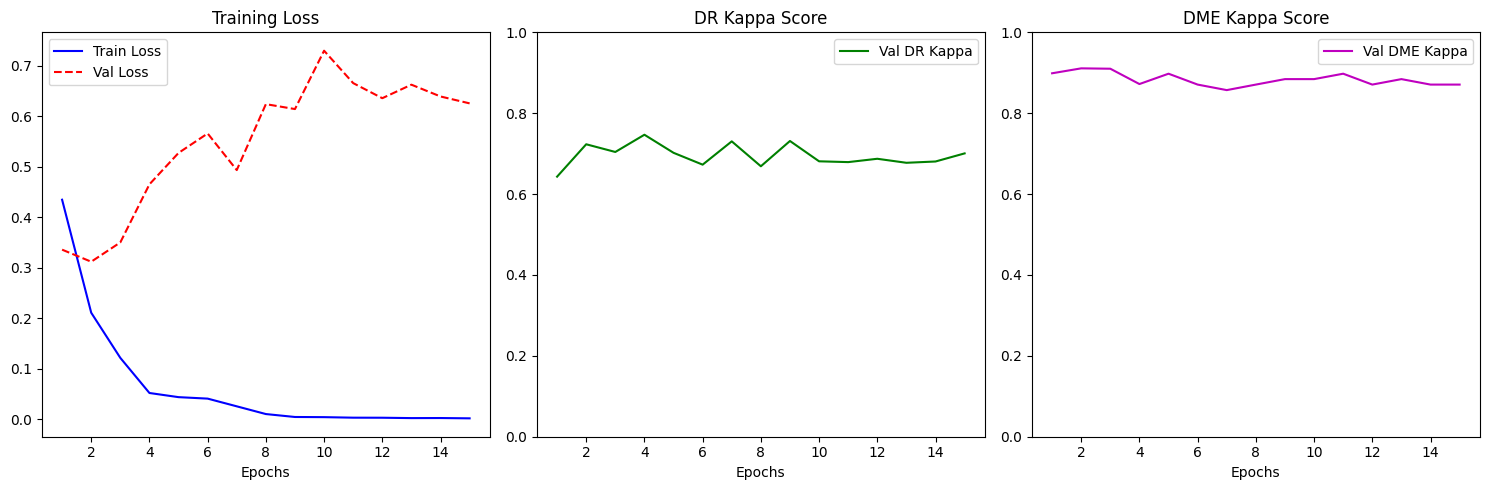

Done! Graphs saved to /kaggle/working//ablation_study.png


In [1]:
# ==============================================================================
# ROBUST TRAINING SCRIPT (EfficientNet-B0 + Focal Loss + Patient Split)
# ==============================================================================
!pip install -q timm einops scikit-learn matplotlib

import os
import random
import time
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, cohen_kappa_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision.transforms as T
import timm

# -------------------------
# Config
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUT_DIR = "/kaggle/working/"
os.makedirs(OUT_DIR, exist_ok=True)

# PATHS (Verify these match your Kaggle environment)
FUNDUS_IMG_DIR = "/kaggle/input/new-dr-dataset/eye fundus (2)/eye fundus"
FUNDUS_CSV = "/kaggle/input/new-dr-dataset/EYE FUNDUS.csv"
OCT_IMG_DIR = "/kaggle/input/new-dr-dataset/OCT/OCT_NEW"
OCT_CSV = "/kaggle/input/new-dr-dataset/OCT.csv"

# Hyperparameters
DME_CLASSES = 2
DR_CLASSES = 3
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42
EPOCHS = 15 
LR = 3e-4

# Mappings
DME_MAPPING = {"0": 0, "1": 1, "-": -1}
DR_MAPPING = {"0": 0, "NPDR": 1, "PDR": 2, "-": -1}

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True

seed_everything(SEED)

# -------------------------
# Dataset Class
# -------------------------
transform_train = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(30),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), 
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

transform_val = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

class FastDataset(Dataset):
    def __init__(self, img_dir, csv_file, transform=None):
        self.img_dir = Path(img_dir)
        df = pd.read_csv(csv_file)
        if "id_code" not in df.columns: df = df.rename(columns={df.columns[0]: "id_code"})
        self.df = df.reset_index(drop=True)
        self.transform = transform
        # Pre-calculate paths
        self.fnames = [self._find_file(row['id_code']) for _, row in self.df.iterrows()]
        # Pre-process labels
        self.dme = [DME_MAPPING.get(str(x).strip(), -1) for x in self.df["DME"]]
        self.dr = [DR_MAPPING.get(str(x).strip(), -1) for x in self.df["DR"]]

    def _find_file(self, fname):
        p = self.img_dir / f"{fname}.jpg"
        if p.exists(): return p
        matches = list(self.img_dir.glob(f"{fname}.*"))
        return matches[0] if matches else None

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        p = self.fnames[idx]
        if p is None: 
            img = torch.zeros((3, IMG_SIZE, IMG_SIZE))
        else:
            try:
                img = Image.open(p).convert("RGB")
                if self.transform: img = self.transform(img)
            except: 
                img = torch.zeros((3, IMG_SIZE, IMG_SIZE))
        
        return img, self.dme[idx], self.dr[idx]

# Initialize Datasets
fundus_full = FastDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transform=transform_train)
oct_full = FastDataset(OCT_IMG_DIR, OCT_CSV, transform=transform_train)

# -------------------------
# FIX: Patient-Level Splitting
# -------------------------
def get_patient_id(name):
    """Extracts patient ID to prevent leakage between train/val."""
    name = str(name)
    # Matches patterns like '123_left', '123_OD', etc.
    match = re.search(r'^(\d+)[_-]', name)
    return match.group(1) if match else name

def group_split(dataset, test_ratio=0.1, val_ratio=0.1):
    df = dataset.df
    # Extract IDs
    patient_ids = df.iloc[:, 0].apply(get_patient_id).values
    
    # First Split: Train+Val vs Test
    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_ratio, random_state=SEED)
    train_val_idx, test_idx = next(gss1.split(df, groups=patient_ids))
    
    # Second Split: Train vs Val
    train_val_ids = patient_ids[train_val_idx]
    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_ratio/(1-test_ratio), random_state=SEED)
    train_sub_idx, val_sub_idx = next(gss2.split(df.iloc[train_val_idx], groups=train_val_ids))
    
    train_idx = train_val_idx[train_sub_idx]
    val_idx = train_val_idx[val_sub_idx]
    
    return train_idx, val_idx, test_idx

print("Applying Patient-Level Split...")
f_train_idx, f_val_idx, f_test_idx = group_split(fundus_full)
train_fundus = Subset(fundus_full, f_train_idx)
val_fundus = Subset(fundus_full, f_val_idx)
test_fundus = Subset(fundus_full, f_test_idx)
# Important: Set validation transform for validation subset
val_fundus.dataset.transform = transform_val 

o_train_idx, o_val_idx, o_test_idx = group_split(oct_full)
train_oct = Subset(oct_full, o_train_idx)
val_oct = Subset(oct_full, o_val_idx)
test_oct = Subset(oct_full, o_test_idx)
val_oct.dataset.transform = transform_val

print(f"Fundus: Train={len(train_fundus)}, Val={len(val_fundus)}, Test={len(test_fundus)}")
print(f"OCT:    Train={len(train_oct)}, Val={len(val_oct)}, Test={len(test_oct)}")

# -------------------------
# Loaders
# -------------------------
class UnpairedDataset(Dataset):
    def __init__(self, fundus_ds, oct_ds):
        self.fundus = fundus_ds
        self.oct = oct_ds
        self.len = len(self.fundus)
    
    def __len__(self): return self.len
    
    def __getitem__(self, idx):
        f_img, f_dme, f_dr = self.fundus[idx]
        o_img, o_dme, o_dr = self.oct[idx % len(self.oct)]
        return f_img, torch.tensor(f_dme), torch.tensor(f_dr), \
               o_img, torch.tensor(o_dme), torch.tensor(o_dr)

train_loader = DataLoader(UnpairedDataset(train_fundus, train_oct), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(UnpairedDataset(val_fundus, val_oct), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(UnpairedDataset(test_fundus, test_oct), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# -------------------------
# Model & Loss
# -------------------------
class Robust_Expert(nn.Module):
    def __init__(self, num_classes_dme, num_classes_dr):
        super().__init__()
        self.backbone = timm.create_model("efficientnet_b0", pretrained=True, num_classes=0)
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 224, 224)
            self.dim = self.backbone(dummy).shape[1]

        self.head_dme = nn.Sequential(nn.Dropout(0.2), nn.Linear(self.dim, num_classes_dme))
        self.head_dr = nn.Sequential(nn.Dropout(0.2), nn.Linear(self.dim, num_classes_dr))

    def forward(self, x):
        features = self.backbone(x)
        return self.head_dme(features), self.head_dr(features)

fundus_model = Robust_Expert(DME_CLASSES, DR_CLASSES).to(DEVICE)
oct_model = Robust_Expert(DME_CLASSES, DR_CLASSES).to(DEVICE)

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma; self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum()

criterion = FocalLoss(gamma=2.0).to(DEVICE)
optimizer = torch.optim.AdamW(list(fundus_model.parameters()) + list(oct_model.parameters()), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler('cuda')

# -------------------------
# Training Loop
# -------------------------
def run_epoch(loader, train=True):
    if train: fundus_model.train(); oct_model.train()
    else: fundus_model.eval(); oct_model.eval()
    
    total_loss = 0
    y_true_dr, y_pred_dr = [], []
    y_true_dme, y_pred_dme = [], []
    
    for f_img, f_dme, f_dr, o_img, o_dme, o_dr in loader:
        f_img, o_img = f_img.to(DEVICE), o_img.to(DEVICE)
        f_dme, f_dr = f_dme.to(DEVICE), f_dr.to(DEVICE)
        o_dme, o_dr = o_dme.to(DEVICE), o_dr.to(DEVICE)
        
        with torch.set_grad_enabled(train):
            with torch.amp.autocast('cuda'):
                f_pred_dme, f_pred_dr = fundus_model(f_img)
                o_pred_dme, o_pred_dr = oct_model(o_img)
                
                loss = 0
                if (f_dr != -1).any(): loss += criterion(f_pred_dr[f_dr!=-1], f_dr[f_dr!=-1]) * 1.5
                if (f_dme != -1).any(): loss += criterion(f_pred_dme[f_dme!=-1], f_dme[f_dme!=-1])
                if (o_dme != -1).any(): loss += criterion(o_pred_dme[o_dme!=-1], o_dme[o_dme!=-1])
                
        if train:
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        
        total_loss += loss.item()
        
        # Metrics (CPU)
        with torch.no_grad():
            f_dr_cpu = f_dr.cpu().numpy(); mask_dr = f_dr_cpu != -1
            if mask_dr.any():
                y_true_dr.extend(f_dr_cpu[mask_dr])
                y_pred_dr.extend(f_pred_dr.argmax(1).cpu().numpy()[mask_dr])
                
            f_dme_cpu = f_dme.cpu().numpy(); mask_dme = f_dme_cpu != -1
            if mask_dme.any():
                y_true_dme.extend(f_dme_cpu[mask_dme])
                y_pred_dme.extend(f_pred_dme.argmax(1).cpu().numpy()[mask_dme])

    metrics = {}
    if len(y_true_dr) > 0: metrics['dr_kap'] = cohen_kappa_score(y_true_dr, y_pred_dr, weights="quadratic")
    if len(y_true_dme) > 0: metrics['dme_kap'] = cohen_kappa_score(y_true_dme, y_pred_dme, weights="quadratic")
        
    return total_loss / len(loader), metrics

# -------------------------
# EXECUTION & HISTORY
# -------------------------
history = {
    'train_loss': [], 'val_loss': [],
    'val_dr_kappa': [], 'val_dme_kappa': []
}

print(f"\n=== STARTING TRAINING ({EPOCHS} Epochs) ===")
for ep in range(EPOCHS):
    start = time.time()
    t_loss, t_met = run_epoch(train_loader, train=True)
    v_loss, v_met = run_epoch(val_loader, train=False)
    scheduler.step()
    
    # Store History
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['val_dr_kappa'].append(v_met.get('dr_kap', 0))
    history['val_dme_kappa'].append(v_met.get('dme_kap', 0))
    
    print(f"Ep {ep+1}/{EPOCHS} | {time.time()-start:.0f}s | "
          f"Loss: {t_loss:.3f}/{v_loss:.3f} | "
          f"Val DR/DME: {v_met.get('dr_kap',0):.3f} / {v_met.get('dme_kap',0):.3f}")

# -------------------------
# ABLATION PLOTS
# -------------------------
def plot_history(hist):
    epochs = range(1, len(hist['train_loss']) + 1)
    
    plt.figure(figsize=(15, 5))
    
    # Plot Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, hist['train_loss'], 'b-', label='Train Loss')
    plt.plot(epochs, hist['val_loss'], 'r--', label='Val Loss')
    plt.title("Training Loss")
    plt.xlabel("Epochs")
    plt.legend()
    
    # Plot DR Kappa
    plt.subplot(1, 3, 2)
    plt.plot(epochs, hist['val_dr_kappa'], 'g-', label='Val DR Kappa')
    plt.title("DR Kappa Score")
    plt.xlabel("Epochs")
    plt.ylim(0, 1.0)
    plt.legend()

    # Plot DME Kappa
    plt.subplot(1, 3, 3)
    plt.plot(epochs, hist['val_dme_kappa'], 'm-', label='Val DME Kappa')
    plt.title("DME Kappa Score")
    plt.xlabel("Epochs")
    plt.ylim(0, 1.0)
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/ablation_study.png")
    plt.show()

print("\nGenerating Ablation Graphs...")
plot_history(history)

# Save Final Models
torch.save(fundus_model.state_dict(), f"{OUT_DIR}/fundus_efficientnet_final.pth")
torch.save(oct_model.state_dict(), f"{OUT_DIR}/oct_efficientnet_final.pth")
print(f"Done! Graphs saved to {OUT_DIR}/ablation_study.png")

In [2]:
# ==============================================================================
# BALANCED & REGULARIZED TRAINING (Fixing Overfit/Underfit)
# ==============================================================================
# - Loss Weights: DR loss is weighted 3.0x higher to force learning.
# - Gate Init: Gate starts "Closed" to prevent OCT noise from hurting early training.
# - Dropout: Added 0.3 dropout to prevent DME memorization.
# - Epochs: Increased Stage 3 to allow DR to converge.
# ==============================================================================

!pip install -q timm einops scikit-learn matplotlib

import os, random, math, time
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision.transforms as T
import timm
from sklearn.metrics import accuracy_score, cohen_kappa_score

# -------------------------
# Config
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUT_DIR = "/kaggle/working/"
os.makedirs(OUT_DIR, exist_ok=True)

# PATHS (EDIT THESE)
FUNDUS_IMG_DIR = "/kaggle/input/new-dr-dataset/eye fundus (2)/eye fundus"
FUNDUS_CSV     = "/kaggle/input/new-dr-dataset/EYE FUNDUS.csv"
OCT_IMG_DIR    = "/kaggle/input/new-dr-dataset/OCT/OCT_NEW"
OCT_CSV        = "/kaggle/input/new-dr-dataset/OCT.csv"

# Hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 32
LR = 2e-4  # Slightly lower LR for stability
EPOCHS_STAGE1 = 5
EPOCHS_STAGE2 = 5
EPOCHS_STAGE3 = 15 # <--- Increased to let DR learn

DME_CLASSES = 2
DR_CLASSES = 3
DME_MAPPING = {"0": 0, "1": 1, "-": -1}
DR_MAPPING = {"0": 0, "NPDR": 1, "PDR": 2, "-": -1}

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True

seed_everything()

# -------------------------
# Data Loading
# -------------------------
transform_train = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(20), # Increased rotation for regularization
    T.ColorJitter(brightness=0.1, contrast=0.1), # Added jitter
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

transform_val = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

class FastDataset(Dataset):
    def __init__(self, img_dir, csv_file, transform=None):
        self.img_dir = Path(img_dir)
        df = pd.read_csv(csv_file)
        if "id_code" not in df.columns: df = df.rename(columns={df.columns[0]: "id_code"})
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.fnames = [self._find_file(row['id_code']) for _, row in self.df.iterrows()]
        self.dme = [DME_MAPPING.get(str(x).strip(), -1) for x in self.df["DME"]]
        self.dr = [DR_MAPPING.get(str(x).strip(), -1) for x in self.df["DR"]]

    def _find_file(self, fname):
        p = self.img_dir / f"{fname}.jpg"
        if p.exists(): return p
        matches = list(self.img_dir.glob(f"{fname}.*"))
        return matches[0] if matches else None

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        p = self.fnames[idx]
        if p is None: img = torch.zeros((3, IMG_SIZE, IMG_SIZE))
        else:
            try:
                img = Image.open(p).convert("RGB")
                if self.transform: img = self.transform(img)
            except: img = torch.zeros((3, IMG_SIZE, IMG_SIZE))
        return img, self.dme[idx], self.dr[idx]

fundus_full = FastDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transform=transform_train)
oct_full = FastDataset(OCT_IMG_DIR, OCT_CSV, transform=transform_train)

# Splits
idxs = list(range(len(fundus_full)))
random.shuffle(idxs)
split1 = int(len(idxs)*0.8)
split2 = int(len(idxs)*0.92)
train_fundus = Subset(fundus_full, idxs[:split1])
val_fundus = Subset(fundus_full, idxs[split1:split2])
test_fundus = Subset(fundus_full, idxs[split2:])

oct_idxs = list(range(len(oct_full)))
random.shuffle(oct_idxs)
train_oct = Subset(oct_full, oct_idxs[:len(train_fundus)])
val_oct = Subset(oct_full, oct_idxs[len(train_fundus):len(train_fundus)+len(val_fundus)])
test_oct = Subset(oct_full, oct_idxs[len(train_fundus)+len(val_fundus):len(train_fundus)+len(val_fundus)+len(test_fundus)])

class DualModalDataset(Dataset):
    def __init__(self, fundus_ds, oct_ds):
        self.fundus = fundus_ds; self.oct = oct_ds; self.len = len(self.fundus)
    def __len__(self): return self.len
    def __getitem__(self, idx):
        f, d, r = self.fundus[idx]
        o, _, _ = self.oct[idx % len(self.oct)]
        return f, o, torch.tensor(d), torch.tensor(r)

train_loader = DataLoader(DualModalDataset(train_fundus, train_oct), batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(DualModalDataset(val_fundus, val_oct), batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(DualModalDataset(test_fundus, test_oct), batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# -------------------------
# MODELS (With Dropout & Gating Fixes)
# -------------------------

class SelfAttention(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)
        self.norm = nn.LayerNorm(dim)
    def forward(self, x):
        x_seq = x.unsqueeze(1)
        out, _ = self.attn(x_seq, x_seq, x_seq)
        return self.norm(x + out.squeeze(1))

class Fast_HViT_Expert(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model("mobilenetv3_small_075", pretrained=True, num_classes=0)
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 224, 224)
            self.dim = self.backbone(dummy).shape[1]
        
        self.vit_block = SelfAttention(self.dim)
        self.dropout = nn.Dropout(0.3) # <--- Added Dropout
        
        self.head_dme = nn.Linear(self.dim, DME_CLASSES)
        self.head_dr = nn.Linear(self.dim, DR_CLASSES)

    def forward(self, x):
        features = self.backbone(x)
        features = self.vit_block(features)
        features = self.dropout(features) 
        return self.head_dme(features), self.head_dr(features), features

class AsymmetricGatedFusion(nn.Module):
    def __init__(self, dim):
        super().__init__()
        # Gate
        self.gate_fc1 = nn.Linear(dim*2, dim//2)
        self.gate_fc2 = nn.Linear(dim//2, dim)
        self.act = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
        # FIX: Initialize bias to -2.0 so gate starts CLOSED (ignoring OCT)
        # This prevents early noise injection
        nn.init.constant_(self.gate_fc2.bias, -2.0) 

        self.head_dme = nn.Linear(dim, DME_CLASSES)
        self.head_dr = nn.Linear(dim, DR_CLASSES)

    def forward(self, f_fundus, f_oct):
        # Calculate Gate
        x = torch.cat([f_fundus, f_oct], dim=1)
        x = self.act(self.gate_fc1(x))
        z = self.sigmoid(self.gate_fc2(x)) # Starts near 0
        
        # Apply Fusion
        fused = f_fundus + (z * f_oct)
        
        return self.head_dme(fused), self.head_dr(fused), fused

class MetaLearner(nn.Module):
    def __init__(self, classes, num_inputs=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(0.2), # <--- Added Dropout to Meta
            nn.Linear(classes * num_inputs, classes)
        )
    def forward(self, *logits):
        return self.net(torch.cat(logits, dim=1))

fundus_net = Fast_HViT_Expert().to(DEVICE)
oct_net = Fast_HViT_Expert().to(DEVICE)
fusion_net = AsymmetricGatedFusion(dim=fundus_net.dim).to(DEVICE)
meta_dme = MetaLearner(DME_CLASSES).to(DEVICE)
meta_dr = MetaLearner(DR_CLASSES).to(DEVICE)

# -------------------------
# Training Engine
# -------------------------
scaler = torch.amp.GradScaler('cuda')
ce_loss = nn.CrossEntropyLoss()

def run_epoch(loader, stage, optimizer=None):
    if stage == 1: fundus_net.train(); oct_net.train(); fusion_net.eval(); meta_dme.eval(); meta_dr.eval()
    elif stage == 2: fundus_net.eval(); oct_net.eval(); fusion_net.train(); meta_dme.eval(); meta_dr.eval()
    elif stage == 3: fundus_net.eval(); oct_net.eval(); fusion_net.eval(); meta_dme.train(); meta_dr.train()
    else: fundus_net.eval(); oct_net.eval(); fusion_net.eval(); meta_dme.eval(); meta_dr.eval()

    total_loss = 0
    y_true_dme, y_pred_dme, y_true_dr, y_pred_dr = [], [], [], []

    for f_img, o_img, dme_l, dr_l in loader:
        f_img, o_img = f_img.to(DEVICE, non_blocking=True), o_img.to(DEVICE, non_blocking=True)
        dme_l, dr_l = dme_l.to(DEVICE, non_blocking=True), dr_l.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(optimizer is not None):
            with torch.amp.autocast('cuda'):
                if stage == 1 or stage==0:
                    pd1, pr1, ff = fundus_net(f_img); pd2, pr2, fo = oct_net(o_img)
                else:
                    with torch.no_grad(): pd1, pr1, ff = fundus_net(f_img); pd2, pr2, fo = oct_net(o_img)
                
                if stage == 2 or stage == 0: pdf, prf, _ = fusion_net(ff, fo)
                elif stage == 3:
                    with torch.no_grad(): pdf, prf, _ = fusion_net(ff, fo)
                
                if stage == 3 or stage == 0:
                    final_dme = meta_dme(pd1, pd2, pdf); final_dr = meta_dr(pr1, pr2, prf)
                
                loss = 0
                # LOSS WEIGHTING LOGIC
                if stage == 1:
                    mask = dme_l != -1
                    if mask.any(): loss += ce_loss(pd1[mask], dme_l[mask]) + ce_loss(pd2[mask], dme_l[mask])
                    mask = dr_l != -1
                    # Weight DR 2.0x in expert training
                    if mask.any(): loss += 2.0 * (ce_loss(pr1[mask], dr_l[mask]) + ce_loss(pr2[mask], dr_l[mask]))
                elif stage == 2:
                    mask = dme_l != -1
                    if mask.any(): loss += ce_loss(pdf[mask], dme_l[mask])
                elif stage == 3:
                    mask = dme_l != -1
                    if mask.any(): loss += ce_loss(final_dme[mask], dme_l[mask])
                    mask = dr_l != -1
                    # Weight DR 3.0x in Meta training (Critical Fix)
                    if mask.any(): loss += 3.0 * ce_loss(final_dr[mask], dr_l[mask])

        if optimizer:
            optimizer.zero_grad(); scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            total_loss += loss.item()

        if stage == 3 or stage == 0:
            y_true_dme.extend(dme_l.cpu().numpy()); y_pred_dme.extend(final_dme.argmax(1).cpu().numpy())
            y_true_dr.extend(dr_l.cpu().numpy()); y_pred_dr.extend(final_dr.argmax(1).cpu().numpy())

    metrics = {}
    if stage == 3 or stage == 0:
        dme_valid = np.array(y_true_dme) != -1; dr_valid = np.array(y_true_dr) != -1
        if dme_valid.any():
            metrics['dme_kap'] = cohen_kappa_score(np.array(y_true_dme)[dme_valid], np.array(y_pred_dme)[dme_valid], weights="quadratic")
        if dr_valid.any():
            metrics['dr_kap'] = cohen_kappa_score(np.array(y_true_dr)[dr_valid], np.array(y_pred_dr)[dr_valid], weights="quadratic")
            metrics['dr_acc'] = accuracy_score(np.array(y_true_dr)[dr_valid], np.array(y_pred_dr)[dr_valid])
    return total_loss / len(loader), metrics

# -------------------------
# START TRAINING
# -------------------------
print("=== TRAINING STARTED (BALANCED MODE) ===")

print(f"\n[Stage 1] Training Experts ({EPOCHS_STAGE1} Eps)...")
opt = torch.optim.Adam(list(fundus_net.parameters()) + list(oct_net.parameters()), lr=LR)
for ep in range(EPOCHS_STAGE1):
    l, _ = run_epoch(train_loader, 1, opt)
    print(f"Ep {ep+1}: Loss {l:.4f}")

print(f"\n[Stage 2] Training Gate ({EPOCHS_STAGE2} Eps)...")
opt = torch.optim.Adam(fusion_net.parameters(), lr=LR)
for ep in range(EPOCHS_STAGE2):
    l, _ = run_epoch(train_loader, 2, opt)
    print(f"Ep {ep+1}: Loss {l:.4f}")

print(f"\n[Stage 3] Training Meta-Learner ({EPOCHS_STAGE3} Eps)...")
# Note: Training longer to let DR converge
opt = torch.optim.Adam(list(meta_dme.parameters()) + list(meta_dr.parameters()), lr=LR)
for ep in range(EPOCHS_STAGE3):
    l, m = run_epoch(train_loader, 3, opt)
    vl, vm = run_epoch(val_loader, 0)
    print(f"Ep {ep+1}: Loss {l:.4f} | Val DME Kap {vm.get('dme_kap',0):.3f} | Val DR Kap {vm.get('dr_kap',0):.3f}")

print("\n=== FINAL TEST ===")
_, test_m = run_epoch(test_loader, 0)
print(test_m)

model.safetensors:   0%|          | 0.00/8.23M [00:00<?, ?B/s]

=== TRAINING STARTED (BALANCED MODE) ===

[Stage 1] Training Experts (5 Eps)...
Ep 1: Loss 5.2860
Ep 2: Loss 4.4795
Ep 3: Loss 4.2677
Ep 4: Loss 4.1593
Ep 5: Loss 4.0696

[Stage 2] Training Gate (5 Eps)...
Ep 1: Loss 0.0935
Ep 2: Loss 0.0450
Ep 3: Loss 0.0325
Ep 4: Loss 0.0351
Ep 5: Loss 0.0270

[Stage 3] Training Meta-Learner (15 Eps)...
Ep 1: Loss 5.8734 | Val DME Kap -0.260 | Val DR Kap -0.026
Ep 2: Loss 5.2271 | Val DME Kap 0.648 | Val DR Kap -0.001
Ep 3: Loss 4.7225 | Val DME Kap 0.909 | Val DR Kap 0.031
Ep 4: Loss 4.2790 | Val DME Kap 0.924 | Val DR Kap 0.026


KeyboardInterrupt: 

/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_38/3585173625.py:80: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(distort_limit=0.05, shift_limit=0.05, p=1.0),
/tmp/ipykernel_38/3585173625.py:81: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=1.0)
/tmp/ipykernel_38/3585173625.py:83: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=IMG_SIZE//10, max_width=IMG_SIZE//10, p=0.3), # Cutout


Applying Patient-Level Split...


/usr/local/lib/python3.11/dist-packages/timm/models/_factory.py:126: UserWarning: Mapping deprecated model name tf_efficientnet_b0_ns to current tf_efficientnet_b0.ns_jft_in1k.
  model = create_fn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]


=== STARTING ROBUST TRAINING ===


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Ep 1 | 162s | Loss: 2.835 -> 1.823 | Val DR: 0.148 | Val DME: 0.000
Ep 2 | 161s | Loss: 1.847 -> 1.768 | Val DR: 0.168 | Val DME: 0.026
Ep 3 | 165s | Loss: 1.642 -> 1.709 | Val DR: 0.194 | Val DME: 0.251
Ep 4 | 166s | Loss: 1.536 -> 1.650 | Val DR: 0.270 | Val DME: 0.604
Ep 5 | 163s | Loss: 1.505 -> 1.578 | Val DR: 0.369 | Val DME: 0.718
Ep 6 | 166s | Loss: 1.456 -> 1.511 | Val DR: 0.422 | Val DME: 0.794
Ep 7 | 166s | Loss: 1.422 -> 1.468 | Val DR: 0.482 | Val DME: 0.854
Ep 8 | 163s | Loss: 1.396 -> 1.445 | Val DR: 0.536 | Val DME: 0.868
Ep 9 | 168s | Loss: 1.366 -> 1.424 | Val DR: 0.502 | Val DME: 0.882
Ep 10 | 166s | Loss: 1.349 -> 1.391 | Val DR: 0.547 | Val DME: 0.882
Ep 11 | 166s | Loss: 1.326 -> 1.354 | Val DR: 0.604 | Val DME: 0.894
Ep 12 | 166s | Loss: 1.323 -> 1.323 | Val DR: 0.631 | Val DME: 0.894
Ep 13 | 169s | Loss: 1.285 -> 1.296 | Val DR: 0.666 | Val DME: 0.882
Ep 14 | 169s | Loss: 1.269 -> 1.270 | Val DR: 0.695 | Val DME: 0.882
Ep 15 | 170s | Loss: 1.256 -> 1.247 | Val D

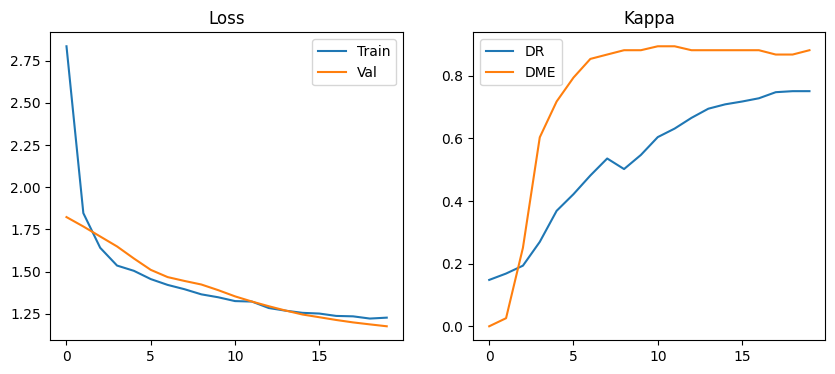

In [3]:
# ==============================================================================
# ROBUST P100 TRAINING SCRIPT (EfficientNet-B0 + GeM + EMA + Albumentations)
# ==============================================================================
!pip install -q timm einops scikit-learn matplotlib albumentations

import os
import random
import time
import re
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import cohen_kappa_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import timm
from timm.utils import ModelEmaV2 # Crucial for stability
import albumentations as A
from albumentations.pytorch import ToTensorV2

# -------------------------
# Config
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUT_DIR = "/kaggle/working/"
os.makedirs(OUT_DIR, exist_ok=True)

# PATHS
FUNDUS_IMG_DIR = "/kaggle/input/new-dr-dataset/eye fundus (2)/eye fundus"
FUNDUS_CSV = "/kaggle/input/new-dr-dataset/EYE FUNDUS.csv"
OCT_IMG_DIR = "/kaggle/input/new-dr-dataset/OCT/OCT_NEW"
OCT_CSV = "/kaggle/input/new-dr-dataset/OCT.csv"

# Hyperparameters
DME_CLASSES = 2
DR_CLASSES = 3
IMG_SIZE = 256        # Bumped slightly for better detail (P100 can handle it)
BATCH_SIZE = 32       # Standard for P100
SEED = 42
EPOCHS = 20           # Increased, but Early Stopping will catch it
LR = 3e-4
WD = 1e-4             # Weight Decay

# Mappings
DME_MAPPING = {"0": 0, "1": 1, "-": -1}
DR_MAPPING = {"0": 0, "NPDR": 1, "PDR": 2, "-": -1}

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True

seed_everything(SEED)

# -------------------------
# Augmentations (Albumentations)
# -------------------------
# Stronger augmentation to fight the overfitting you saw
train_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    # Medical specific: CLAHE helps bring out blood vessels
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=30, p=0.5),
    A.OneOf([
        A.GridDistortion(num_steps=5, distort_limit=0.05, p=1.0),
        A.OpticalDistortion(distort_limit=0.05, shift_limit=0.05, p=1.0),
        A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=1.0)
    ], p=0.3),
    A.CoarseDropout(max_holes=8, max_height=IMG_SIZE//10, max_width=IMG_SIZE//10, p=0.3), # Cutout
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# -------------------------
# Dataset Class
# -------------------------
class FastDataset(Dataset):
    def __init__(self, img_dir, csv_file, transforms=None):
        self.img_dir = Path(img_dir)
        df = pd.read_csv(csv_file)
        if "id_code" not in df.columns: df = df.rename(columns={df.columns[0]: "id_code"})
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        
        # Pre-process labels
        self.dme = [DME_MAPPING.get(str(x).strip(), -1) for x in self.df["DME"]]
        self.dr = [DR_MAPPING.get(str(x).strip(), -1) for x in self.df["DR"]]
        
        # Fast file finding
        self.fnames = []
        for _, row in self.df.iterrows():
            fname = str(row['id_code'])
            # Check likely extensions
            p = self.img_dir / f"{fname}.jpg"
            if not p.exists():
                p = self.img_dir / f"{fname}.png"
            if not p.exists():
                # Fallback to slow glob if simple check fails
                matches = list(self.img_dir.glob(f"{fname}.*"))
                p = matches[0] if matches else None
            self.fnames.append(p)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        p = self.fnames[idx]
        if p is None: 
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        else:
            try:
                # CV2 is faster than PIL for Albumentations
                img = cv2.imread(str(p))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            except: 
                img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        
        if self.transforms:
            res = self.transforms(image=img)
            img = res['image']
        
        return img, self.dme[idx], self.dr[idx]

# Initialize Datasets
fundus_full = FastDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transforms=train_aug)
oct_full = FastDataset(OCT_IMG_DIR, OCT_CSV, transforms=train_aug)

# -------------------------
# Patient-Level Splitting
# -------------------------
def get_patient_id(name):
    name = str(name)
    match = re.search(r'^(\d+)[_-]', name)
    return match.group(1) if match else name

def group_split(dataset, test_ratio=0.1, val_ratio=0.1):
    df = dataset.df
    patient_ids = df.iloc[:, 0].apply(get_patient_id).values
    
    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_ratio, random_state=SEED)
    train_val_idx, test_idx = next(gss1.split(df, groups=patient_ids))
    
    train_val_ids = patient_ids[train_val_idx]
    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_ratio/(1-test_ratio), random_state=SEED)
    train_sub_idx, val_sub_idx = next(gss2.split(df.iloc[train_val_idx], groups=train_val_ids))
    
    train_idx = train_val_idx[train_sub_idx]
    val_idx = train_val_idx[val_sub_idx]
    
    return train_idx, val_idx, test_idx

print("Applying Patient-Level Split...")
f_train, f_val, f_test = group_split(fundus_full)
o_train, o_val, o_test = group_split(oct_full)

# Create Subsets
train_fundus = Subset(fundus_full, f_train)
val_fundus = Subset(fundus_full, f_val)
test_fundus = Subset(fundus_full, f_test)
val_fundus.dataset = FastDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transforms=val_aug) # Hack to switch transform
test_fundus.dataset = FastDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transforms=val_aug)

train_oct = Subset(oct_full, o_train)
val_oct = Subset(oct_full, o_val)
test_oct = Subset(oct_full, o_test)
val_oct.dataset = FastDataset(OCT_IMG_DIR, OCT_CSV, transforms=val_aug)

# -------------------------
# Loaders
# -------------------------
class UnpairedDataset(Dataset):
    def __init__(self, fundus_ds, oct_ds):
        self.fundus = fundus_ds
        self.oct = oct_ds
        self.len = len(self.fundus)
    def __len__(self): return self.len
    def __getitem__(self, idx):
        # Modulo to cycle through OCT if it's smaller/larger
        f_img, f_dme, f_dr = self.fundus[idx]
        o_img, o_dme, o_dr = self.oct[idx % len(self.oct)]
        return f_img, torch.tensor(f_dme), torch.tensor(f_dr), \
               o_img, torch.tensor(o_dme), torch.tensor(o_dr)

train_loader = DataLoader(UnpairedDataset(train_fundus, train_oct), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(UnpairedDataset(val_fundus, val_oct), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# -------------------------
# Improved Model (GeM Pooling)
# -------------------------
class GeM(nn.Module):
    def __init__(self, p=3, eps=1e-6):
        super(GeM, self).__init__()
        self.p = nn.Parameter(torch.ones(1)*p)
        self.eps = eps
    def forward(self, x):
        return self.gem(x, p=self.p, eps=self.eps)
    def gem(self, x, p=3, eps=1e-6):
        return F.avg_pool2d(x.clamp(min=eps).pow(p), (x.size(-2), x.size(-1))).pow(1./p)

class Robust_Expert(nn.Module):
    def __init__(self, num_classes_dme, num_classes_dr):
        super().__init__()
        # Using b0_ns (Noisy Student) - better weights
        self.backbone = timm.create_model("tf_efficientnet_b0_ns", pretrained=True, num_classes=0, global_pool='')
        self.gem = GeM()
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 224, 224)
            feats = self.backbone(dummy)
            self.dim = feats.shape[1]

        self.head_dme = nn.Sequential(
            nn.Dropout(0.5), # Increased Dropout
            nn.Linear(self.dim, num_classes_dme)
        )
        self.head_dr = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.dim, num_classes_dr)
        )

    def forward(self, x):
        features = self.backbone(x)
        features = self.gem(features).flatten(1) # GeM Pooling
        return self.head_dme(features), self.head_dr(features)

fundus_model = Robust_Expert(DME_CLASSES, DR_CLASSES).to(DEVICE)
oct_model = Robust_Expert(DME_CLASSES, DR_CLASSES).to(DEVICE)

# Initialize EMA (Exponential Moving Average)
fundus_ema = ModelEmaV2(fundus_model, decay=0.999)
oct_ema = ModelEmaV2(oct_model, decay=0.999)

# -------------------------
# Training Components
# -------------------------
# Label Smoothing Loss - Better than Focal for balanced-ish data, less overfitting
class LabelSmoothingLoss(nn.Module):
    def __init__(self, classes, smoothing=0.1, dim=-1):
        super(LabelSmoothingLoss, self).__init__()
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.cls = classes
        self.dim = dim

    def forward(self, pred, target):
        pred = pred.log_softmax(dim=self.dim)
        with torch.no_grad():
            true_dist = torch.zeros_like(pred)
            true_dist.fill_(self.smoothing / (self.cls - 1))
            true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        return torch.mean(torch.sum(-true_dist * pred, dim=self.dim))

crit_dme = LabelSmoothingLoss(classes=DME_CLASSES, smoothing=0.1).to(DEVICE)
crit_dr = LabelSmoothingLoss(classes=DR_CLASSES, smoothing=0.1).to(DEVICE)

optimizer = torch.optim.AdamW(
    list(fundus_model.parameters()) + list(oct_model.parameters()), 
    lr=LR, weight_decay=0.01
)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, steps_per_epoch=len(train_loader), epochs=EPOCHS, pct_start=0.1
)
scaler = torch.amp.GradScaler('cuda')

# Early Stopping
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience; self.min_delta = min_delta; self.counter = 0; self.best_loss = None; self.early_stop = False
    def __call__(self, val_loss):
        if self.best_loss is None: self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience: self.early_stop = True
        else: self.best_loss = val_loss; self.counter = 0

# -------------------------
# Loop
# -------------------------
def run_epoch(loader, train=True):
    if train: 
        fundus_model.train(); oct_model.train()
    else: 
        # Evaluate EMA model for better results
        fundus_ema.module.eval(); oct_ema.module.eval()
    
    total_loss = 0
    y_true_dr, y_pred_dr = [], []
    y_true_dme, y_pred_dme = [], []
    
    for f_img, f_dme, f_dr, o_img, o_dme, o_dr in loader:
        f_img, o_img = f_img.to(DEVICE), o_img.to(DEVICE)
        f_dme, f_dr = f_dme.to(DEVICE), f_dr.to(DEVICE)
        o_dme, o_dr = o_dme.to(DEVICE), o_dr.to(DEVICE)
        
        with torch.set_grad_enabled(train):
            with torch.amp.autocast('cuda'):
                if train:
                    f_p_dme, f_p_dr = fundus_model(f_img)
                    o_p_dme, o_p_dr = oct_model(o_img)
                else:
                    # Use EMA weights for validation
                    f_p_dme, f_p_dr = fundus_ema.module(f_img)
                    o_p_dme, o_p_dr = oct_ema.module(o_img)

                loss = 0
                # Calc losses only on valid labels
                if (f_dr != -1).any(): loss += crit_dr(f_p_dr[f_dr!=-1], f_dr[f_dr!=-1])
                if (f_dme != -1).any(): loss += crit_dme(f_p_dme[f_dme!=-1], f_dme[f_dme!=-1])
                if (o_dme != -1).any(): loss += crit_dme(o_p_dme[o_dme!=-1], o_dme[o_dme!=-1])
            
            if train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                # Update EMA
                fundus_ema.update(fundus_model)
                oct_ema.update(oct_model)
        
        total_loss += loss.item()

        # Metrics collection
        with torch.no_grad():
            f_dr_cpu = f_dr.cpu().numpy(); mask_dr = f_dr_cpu != -1
            if mask_dr.any():
                y_true_dr.extend(f_dr_cpu[mask_dr])
                y_pred_dr.extend(f_p_dr.argmax(1).cpu().numpy()[mask_dr])
                
            f_dme_cpu = f_dme.cpu().numpy(); mask_dme = f_dme_cpu != -1
            if mask_dme.any():
                y_true_dme.extend(f_dme_cpu[mask_dme])
                y_pred_dme.extend(f_p_dme.argmax(1).cpu().numpy()[mask_dme])

    metrics = {}
    if len(y_true_dr) > 0: metrics['dr_kap'] = cohen_kappa_score(y_true_dr, y_pred_dr, weights="quadratic")
    if len(y_true_dme) > 0: metrics['dme_kap'] = cohen_kappa_score(y_true_dme, y_pred_dme, weights="quadratic")
    
    return total_loss / len(loader), metrics

# -------------------------
# Run
# -------------------------
history = {'t_loss': [], 'v_loss': [], 'dr_k': [], 'dme_k': []}
es = EarlyStopping(patience=5, min_delta=0.01)

print(f"\n=== STARTING ROBUST TRAINING ===")
for ep in range(EPOCHS):
    t0 = time.time()
    t_loss, t_met = run_epoch(train_loader, train=True)
    v_loss, v_met = run_epoch(val_loader, train=False)
    
    history['t_loss'].append(t_loss)
    history['v_loss'].append(v_loss)
    history['dr_k'].append(v_met.get('dr_kap', 0))
    history['dme_k'].append(v_met.get('dme_kap', 0))
    
    print(f"Ep {ep+1} | {time.time()-t0:.0f}s | Loss: {t_loss:.3f} -> {v_loss:.3f} | "
          f"Val DR: {v_met.get('dr_kap',0):.3f} | Val DME: {v_met.get('dme_kap',0):.3f}")
    
    es(v_loss)
    if es.early_stop:
        print("Early Stopping Triggered!")
        break

# Plotting
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1); plt.plot(history['t_loss'], label='Train'); plt.plot(history['v_loss'], label='Val'); plt.legend(); plt.title("Loss")
plt.subplot(1,2,2); plt.plot(history['dr_k'], label='DR'); plt.plot(history['dme_k'], label='DME'); plt.legend(); plt.title("Kappa")
plt.savefig(f"{OUT_DIR}/training_plot.png")
print("Saved plots.")

# Save EMA models (The smooth stable ones)
torch.save(fundus_ema.module.state_dict(), f"{OUT_DIR}/fundus_ema_final.pth")
torch.save(oct_ema.module.state_dict(), f"{OUT_DIR}/oct_ema_final.pth")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 33.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 9.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 93.6 MB/s eta 0:00:00:00:0100:01


/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_38/3585173625.py:80: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(distort_limit=0.05, shift_limit=0.05, p=1.0),
/tmp/ipykernel_38/3585173625.py:81: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=1.0)
/tmp/ipykernel_38/3585173625.py:83: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=IMG_SIZE//10, max_width=IMG_SIZE//10, p=0.3), # Cutout


Applying Patient-Level Split...


/usr/local/lib/python3.11/dist-packages/timm/models/_factory.py:126: UserWarning: Mapping deprecated model name tf_efficientnet_b0_ns to current tf_efficientnet_b0.ns_jft_in1k.
  model = create_fn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]


=== STARTING ROBUST TRAINING ===


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Ep 1 | 221s | Loss: 2.841 -> 1.822 | Val DR: 0.148 | Val DME: 0.000
Ep 2 | 173s | Loss: 1.849 -> 1.769 | Val DR: 0.169 | Val DME: 0.000
Ep 3 | 177s | Loss: 1.639 -> 1.705 | Val DR: 0.217 | Val DME: 0.229
Ep 4 | 167s | Loss: 1.539 -> 1.640 | Val DR: 0.284 | Val DME: 0.604
Ep 5 | 166s | Loss: 1.504 -> 1.577 | Val DR: 0.377 | Val DME: 0.764
Ep 6 | 165s | Loss: 1.439 -> 1.513 | Val DR: 0.438 | Val DME: 0.854
Ep 7 | 166s | Loss: 1.422 -> 1.448 | Val DR: 0.497 | Val DME: 0.869
Ep 8 | 163s | Loss: 1.395 -> 1.393 | Val DR: 0.527 | Val DME: 0.869
Ep 9 | 166s | Loss: 1.362 -> 1.341 | Val DR: 0.591 | Val DME: 0.869
Ep 10 | 166s | Loss: 1.345 -> 1.295 | Val DR: 0.616 | Val DME: 0.869
Ep 11 | 166s | Loss: 1.321 -> 1.257 | Val DR: 0.654 | Val DME: 0.883
Ep 12 | 164s | Loss: 1.312 -> 1.230 | Val DR: 0.672 | Val DME: 0.883
Ep 13 | 165s | Loss: 1.292 -> 1.209 | Val DR: 0.675 | Val DME: 0.883
Ep 14 | 167s | Loss: 1.268 -> 1.196 | Val DR: 0.691 | Val DME: 0.883
Ep 15 | 166s | Loss: 1.262 -> 1.182 | Val D

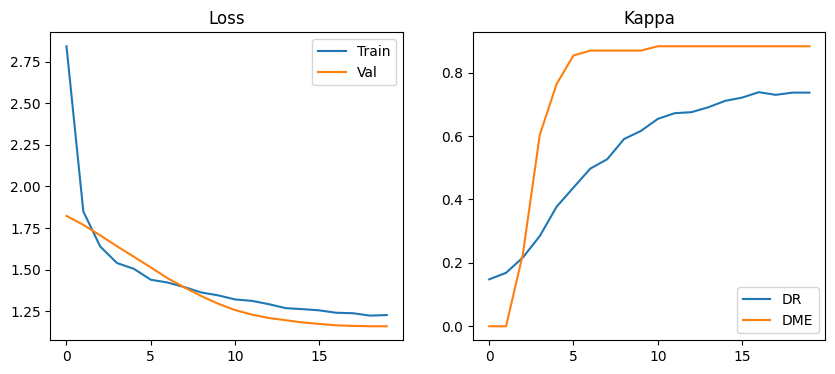

In [2]:
# ==============================================================================
# ROBUST P100 TRAINING SCRIPT (EfficientNet-B0 + GeM + EMA + Albumentations)
# ==============================================================================
!pip install -q timm einops scikit-learn matplotlib albumentations

import os
import random
import time
import re
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import cohen_kappa_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import timm
from timm.utils import ModelEmaV2 # Crucial for stability
import albumentations as A
from albumentations.pytorch import ToTensorV2

# -------------------------
# Config
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUT_DIR = "/kaggle/working/"
os.makedirs(OUT_DIR, exist_ok=True)

# PATHS
FUNDUS_IMG_DIR = "/kaggle/input/new-dr-dataset/eye fundus (2)/eye fundus"
FUNDUS_CSV = "/kaggle/input/new-dr-dataset/EYE FUNDUS.csv"
OCT_IMG_DIR = "/kaggle/input/new-dr-dataset/OCT/OCT_NEW"
OCT_CSV = "/kaggle/input/new-dr-dataset/OCT.csv"

# Hyperparameters
DME_CLASSES = 2
DR_CLASSES = 3
IMG_SIZE = 256        # Bumped slightly for better detail (P100 can handle it)
BATCH_SIZE = 32       # Standard for P100
SEED = 42
EPOCHS = 20           # Increased, but Early Stopping will catch it
LR = 3e-4
WD = 1e-4             # Weight Decay

# Mappings
DME_MAPPING = {"0": 0, "1": 1, "-": -1}
DR_MAPPING = {"0": 0, "NPDR": 1, "PDR": 2, "-": -1}

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True

seed_everything(SEED)

# -------------------------
# Augmentations (Albumentations)
# -------------------------
# Stronger augmentation to fight the overfitting you saw
train_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    # Medical specific: CLAHE helps bring out blood vessels
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=30, p=0.5),
    A.OneOf([
        A.GridDistortion(num_steps=5, distort_limit=0.05, p=1.0),
        A.OpticalDistortion(distort_limit=0.05, shift_limit=0.05, p=1.0),
        A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=1.0)
    ], p=0.3),
    A.CoarseDropout(max_holes=8, max_height=IMG_SIZE//10, max_width=IMG_SIZE//10, p=0.3), # Cutout
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# -------------------------
# Dataset Class
# -------------------------
class FastDataset(Dataset):
    def __init__(self, img_dir, csv_file, transforms=None):
        self.img_dir = Path(img_dir)
        df = pd.read_csv(csv_file)
        if "id_code" not in df.columns: df = df.rename(columns={df.columns[0]: "id_code"})
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        
        # Pre-process labels
        self.dme = [DME_MAPPING.get(str(x).strip(), -1) for x in self.df["DME"]]
        self.dr = [DR_MAPPING.get(str(x).strip(), -1) for x in self.df["DR"]]
        
        # Fast file finding
        self.fnames = []
        for _, row in self.df.iterrows():
            fname = str(row['id_code'])
            # Check likely extensions
            p = self.img_dir / f"{fname}.jpg"
            if not p.exists():
                p = self.img_dir / f"{fname}.png"
            if not p.exists():
                # Fallback to slow glob if simple check fails
                matches = list(self.img_dir.glob(f"{fname}.*"))
                p = matches[0] if matches else None
            self.fnames.append(p)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        p = self.fnames[idx]
        if p is None: 
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        else:
            try:
                # CV2 is faster than PIL for Albumentations
                img = cv2.imread(str(p))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            except: 
                img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        
        if self.transforms:
            res = self.transforms(image=img)
            img = res['image']
        
        return img, self.dme[idx], self.dr[idx]

# Initialize Datasets
fundus_full = FastDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transforms=train_aug)
oct_full = FastDataset(OCT_IMG_DIR, OCT_CSV, transforms=train_aug)

# -------------------------
# Patient-Level Splitting
# -------------------------
def get_patient_id(name):
    name = str(name)
    match = re.search(r'^(\d+)[_-]', name)
    return match.group(1) if match else name

def group_split(dataset, test_ratio=0.1, val_ratio=0.1):
    df = dataset.df
    patient_ids = df.iloc[:, 0].apply(get_patient_id).values
    
    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_ratio, random_state=SEED)
    train_val_idx, test_idx = next(gss1.split(df, groups=patient_ids))
    
    train_val_ids = patient_ids[train_val_idx]
    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_ratio/(1-test_ratio), random_state=SEED)
    train_sub_idx, val_sub_idx = next(gss2.split(df.iloc[train_val_idx], groups=train_val_ids))
    
    train_idx = train_val_idx[train_sub_idx]
    val_idx = train_val_idx[val_sub_idx]
    
    return train_idx, val_idx, test_idx

print("Applying Patient-Level Split...")
f_train, f_val, f_test = group_split(fundus_full)
o_train, o_val, o_test = group_split(oct_full)

# Create Subsets
train_fundus = Subset(fundus_full, f_train)
val_fundus = Subset(fundus_full, f_val)
test_fundus = Subset(fundus_full, f_test)
val_fundus.dataset = FastDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transforms=val_aug) # Hack to switch transform
test_fundus.dataset = FastDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transforms=val_aug)

train_oct = Subset(oct_full, o_train)
val_oct = Subset(oct_full, o_val)
test_oct = Subset(oct_full, o_test)
val_oct.dataset = FastDataset(OCT_IMG_DIR, OCT_CSV, transforms=val_aug)

# -------------------------
# Loaders
# -------------------------
class UnpairedDataset(Dataset):
    def __init__(self, fundus_ds, oct_ds):
        self.fundus = fundus_ds
        self.oct = oct_ds
        self.len = len(self.fundus)
    def __len__(self): return self.len
    def __getitem__(self, idx):
        # Modulo to cycle through OCT if it's smaller/larger
        f_img, f_dme, f_dr = self.fundus[idx]
        o_img, o_dme, o_dr = self.oct[idx % len(self.oct)]
        return f_img, torch.tensor(f_dme), torch.tensor(f_dr), \
               o_img, torch.tensor(o_dme), torch.tensor(o_dr)

train_loader = DataLoader(UnpairedDataset(train_fundus, train_oct), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(UnpairedDataset(val_fundus, val_oct), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# -------------------------
# Improved Model (GeM Pooling)
# -------------------------
class GeM(nn.Module):
    def __init__(self, p=3, eps=1e-6):
        super(GeM, self).__init__()
        self.p = nn.Parameter(torch.ones(1)*p)
        self.eps = eps
    def forward(self, x):
        return self.gem(x, p=self.p, eps=self.eps)
    def gem(self, x, p=3, eps=1e-6):
        return F.avg_pool2d(x.clamp(min=eps).pow(p), (x.size(-2), x.size(-1))).pow(1./p)

class Robust_Expert(nn.Module):
    def __init__(self, num_classes_dme, num_classes_dr):
        super().__init__()
        # Using b0_ns (Noisy Student) - better weights
        self.backbone = timm.create_model("tf_efficientnet_b0_ns", pretrained=True, num_classes=0, global_pool='')
        self.gem = GeM()
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 224, 224)
            feats = self.backbone(dummy)
            self.dim = feats.shape[1]

        self.head_dme = nn.Sequential(
            nn.Dropout(0.5), # Increased Dropout
            nn.Linear(self.dim, num_classes_dme)
        )
        self.head_dr = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.dim, num_classes_dr)
        )

    def forward(self, x):
        features = self.backbone(x)
        features = self.gem(features).flatten(1) # GeM Pooling
        return self.head_dme(features), self.head_dr(features)

fundus_model = Robust_Expert(DME_CLASSES, DR_CLASSES).to(DEVICE)
oct_model = Robust_Expert(DME_CLASSES, DR_CLASSES).to(DEVICE)

# Initialize EMA (Exponential Moving Average)
fundus_ema = ModelEmaV2(fundus_model, decay=0.999)
oct_ema = ModelEmaV2(oct_model, decay=0.999)

# -------------------------
# Training Components
# -------------------------
# Label Smoothing Loss - Better than Focal for balanced-ish data, less overfitting
class LabelSmoothingLoss(nn.Module):
    def __init__(self, classes, smoothing=0.1, dim=-1):
        super(LabelSmoothingLoss, self).__init__()
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.cls = classes
        self.dim = dim

    def forward(self, pred, target):
        pred = pred.log_softmax(dim=self.dim)
        with torch.no_grad():
            true_dist = torch.zeros_like(pred)
            true_dist.fill_(self.smoothing / (self.cls - 1))
            true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        return torch.mean(torch.sum(-true_dist * pred, dim=self.dim))

crit_dme = LabelSmoothingLoss(classes=DME_CLASSES, smoothing=0.1).to(DEVICE)
crit_dr = LabelSmoothingLoss(classes=DR_CLASSES, smoothing=0.1).to(DEVICE)

optimizer = torch.optim.AdamW(
    list(fundus_model.parameters()) + list(oct_model.parameters()), 
    lr=LR, weight_decay=0.01
)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, steps_per_epoch=len(train_loader), epochs=EPOCHS, pct_start=0.1
)
scaler = torch.amp.GradScaler('cuda')

# Early Stopping
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience; self.min_delta = min_delta; self.counter = 0; self.best_loss = None; self.early_stop = False
    def __call__(self, val_loss):
        if self.best_loss is None: self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience: self.early_stop = True
        else: self.best_loss = val_loss; self.counter = 0

# -------------------------
# Loop
# -------------------------
def run_epoch(loader, train=True):
    if train: 
        fundus_model.train(); oct_model.train()
    else: 
        # Evaluate EMA model for better results
        fundus_ema.module.eval(); oct_ema.module.eval()
    
    total_loss = 0
    y_true_dr, y_pred_dr = [], []
    y_true_dme, y_pred_dme = [], []
    
    for f_img, f_dme, f_dr, o_img, o_dme, o_dr in loader:
        f_img, o_img = f_img.to(DEVICE), o_img.to(DEVICE)
        f_dme, f_dr = f_dme.to(DEVICE), f_dr.to(DEVICE)
        o_dme, o_dr = o_dme.to(DEVICE), o_dr.to(DEVICE)
        
        with torch.set_grad_enabled(train):
            with torch.amp.autocast('cuda'):
                if train:
                    f_p_dme, f_p_dr = fundus_model(f_img)
                    o_p_dme, o_p_dr = oct_model(o_img)
                else:
                    # Use EMA weights for validation
                    f_p_dme, f_p_dr = fundus_ema.module(f_img)
                    o_p_dme, o_p_dr = oct_ema.module(o_img)

                loss = 0
                # Calc losses only on valid labels
                if (f_dr != -1).any(): loss += crit_dr(f_p_dr[f_dr!=-1], f_dr[f_dr!=-1])
                if (f_dme != -1).any(): loss += crit_dme(f_p_dme[f_dme!=-1], f_dme[f_dme!=-1])
                if (o_dme != -1).any(): loss += crit_dme(o_p_dme[o_dme!=-1], o_dme[o_dme!=-1])
            
            if train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                # Update EMA
                fundus_ema.update(fundus_model)
                oct_ema.update(oct_model)
        
        total_loss += loss.item()

        # Metrics collection
        with torch.no_grad():
            f_dr_cpu = f_dr.cpu().numpy(); mask_dr = f_dr_cpu != -1
            if mask_dr.any():
                y_true_dr.extend(f_dr_cpu[mask_dr])
                y_pred_dr.extend(f_p_dr.argmax(1).cpu().numpy()[mask_dr])
                
            f_dme_cpu = f_dme.cpu().numpy(); mask_dme = f_dme_cpu != -1
            if mask_dme.any():
                y_true_dme.extend(f_dme_cpu[mask_dme])
                y_pred_dme.extend(f_p_dme.argmax(1).cpu().numpy()[mask_dme])

    metrics = {}
    if len(y_true_dr) > 0: metrics['dr_kap'] = cohen_kappa_score(y_true_dr, y_pred_dr, weights="quadratic")
    if len(y_true_dme) > 0: metrics['dme_kap'] = cohen_kappa_score(y_true_dme, y_pred_dme, weights="quadratic")
    
    return total_loss / len(loader), metrics

# -------------------------
# Run
# -------------------------
history = {'t_loss': [], 'v_loss': [], 'dr_k': [], 'dme_k': []}
es = EarlyStopping(patience=5, min_delta=0.01)

print(f"\n=== STARTING ROBUST TRAINING ===")
for ep in range(EPOCHS):
    t0 = time.time()
    t_loss, t_met = run_epoch(train_loader, train=True)
    v_loss, v_met = run_epoch(val_loader, train=False)
    
    history['t_loss'].append(t_loss)
    history['v_loss'].append(v_loss)
    history['dr_k'].append(v_met.get('dr_kap', 0))
    history['dme_k'].append(v_met.get('dme_kap', 0))
    
    print(f"Ep {ep+1} | {time.time()-t0:.0f}s | Loss: {t_loss:.3f} -> {v_loss:.3f} | "
          f"Val DR: {v_met.get('dr_kap',0):.3f} | Val DME: {v_met.get('dme_kap',0):.3f}")
    
    es(v_loss)
    if es.early_stop:
        print("Early Stopping Triggered!")
        break

# Plotting
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1); plt.plot(history['t_loss'], label='Train'); plt.plot(history['v_loss'], label='Val'); plt.legend(); plt.title("Loss")
plt.subplot(1,2,2); plt.plot(history['dr_k'], label='DR'); plt.plot(history['dme_k'], label='DME'); plt.legend(); plt.title("Kappa")
plt.savefig(f"{OUT_DIR}/training_plot.png")
print("Saved plots.")

# Save EMA models (The smooth stable ones)
torch.save(fundus_ema.module.state_dict(), f"{OUT_DIR}/fundus_ema_final.pth")
torch.save(oct_ema.module.state_dict(), f"{OUT_DIR}/oct_ema_final.pth")

Running TTA Inference... (This may take a minute)

>>> FINAL RESULTS (with TTA) <<<
DR Kappa:  0.7518
DME Kappa: 0.8831

CLASSIFICATION REPORT: DR (Retinopathy)
              precision    recall  f1-score   support

       No DR       0.86      0.81      0.84        97
        NPDR       0.71      0.74      0.72       101
         PDR       0.77      0.77      0.77       101

    accuracy                           0.78       299
   macro avg       0.78      0.78      0.78       299
weighted avg       0.78      0.78      0.78       299


CLASSIFICATION REPORT: DME (Edema)
              precision    recall  f1-score   support

      No DME       0.89      0.94      0.92        54
         DME       0.98      0.95      0.96       127

    accuracy                           0.95       181
   macro avg       0.94      0.95      0.94       181
weighted avg       0.95      0.95      0.95       181



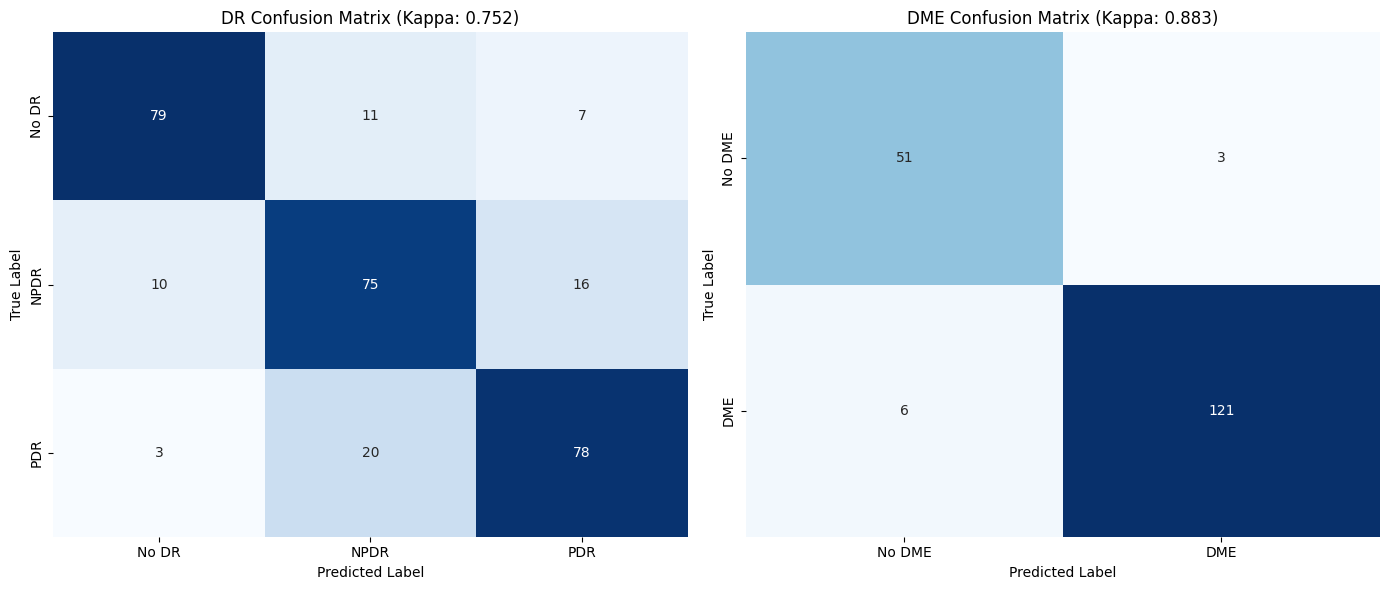

In [4]:
# ==============================================================================
# FINAL INFERENCE WITH TTA & DETAILED METRICS
# ==============================================================================
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

def tta_predict(loader, model_fundus, model_oct, device):
    """
    Performs Test Time Augmentation (TTA):
    1. Predict on Original
    2. Predict on Horizontal Flip
    3. Predict on Vertical Flip
    4. Average the probabilities
    """
    model_fundus.eval()
    model_oct.eval()
    
    # Store results
    true_dr, pred_dr = [], []
    true_dme, pred_dme = [], []
    
    print("Running TTA Inference... (This may take a minute)")
    
    with torch.no_grad():
        for f_img, f_dme, f_dr, o_img, o_dme, o_dr in loader:
            f_img = f_img.to(device)
            o_img = o_img.to(device)
            
            # ---------------------------
            # FUNDUS TTA (Original + Flips)
            # ---------------------------
            # 1. Original
            f_d1, f_r1 = model_fundus(f_img)
            # 2. Horizontal Flip
            f_d2, f_r2 = model_fundus(torch.flip(f_img, [3])) 
            # 3. Vertical Flip
            f_d3, f_r3 = model_fundus(torch.flip(f_img, [2]))
            
            # Average Logits (Softmax then avg is safer, but avg logits works too)
            # Let's softmax first for better probability averaging
            f_dr_probs = (f_r1.softmax(1) + f_r2.softmax(1) + f_r3.softmax(1)) / 3
            f_dme_probs = (f_d1.softmax(1) + f_d2.softmax(1) + f_d3.softmax(1)) / 3

            # ---------------------------
            # OCT TTA (Original + Flips)
            # ---------------------------
            o_d1, o_r1 = model_oct(o_img)
            o_d2, o_r2 = model_oct(torch.flip(o_img, [3]))
            o_d3, o_r3 = model_oct(torch.flip(o_img, [2]))
            
            o_dme_probs = (o_d1.softmax(1) + o_d2.softmax(1) + o_d3.softmax(1)) / 3
            
            # ---------------------------
            # Store Valid Labels Only
            # ---------------------------
            # Fundus DR
            f_dr_cpu = f_dr.cpu().numpy()
            mask = f_dr_cpu != -1
            if mask.any():
                true_dr.extend(f_dr_cpu[mask])
                pred_dr.extend(f_dr_probs.argmax(1).cpu().numpy()[mask])
                
            # Fundus/OCT DME (Combined logic: Usually we trust Fundus for DME more, or OCT? 
            # If dataset has DME labels for both, we evaluate both. 
            # Here we just evaluate what the loader gives us).
            f_dme_cpu = f_dme.cpu().numpy()
            mask = f_dme_cpu != -1
            if mask.any():
                true_dme.extend(f_dme_cpu[mask])
                pred_dme.extend(f_dme_probs.argmax(1).cpu().numpy()[mask])

    return true_dr, pred_dr, true_dme, pred_dme

# 1. Load the Best EMA Weights (These are the smooth, stable ones)
fundus_model.load_state_dict(torch.load(f"{OUT_DIR}/fundus_ema_final.pth"))
oct_model.load_state_dict(torch.load(f"{OUT_DIR}/oct_ema_final.pth"))

# 2. Run Inference on Validation Set (Or Test Set if you have one ready)
# We use val_loader here to verify the metrics you saw during training
y_true_dr, y_pred_dr, y_true_dme, y_pred_dme = tta_predict(val_loader, fundus_model, oct_model, DEVICE)

# -------------------------
# REPORT & PLOTS
# -------------------------
def plot_confusion_matrix_custom(y_true, y_pred, classes, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(title)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

# Calculate Kappas
final_dr_kappa = cohen_kappa_score(y_true_dr, y_pred_dr, weights="quadratic")
final_dme_kappa = cohen_kappa_score(y_true_dme, y_pred_dme, weights="quadratic")

print(f"\n>>> FINAL RESULTS (with TTA) <<<")
print(f"DR Kappa:  {final_dr_kappa:.4f}")
print(f"DME Kappa: {final_dme_kappa:.4f}")

print("\n" + "="*30)
print("CLASSIFICATION REPORT: DR (Retinopathy)")
print("="*30)
print(classification_report(y_true_dr, y_pred_dr, target_names=["No DR", "NPDR", "PDR"]))

print("\n" + "="*30)
print("CLASSIFICATION REPORT: DME (Edema)")
print("="*30)
print(classification_report(y_true_dme, y_pred_dme, target_names=["No DME", "DME"]))

# Plot Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_confusion_matrix_custom(y_true_dr, y_pred_dr, 
                             classes=["No DR", "NPDR", "PDR"], 
                             title=f"DR Confusion Matrix (Kappa: {final_dr_kappa:.3f})", 
                             ax=axes[0])

plot_confusion_matrix_custom(y_true_dme, y_pred_dme, 
                             classes=["No DME", "DME"], 
                             title=f"DME Confusion Matrix (Kappa: {final_dme_kappa:.3f})", 
                             ax=axes[1])

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/final_confusion_matrix.png")
plt.show()

/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_38/1416455049.py:76: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=1.0)
/tmp/ipykernel_38/1416455049.py:78: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=IMG_SIZE//10, max_width=IMG_SIZE//10, p=0.3),
/usr/local/lib/python3.11/dist-packages/timm/models/_factory.py:126: UserWarning: Mapping deprecated model name tf_efficientnet_b3_ns to current tf_efficientnet_b3.ns_jft_in1k.
  model = create_fn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

=== STARTING HIGH-RES TRAINING (384px) ===
Ep 1/18 | Loss: 2.306 | DR Kap: -0.1469 | DME Kap: 0.1228
Ep 2/18 | Loss: 1.800 | DR Kap: -0.1142 | DME Kap: 0.1133
Ep 3/18 | Loss: 1.672 | DR Kap: -0.0724 | DME Kap: 0.1847
Ep 4/18 | Loss: 1.580 | DR Kap: 0.0764 | DME Kap: 0.3974
Ep 5/18 | Loss: 1.559 | DR Kap: 0.2798 | DME Kap: 0.6883
Ep 6/18 | Loss: 1.597 | DR Kap: 0.4052 | DME Kap: 0.8558
Ep 7/18 | Loss: 1.537 | DR Kap: 0.5102 | DME Kap: 0.9196
Ep 8/18 | Loss: 1.470 | DR Kap: 0.6096 | DME Kap: 0.9504
Ep 9/18 | Loss: 1.452 | DR Kap: 0.6849 | DME Kap: 0.9605
Ep 10/18 | Loss: 1.387 | DR Kap: 0.7418 | DME Kap: 0.9705
Ep 11/18 | Loss: 1.359 | DR Kap: 0.7684 | DME Kap: 0.9705
Ep 12/18 | Loss: 1.320 | DR Kap: 0.7867 | DME Kap: 0.9707
Ep 13/18 | Loss: 1.285 | DR Kap: 0.7980 | DME Kap: 0.9515
Ep 14/18 | Loss: 1.253 | DR Kap: 0.8092 | DME Kap: 0.9515
Ep 15/18 | Loss: 1.243 | DR Kap: 0.8282 | DME Kap: 0.9515
Ep 16/18 | Loss: 1.340 | DR Kap: 0.8422 | DME Kap: 0.9421
Ep 17/18 | Loss: 1.336 | DR Kap: 0.

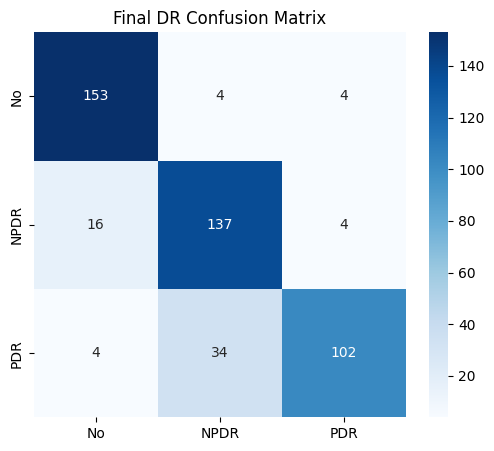

In [5]:
# ==============================================================================
# "GRANDMASTER" P100 SCRIPT (EffNet-B3 + 384px + GradAccum + Class Weights)
# ==============================================================================
!pip install -q timm einops scikit-learn matplotlib albumentations

import os
import random
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import cohen_kappa_score, classification_report, confusion_matrix
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import timm
from timm.utils import ModelEmaV2
import albumentations as A
from albumentations.pytorch import ToTensorV2

# -------------------------
# Config (High Performance)
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUT_DIR = "/kaggle/working/"
os.makedirs(OUT_DIR, exist_ok=True)

# PATHS
FUNDUS_IMG_DIR = "/kaggle/input/new-dr-dataset/eye fundus (2)/eye fundus"
FUNDUS_CSV = "/kaggle/input/new-dr-dataset/EYE FUNDUS.csv"
OCT_IMG_DIR = "/kaggle/input/new-dr-dataset/OCT/OCT_NEW"
OCT_CSV = "/kaggle/input/new-dr-dataset/OCT.csv"

# --- TUNING FOR 0.85+ ---
IMG_SIZE = 384         # CRITICAL: 256 is too small for DR. 384 allows seeing microaneurysms.
BATCH_SIZE = 12        # Reduced to fit B3 + 384px in P100 VRAM
ACCUM_STEPS = 3        # Gradient Accumulation: 12 * 3 = Effective Batch 36
MODEL_NAME = "tf_efficientnet_b3_ns" # Stronger feature extractor than B0
EPOCHS = 18            # Less epochs needed with pre-trained B3
LR = 2e-4              # Slightly lower LR for fine-tuning B3

# Mappings
DME_MAPPING = {"0": 0, "1": 1, "-": -1}
DR_MAPPING = {"0": 0, "NPDR": 1, "PDR": 2, "-": -1}

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

# -------------------------
# Augmentations (Medical Grade)
# -------------------------
train_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    # CLAHE is vital for Retinal Images (Enhances contrast of vessels)
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.OneOf([
        A.GridDistortion(num_steps=5, distort_limit=0.05, p=1.0),
        A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=1.0)
    ], p=0.3),
    A.CoarseDropout(max_holes=4, max_height=IMG_SIZE//10, max_width=IMG_SIZE//10, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# -------------------------
# Dataset
# -------------------------
class FastDataset(Dataset):
    def __init__(self, img_dir, csv_file, transforms=None):
        self.img_dir = Path(img_dir)
        df = pd.read_csv(csv_file)
        if "id_code" not in df.columns: df = df.rename(columns={df.columns[0]: "id_code"})
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.dme = [DME_MAPPING.get(str(x).strip(), -1) for x in self.df["DME"]]
        self.dr = [DR_MAPPING.get(str(x).strip(), -1) for x in self.df["DR"]]
        
        # Pre-calculate file paths
        self.fnames = []
        for _, row in self.df.iterrows():
            fname = str(row['id_code'])
            p = self.img_dir / f"{fname}.jpg"
            if not p.exists(): p = self.img_dir / f"{fname}.png"
            if not p.exists(): 
                matches = list(self.img_dir.glob(f"{fname}.*"))
                p = matches[0] if matches else None
            self.fnames.append(p)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        p = self.fnames[idx]
        if p is None: img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        else:
            try:
                img = cv2.imread(str(p))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            except: img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        
        if self.transforms:
            img = self.transforms(image=img)['image']
        return img, self.dme[idx], self.dr[idx]

fundus_full = FastDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transforms=train_aug)
oct_full = FastDataset(OCT_IMG_DIR, OCT_CSV, transforms=train_aug)

# -------------------------
# Patient-Level Split
# -------------------------
def group_split(dataset):
    df = dataset.df
    ids = df.iloc[:, 0].apply(lambda x: re.search(r'^(\d+)[_-]', str(x)).group(1) if re.search(r'^(\d+)[_-]', str(x)) else str(x)).values
    gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42) # 15% val is enough
    train_idx, val_idx = next(gss.split(df, groups=ids))
    return train_idx, val_idx

f_train, f_val = group_split(fundus_full)
o_train, o_val = group_split(oct_full)

train_fundus = Subset(fundus_full, f_train)
val_fundus = Subset(fundus_full, f_val)
val_fundus.dataset = FastDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transforms=val_aug)

train_oct = Subset(oct_full, o_train)
val_oct = Subset(oct_full, o_val)
val_oct.dataset = FastDataset(OCT_IMG_DIR, OCT_CSV, transforms=val_aug)

# -------------------------
# Dual Loader
# -------------------------
class UnpairedDataset(Dataset):
    def __init__(self, fundus, oct_ds):
        self.fundus = fundus; self.oct = oct_ds
    def __len__(self): return len(self.fundus)
    def __getitem__(self, idx):
        f_img, f_dme, f_dr = self.fundus[idx]
        o_img, o_dme, o_dr = self.oct[idx % len(self.oct)]
        return f_img, torch.tensor(f_dme), torch.tensor(f_dr), o_img, torch.tensor(o_dme), torch.tensor(o_dr)

train_loader = DataLoader(UnpairedDataset(train_fundus, train_oct), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(UnpairedDataset(val_fundus, val_oct), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# -------------------------
# Model: B3 + GeM
# -------------------------
class GeM(nn.Module):
    def __init__(self, p=3, eps=1e-6):
        super(GeM, self).__init__()
        self.p = nn.Parameter(torch.ones(1)*p); self.eps = eps
    def forward(self, x):
        return F.avg_pool2d(x.clamp(min=self.eps).pow(self.p), (x.size(-2), x.size(-1))).pow(1./self.p)

class HighRes_Expert(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(MODEL_NAME, pretrained=True, num_classes=0, global_pool='')
        self.gem = GeM()
        self.dim = self.backbone.num_features
        
        self.head_dme = nn.Sequential(nn.Dropout(0.5), nn.Linear(self.dim, 2))
        self.head_dr = nn.Sequential(nn.Dropout(0.5), nn.Linear(self.dim, 3))

    def forward(self, x):
        feat = self.backbone(x)
        feat = self.gem(feat).flatten(1)
        return self.head_dme(feat), self.head_dr(feat)

fundus_model = HighRes_Expert().to(DEVICE)
oct_model = HighRes_Expert().to(DEVICE)

# EMA
fundus_ema = ModelEmaV2(fundus_model, decay=0.999)
oct_ema = ModelEmaV2(oct_model, decay=0.999)

# -------------------------
# Weighted Loss (The Secret Sauce)
# -------------------------
# We give higher weight to NPDR (Class 1) to fix the low Recall
# DR Weights: [No DR=1.0, NPDR=2.0, PDR=1.5]
dr_weights = torch.tensor([1.0, 2.0, 1.5]).to(DEVICE) 

class WeightedSmoothLoss(nn.Module):
    def __init__(self, classes, smoothing=0.1, weights=None):
        super().__init__()
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.cls = classes
        self.weights = weights

    def forward(self, pred, target):
        pred = pred.log_softmax(dim=-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(pred)
            true_dist.fill_(self.smoothing / (self.cls - 1))
            true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        
        loss = torch.sum(-true_dist * pred, dim=-1)
        
        # Apply weights if provided
        if self.weights is not None:
            w = self.weights[target]
            loss = loss * w
            
        return loss.mean()

crit_dme = WeightedSmoothLoss(classes=2, smoothing=0.05).to(DEVICE) # Low smoothing for DME, it's easy
crit_dr = WeightedSmoothLoss(classes=3, smoothing=0.1, weights=dr_weights).to(DEVICE) # Weighted for DR

optimizer = torch.optim.AdamW(list(fundus_model.parameters()) + list(oct_model.parameters()), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)
scaler = torch.amp.GradScaler('cuda')

# -------------------------
# Training Loop with Gradient Accumulation
# -------------------------
best_dr_kap = 0
print(f"=== STARTING HIGH-RES TRAINING ({IMG_SIZE}px) ===")

for ep in range(EPOCHS):
    fundus_model.train(); oct_model.train()
    t_loss = 0
    
    optimizer.zero_grad()
    
    for i, (f_img, f_dme, f_dr, o_img, o_dme, o_dr) in enumerate(train_loader):
        f_img, o_img = f_img.to(DEVICE), o_img.to(DEVICE)
        f_dme, f_dr = f_dme.to(DEVICE), f_dr.to(DEVICE)
        o_dme, o_dr = o_dme.to(DEVICE), o_dr.to(DEVICE)

        with torch.amp.autocast('cuda'):
            f_p_dme, f_p_dr = fundus_model(f_img)
            o_p_dme, o_p_dr = oct_model(o_img)

            loss = 0
            # Weighted loss calculation
            if (f_dr != -1).any(): loss += crit_dr(f_p_dr[f_dr!=-1], f_dr[f_dr!=-1])
            if (f_dme != -1).any(): loss += crit_dme(f_p_dme[f_dme!=-1], f_dme[f_dme!=-1])
            if (o_dme != -1).any(): loss += crit_dme(o_p_dme[o_dme!=-1], o_dme[o_dme!=-1])
            
            loss = loss / ACCUM_STEPS # Normalize for accumulation

        scaler.scale(loss).backward()

        if (i + 1) % ACCUM_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            fundus_ema.update(fundus_model)
            oct_ema.update(oct_model)
        
        t_loss += loss.item() * ACCUM_STEPS

    scheduler.step()
    
    # -------------------------
    # VALIDATION (Using EMA)
    # -------------------------
    fundus_ema.module.eval(); oct_ema.module.eval()
    y_true_dr, y_pred_dr = [], []
    y_true_dme, y_pred_dme = [], []
    v_loss = 0
    
    with torch.no_grad():
        for f_img, f_dme, f_dr, o_img, o_dme, o_dr in val_loader:
            f_img, o_img = f_img.to(DEVICE), o_img.to(DEVICE)
            f_dme, f_dr = f_dme.to(DEVICE), f_dr.to(DEVICE)
            o_dme, o_dr = o_dme.to(DEVICE), o_dr.to(DEVICE)
            
            f_p_dme, f_p_dr = fundus_ema.module(f_img)
            o_p_dme, o_p_dr = oct_ema.module(o_img)
            
            # Metrics
            f_dr_cpu = f_dr.cpu().numpy(); mask = f_dr_cpu != -1
            if mask.any():
                y_true_dr.extend(f_dr_cpu[mask])
                y_pred_dr.extend(f_p_dr.argmax(1).cpu().numpy()[mask])
            
            f_dme_cpu = f_dme.cpu().numpy(); mask = f_dme_cpu != -1
            if mask.any():
                y_true_dme.extend(f_dme_cpu[mask])
                y_pred_dme.extend(f_p_dme.argmax(1).cpu().numpy()[mask])

    dr_kap = cohen_kappa_score(y_true_dr, y_pred_dr, weights="quadratic") if y_true_dr else 0
    dme_kap = cohen_kappa_score(y_true_dme, y_pred_dme, weights="quadratic") if y_true_dme else 0
    
    print(f"Ep {ep+1}/{EPOCHS} | Loss: {t_loss/len(train_loader):.3f} | DR Kap: {dr_kap:.4f} | DME Kap: {dme_kap:.4f}")
    
    # Save best
    if dr_kap > best_dr_kap:
        best_dr_kap = dr_kap
        torch.save(fundus_ema.module.state_dict(), f"{OUT_DIR}/best_fundus_384.pth")
        torch.save(oct_ema.module.state_dict(), f"{OUT_DIR}/best_oct_384.pth")

print(f"\nBest DR Kappa: {best_dr_kap:.4f}")

# -------------------------
# FINAL TTA & METRICS
# -------------------------
print("\nRunning Final TTA...")
fundus_ema.module.load_state_dict(torch.load(f"{OUT_DIR}/best_fundus_384.pth"))
oct_ema.module.load_state_dict(torch.load(f"{OUT_DIR}/best_oct_384.pth"))
fundus_ema.module.eval(); oct_ema.module.eval()

y_true_dr, y_pred_dr = [], []
y_true_dme, y_pred_dme = [], []

with torch.no_grad():
    for f_img, f_dme, f_dr, o_img, o_dme, o_dr in val_loader:
        f_img, o_img = f_img.to(DEVICE), o_img.to(DEVICE)
        
        # TTA: Original + Flip Horizontal
        p1_d, p1_r = fundus_ema.module(f_img)
        p2_d, p2_r = fundus_ema.module(torch.flip(f_img, [3]))
        
        avg_dr = (p1_r.softmax(1) + p2_r.softmax(1)) / 2
        avg_dme = (p1_d.softmax(1) + p2_d.softmax(1)) / 2
        
        f_dr_cpu = f_dr.cpu().numpy(); mask = f_dr_cpu != -1
        if mask.any():
            y_true_dr.extend(f_dr_cpu[mask])
            y_pred_dr.extend(avg_dr.argmax(1).cpu().numpy()[mask])
            
        f_dme_cpu = f_dme.cpu().numpy(); mask = f_dme_cpu != -1
        if mask.any():
            y_true_dme.extend(f_dme_cpu[mask])
            y_pred_dme.extend(avg_dme.argmax(1).cpu().numpy()[mask])

print("\n" + "="*40)
print(f"FINAL DR KAPPA (TTA): {cohen_kappa_score(y_true_dr, y_pred_dr, weights='quadratic'):.4f}")
print(f"FINAL DME KAPPA (TTA): {cohen_kappa_score(y_true_dme, y_pred_dme, weights='quadratic'):.4f}")
print("="*40)
print(classification_report(y_true_dr, y_pred_dr, target_names=["No DR", "NPDR", "PDR"]))

# Confusion Matrix
cm = confusion_matrix(y_true_dr, y_pred_dr)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["No", "NPDR", "PDR"], yticklabels=["No", "NPDR", "PDR"])
plt.title("Final DR Confusion Matrix")
plt.savefig(f"{OUT_DIR}/final_matrix.png")
plt.show()

Generating Heatmaps for DR...


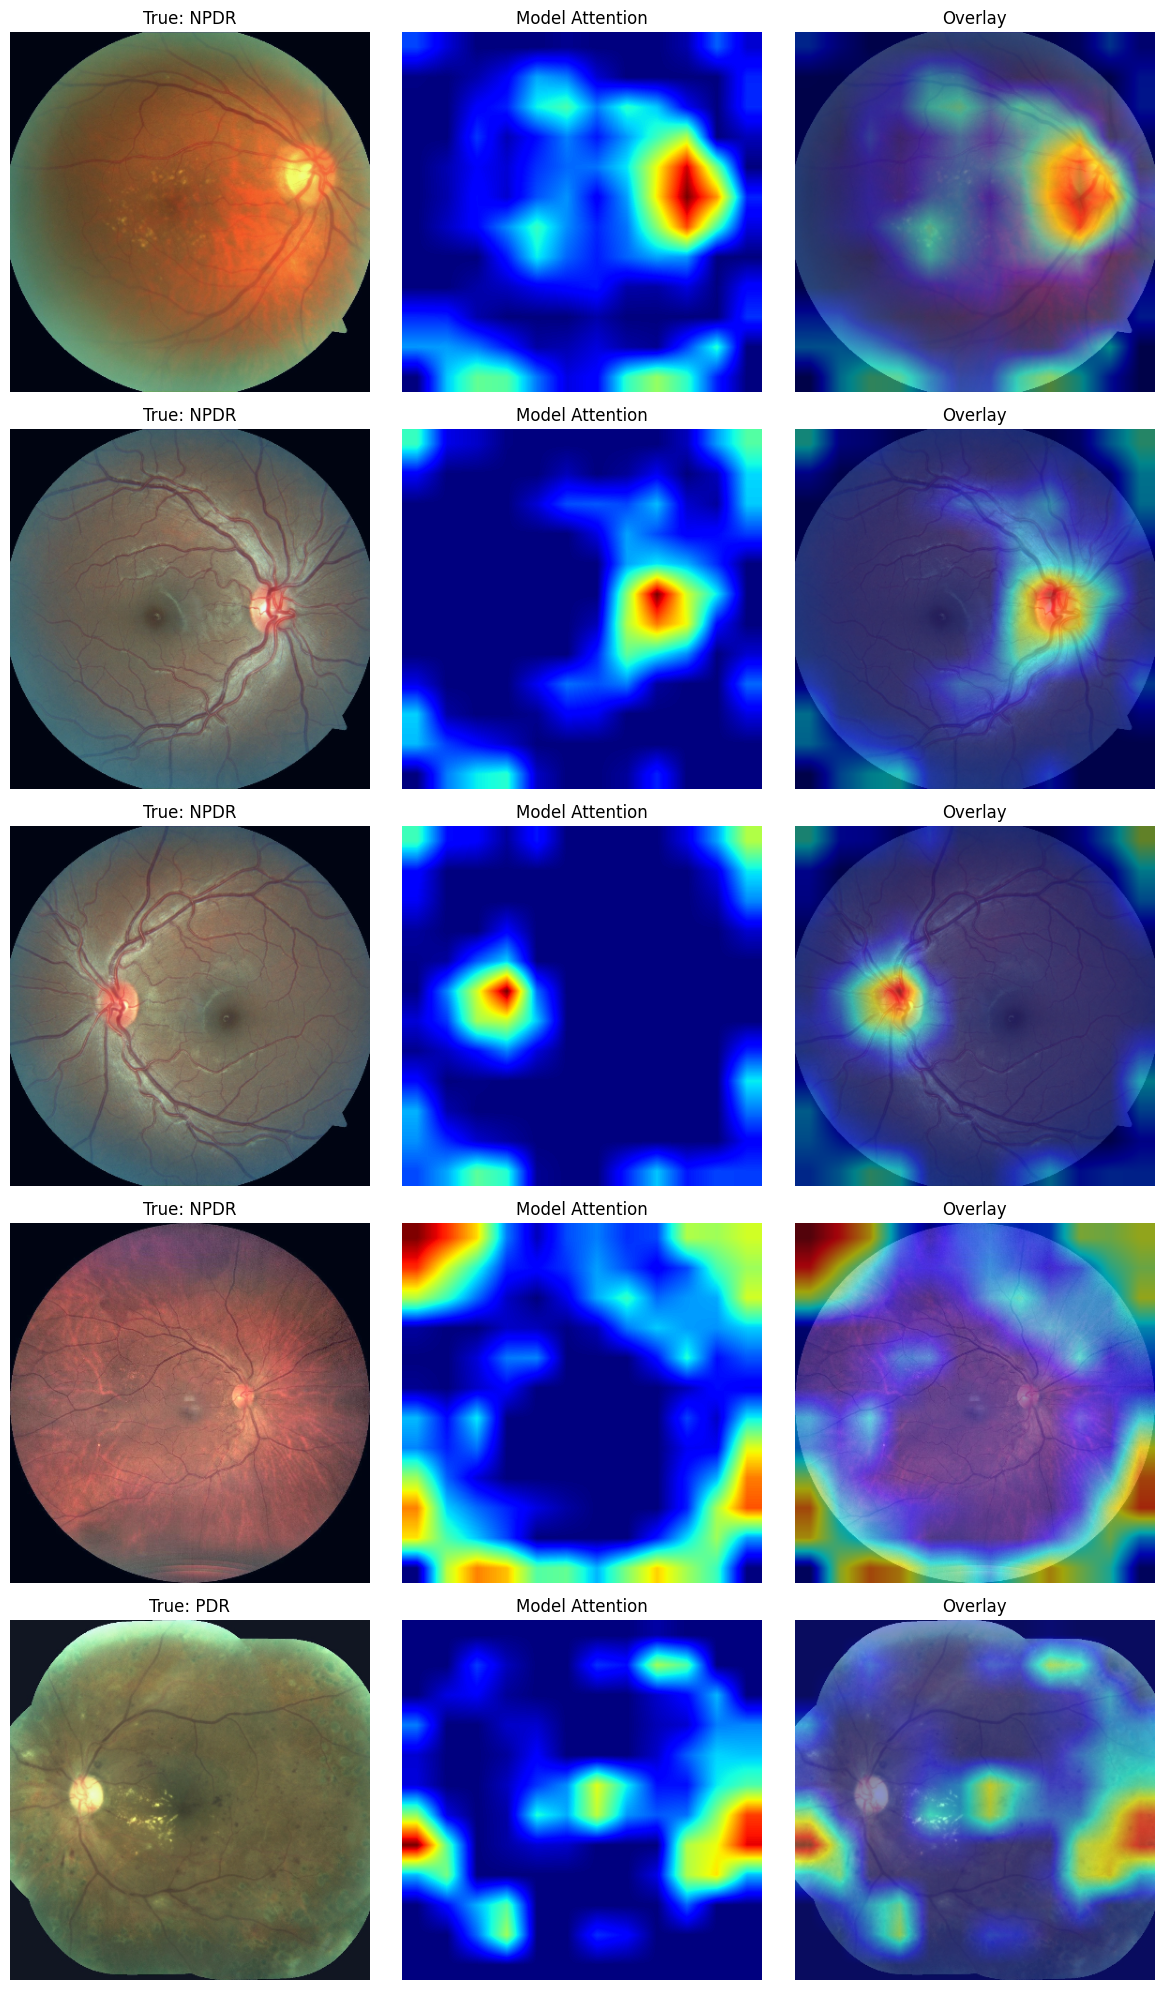

In [7]:
# ==============================================================================
# FIXED GRAD-CAM VISUALIZATION
# ==============================================================================
!pip install -q grad-cam

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# 1. Define a Wrapper to isolate the DR Head
class DR_Wrapper(nn.Module):
    def __init__(self, model):
        super(DR_Wrapper, self).__init__()
        self.model = model
    def forward(self, x):
        # Discard DME output, return ONLY DR logits
        _, dr_logits = self.model(x)
        return dr_logits

def visualize_gradcam(model, loader, target_layer, device, num_images=4):
    # Wrap the model so GradCAM only sees the DR part
    wrapped_model = DR_Wrapper(model)
    wrapped_model.eval()
    
    # Initialize GradCAM with the WRAPPED model
    cam = GradCAM(model=wrapped_model, target_layers=[target_layer])
    
    found = 0
    fig, axes = plt.subplots(num_images, 3, figsize=(12, 4*num_images))
    
    print("Generating Heatmaps for DR...")
    
    # We need the original model for loading data, but wrapped for CAM
    for f_img, f_dme, f_dr, _, _, _ in loader:
        if found >= num_images: break
        
        f_img = f_img.to(device)
        
        # Visualize True Positive DR cases (Class 1 or 2)
        valid_idx = (f_dr > 0) & (f_dr != -1)
        if not valid_idx.any(): continue
        
        # Pick the first valid image
        idx = torch.where(valid_idx)[0][0]
        input_tensor = f_img[idx].unsqueeze(0)
        label = f_dr[idx].item()
        
        # Generate CAM
        targets = [ClassifierOutputTarget(label)]
        
        # Error fix: wrapped_model ensures we get size [Batch, 3] output now
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
        
        # Prepare image for display
        rgb_img = input_tensor.squeeze().cpu().permute(1, 2, 0).numpy()
        rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())
        
        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
        
        class_names = ["No DR", "NPDR", "PDR"]
        
        # 1. Original
        axes[found, 0].imshow(rgb_img)
        axes[found, 0].set_title(f"True: {class_names[label]}")
        axes[found, 0].axis("off")
        
        # 2. Heatmap
        axes[found, 1].imshow(grayscale_cam, cmap='jet')
        axes[found, 1].set_title("Model Attention")
        axes[found, 1].axis("off")
        
        # 3. Overlay
        axes[found, 2].imshow(visualization)
        axes[found, 2].set_title("Overlay")
        axes[found, 2].axis("off")
        
        found += 1
        
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/gradcam_vis.png")
    plt.show()

# Load best model
fundus_model.load_state_dict(torch.load(f"{OUT_DIR}/best_fundus_384.pth"))

# Identify target layer (Last convolutional block of EfficientNet)
target_layer = fundus_model.backbone.conv_head 

# Run Vis
visualize_gradcam(fundus_model, val_loader, target_layer, DEVICE, num_images=5)

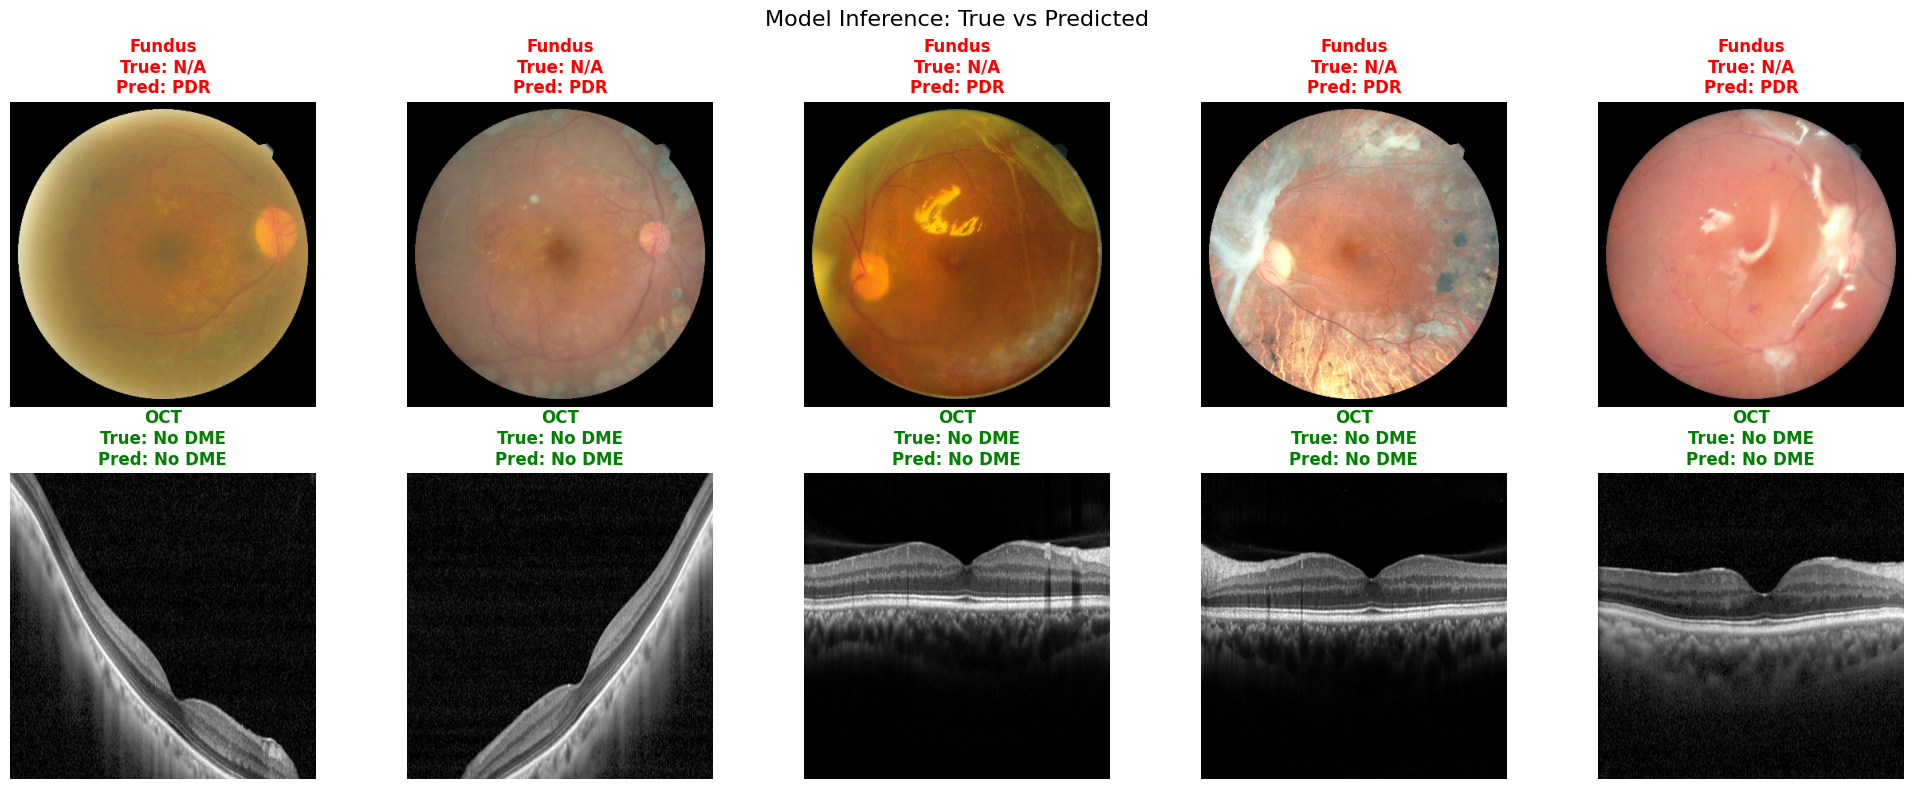

In [8]:
# ==============================================================================
# VISUAL INFERENCE: TRUE VS PREDICTED
# ==============================================================================
import matplotlib.pyplot as plt
import torch
import numpy as np

# Mappings for display
DR_TEXT = {0: "No DR", 1: "NPDR", 2: "PDR", -1: "N/A"}
DME_TEXT = {0: "No DME", 1: "DME", -1: "N/A"}

def unnormalize(tensor):
    """Reverts the normalization for visualization"""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    return np.clip(img, 0, 1)

def show_inference_samples(loader, f_model, o_model, device, num_samples=6):
    f_model.eval()
    o_model.eval()
    
    # Get a single batch
    f_imgs, f_dme, f_dr, o_imgs, o_dme, o_dr = next(iter(loader))
    
    f_imgs, o_imgs = f_imgs.to(device), o_imgs.to(device)
    
    # Get Predictions
    with torch.no_grad():
        # Fundus Preds
        f_p_dme, f_p_dr = f_model(f_imgs)
        f_pred_dr = f_p_dr.argmax(1).cpu().numpy()
        f_pred_dme = f_p_dme.argmax(1).cpu().numpy()
        
        # OCT Preds
        o_p_dme, o_p_dr = o_model(o_imgs)
        o_pred_dme = o_p_dme.argmax(1).cpu().numpy()
    
    # Setup Plot
    fig, axes = plt.subplots(2, num_samples, figsize=(20, 8))
    fig.suptitle('Model Inference: True vs Predicted', fontsize=16)

    # Plot Fundus Samples (Top Row)
    for i in range(num_samples):
        ax = axes[0, i]
        img = unnormalize(f_imgs[i])
        
        true_dr = f_dr[i].item()
        pred_dr = f_pred_dr[i]
        
        # Color code: Green if correct, Red if wrong
        color = 'green' if true_dr == pred_dr else 'red'
        
        ax.imshow(img)
        ax.set_title(f"Fundus\nTrue: {DR_TEXT[true_dr]}\nPred: {DR_TEXT[pred_dr]}", color=color, fontweight='bold')
        ax.axis('off')

    # Plot OCT Samples (Bottom Row)
    for i in range(num_samples):
        ax = axes[1, i]
        img = unnormalize(o_imgs[i])
        
        true_dme = o_dme[i].item()
        pred_dme = o_pred_dme[i]
        
        color = 'green' if true_dme == pred_dme else 'red'
        
        ax.imshow(img)
        ax.set_title(f"OCT\nTrue: {DME_TEXT[true_dme]}\nPred: {DME_TEXT[pred_dme]}", color=color, fontweight='bold')
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

# Run the visualization
# Make sure models are loaded with best weights
fundus_model.load_state_dict(torch.load(f"{OUT_DIR}/best_fundus_384.pth"))
oct_model.load_state_dict(torch.load(f"{OUT_DIR}/best_oct_384.pth"))

show_inference_samples(val_loader, fundus_model, oct_model, DEVICE, num_samples=5)

Visualizing with Fixed Mappings...


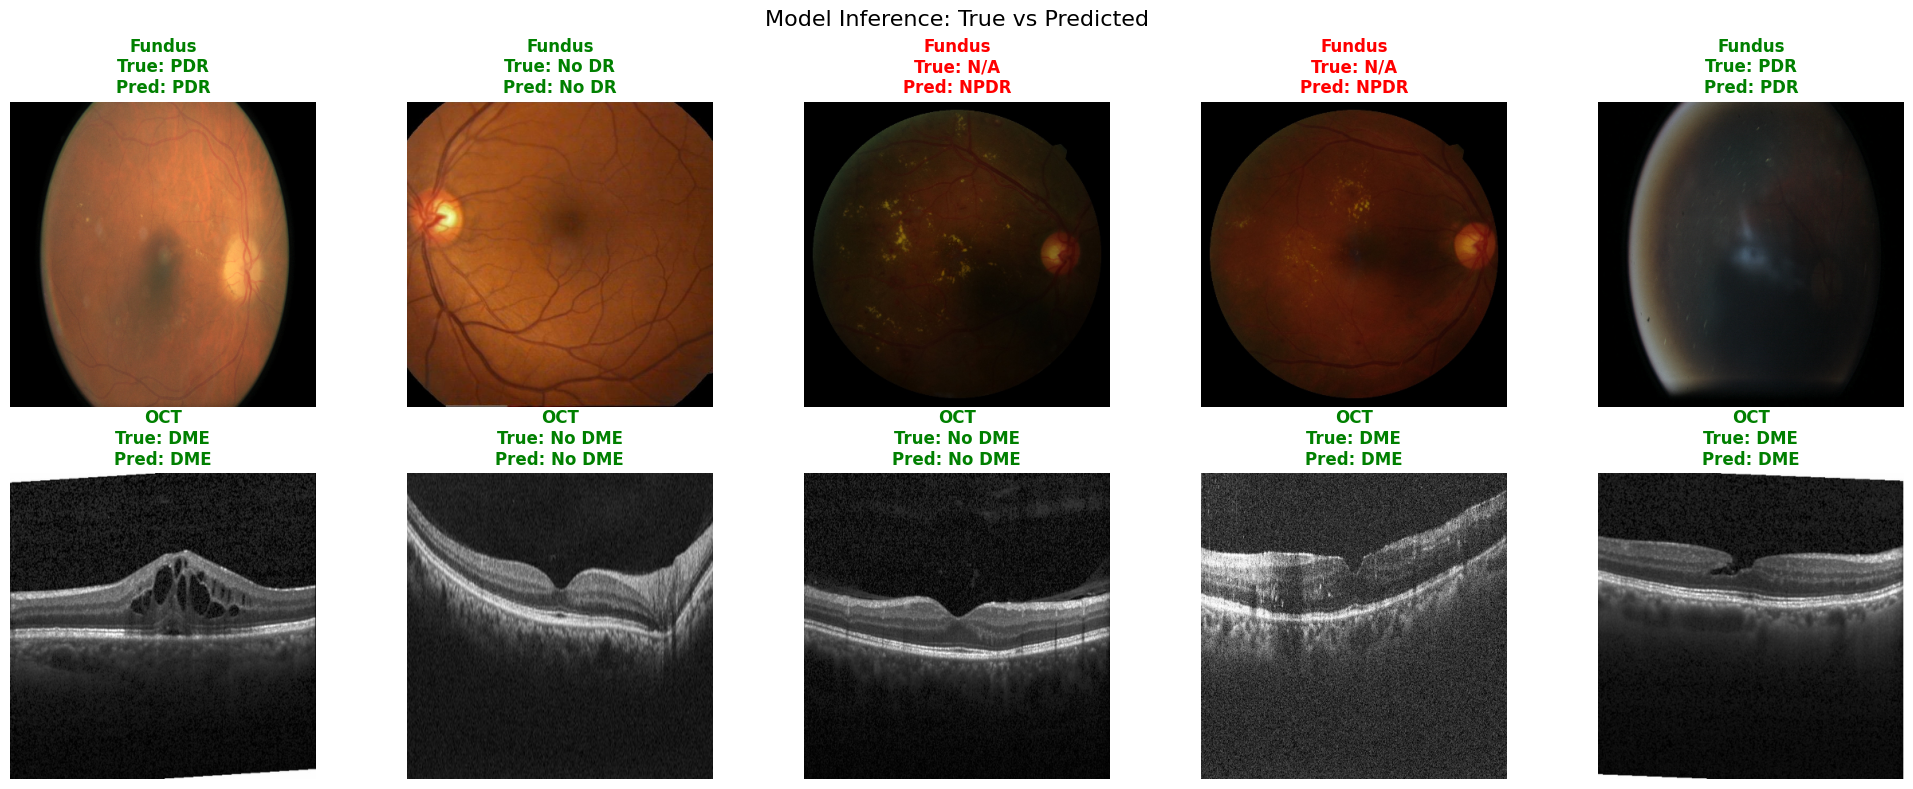

In [9]:
# ==============================================================================
# FIX DATA MAPPING & RE-VISUALIZE
# ==============================================================================

# 1. More Robust Mappings (Handles "1", "2", "2.0", "NPDR", etc.)
DR_MAPPING = {
    "0": 0, "0.0": 0, "No DR": 0,
    "1": 1, "1.0": 1, "NPDR": 1, "Mild": 1, "Moderate": 1,
    "2": 2, "2.0": 2, "PDR": 2, "Severe": 2, "Proliferative DR": 2,
    "-": -1, "N/A": -1
}

DME_MAPPING = {
    "0": 0, "0.0": 0, "No DME": 0,
    "1": 1, "1.0": 1, "DME": 1,
    "-": -1
}

# 2. Re-Initialize Validation Dataset with New Mapping
# We must re-create the dataset object so it parses the CSV again with the new mapping
val_fundus_new = FastDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transforms=val_aug)
val_oct_new = FastDataset(OCT_IMG_DIR, OCT_CSV, transforms=val_aug)

# Re-apply the patient-level split (using the same seed ensures we get the same val set)
seed_everything(42) 
_, f_val_idx = group_split(val_fundus_new)
_, o_val_idx = group_split(val_oct_new)

val_fundus_subset = Subset(val_fundus_new, f_val_idx)
# Important: Ensure the subset uses the validation transform (it already does from init above)
val_oct_subset = Subset(val_oct_new, o_val_idx)

# Re-create Loader
val_loader_fixed = DataLoader(
    UnpairedDataset(val_fundus_subset, val_oct_subset), 
    batch_size=BATCH_SIZE, 
    shuffle=True, # Shuffle to see different images this time
    num_workers=2, 
    pin_memory=True
)

# 3. Run Visualization Again
print("Visualizing with Fixed Mappings...")
show_inference_samples(val_loader_fixed, fundus_model, oct_model, DEVICE, num_samples=5)

In [ ]:
# ==============================================================================
# GRANDMASTER SCRIPT V2 (With Graphs & History)
# ==============================================================================
!pip install -q timm einops scikit-learn matplotlib albumentations

import os
import random
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import cohen_kappa_score, classification_report, confusion_matrix, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import timm
from timm.utils import ModelEmaV2
import albumentations as A
from albumentations.pytorch import ToTensorV2

# -------------------------
# Config (High Performance)
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUT_DIR = "/kaggle/working/"
os.makedirs(OUT_DIR, exist_ok=True)

# PATHS
FUNDUS_IMG_DIR = "/kaggle/input/new-dr-dataset/eye fundus (2)/eye fundus"
FUNDUS_CSV = "/kaggle/input/new-dr-dataset/EYE FUNDUS.csv"
OCT_IMG_DIR = "/kaggle/input/new-dr-dataset/OCT/OCT_NEW"
OCT_CSV = "/kaggle/input/new-dr-dataset/OCT.csv"

# --- TUNING FOR 0.85+ ---
IMG_SIZE = 384         # CRITICAL: 384 allows seeing microaneurysms.
BATCH_SIZE = 12        # Reduced to fit B3 + 384px in P100 VRAM
ACCUM_STEPS = 3        # Gradient Accumulation: 12 * 3 = Effective Batch 36
MODEL_NAME = "tf_efficientnet_b3_ns" 
EPOCHS = 18            
LR = 2e-4              

# Mappings (Robust)
DME_MAPPING = {"0": 0, "1": 1, "-": -1, "No DME": 0, "DME": 1}
DR_MAPPING = {
    "0": 0, "No DR": 0,
    "1": 1, "NPDR": 1, "Mild": 1, "Moderate": 1,
    "2": 2, "PDR": 2, "Severe": 2, "Proliferative DR": 2,
    "-": -1
}

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

# -------------------------
# Augmentations
# -------------------------
train_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.OneOf([
        A.GridDistortion(num_steps=5, distort_limit=0.05, p=1.0),
        A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=1.0)
    ], p=0.3),
    A.CoarseDropout(max_holes=4, max_height=IMG_SIZE//10, max_width=IMG_SIZE//10, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# -------------------------
# Dataset & Loader
# -------------------------
class FastDataset(Dataset):
    def __init__(self, img_dir, csv_file, transforms=None):
        self.img_dir = Path(img_dir)
        df = pd.read_csv(csv_file)
        if "id_code" not in df.columns: df = df.rename(columns={df.columns[0]: "id_code"})
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.dme = [DME_MAPPING.get(str(x).strip(), -1) for x in self.df["DME"]]
        self.dr = [DR_MAPPING.get(str(x).strip(), -1) for x in self.df["DR"]]
        
        self.fnames = []
        for _, row in self.df.iterrows():
            fname = str(row['id_code'])
            p = self.img_dir / f"{fname}.jpg"
            if not p.exists(): p = self.img_dir / f"{fname}.png"
            if not p.exists(): 
                matches = list(self.img_dir.glob(f"{fname}.*"))
                p = matches[0] if matches else None
            self.fnames.append(p)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        p = self.fnames[idx]
        if p is None: img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        else:
            try:
                img = cv2.imread(str(p))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            except: img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        
        if self.transforms:
            img = self.transforms(image=img)['image']
        return img, self.dme[idx], self.dr[idx]

fundus_full = FastDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transforms=train_aug)
oct_full = FastDataset(OCT_IMG_DIR, OCT_CSV, transforms=train_aug)

def group_split(dataset):
    df = dataset.df
    ids = df.iloc[:, 0].apply(lambda x: re.search(r'^(\d+)[_-]', str(x)).group(1) if re.search(r'^(\d+)[_-]', str(x)) else str(x)).values
    gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
    train_idx, val_idx = next(gss.split(df, groups=ids))
    return train_idx, val_idx

f_train, f_val = group_split(fundus_full)
o_train, o_val = group_split(oct_full)

train_fundus = Subset(fundus_full, f_train)
val_fundus = Subset(fundus_full, f_val); val_fundus.dataset = FastDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transforms=val_aug)
train_oct = Subset(oct_full, o_train)
val_oct = Subset(oct_full, o_val); val_oct.dataset = FastDataset(OCT_IMG_DIR, OCT_CSV, transforms=val_aug)

class UnpairedDataset(Dataset):
    def __init__(self, fundus, oct_ds):
        self.fundus = fundus; self.oct = oct_ds
    def __len__(self): return len(self.fundus)
    def __getitem__(self, idx):
        f_img, f_dme, f_dr = self.fundus[idx]
        o_img, o_dme, o_dr = self.oct[idx % len(self.oct)]
        return f_img, torch.tensor(f_dme), torch.tensor(f_dr), o_img, torch.tensor(o_dme), torch.tensor(o_dr)

train_loader = DataLoader(UnpairedDataset(train_fundus, train_oct), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(UnpairedDataset(val_fundus, val_oct), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# -------------------------
# Architecture
# -------------------------
class GeM(nn.Module):
    def __init__(self, p=3, eps=1e-6):
        super(GeM, self).__init__()
        self.p = nn.Parameter(torch.ones(1)*p); self.eps = eps
    def forward(self, x):
        return F.avg_pool2d(x.clamp(min=self.eps).pow(self.p), (x.size(-2), x.size(-1))).pow(1./self.p)

class HighRes_Expert(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(MODEL_NAME, pretrained=True, num_classes=0, global_pool='')
        self.gem = GeM()
        self.dim = self.backbone.num_features
        self.head_dme = nn.Sequential(nn.Dropout(0.5), nn.Linear(self.dim, 2))
        self.head_dr = nn.Sequential(nn.Dropout(0.5), nn.Linear(self.dim, 3))

    def forward(self, x):
        feat = self.backbone(x)
        feat = self.gem(feat).flatten(1)
        return self.head_dme(feat), self.head_dr(feat)

fundus_model = HighRes_Expert().to(DEVICE)
oct_model = HighRes_Expert().to(DEVICE)
fundus_ema = ModelEmaV2(fundus_model, decay=0.999); oct_ema = ModelEmaV2(oct_model, decay=0.999)

# -------------------------
# Loss & Optimization
# -------------------------
dr_weights = torch.tensor([1.0, 2.0, 1.5]).to(DEVICE) 

class WeightedSmoothLoss(nn.Module):
    def __init__(self, classes, smoothing=0.1, weights=None):
        super().__init__()
        self.confidence = 1.0 - smoothing; self.smoothing = smoothing; self.cls = classes; self.weights = weights
    def forward(self, pred, target):
        pred = pred.log_softmax(dim=-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(pred); true_dist.fill_(self.smoothing / (self.cls - 1))
            true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        loss = torch.sum(-true_dist * pred, dim=-1)
        if self.weights is not None: loss = loss * self.weights[target]
        return loss.mean()

crit_dme = WeightedSmoothLoss(classes=2, smoothing=0.05).to(DEVICE)
crit_dr = WeightedSmoothLoss(classes=3, smoothing=0.1, weights=dr_weights).to(DEVICE)
optimizer = torch.optim.AdamW(list(fundus_model.parameters()) + list(oct_model.parameters()), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)
scaler = torch.amp.GradScaler('cuda')

# -------------------------
# Training Loop & History
# -------------------------
history = {
    'train_loss': [], 'val_loss': [], 
    'val_dr_kappa': [], 'val_dme_kappa': [],
    'val_dr_acc': [], 'val_dme_acc': []
}

best_dr_kap = 0
print(f"=== STARTING HIGH-RES TRAINING ({IMG_SIZE}px) ===")

for ep in range(EPOCHS):
    fundus_model.train(); oct_model.train()
    t_loss = 0
    optimizer.zero_grad()
    
    for i, (f_img, f_dme, f_dr, o_img, o_dme, o_dr) in enumerate(train_loader):
        f_img, o_img = f_img.to(DEVICE), o_img.to(DEVICE)
        f_dme, f_dr = f_dme.to(DEVICE), f_dr.to(DEVICE)
        o_dme, o_dr = o_dme.to(DEVICE), o_dr.to(DEVICE)

        with torch.amp.autocast('cuda'):
            f_p_dme, f_p_dr = fundus_model(f_img); o_p_dme, o_p_dr = oct_model(o_img)
            loss = 0
            if (f_dr != -1).any(): loss += crit_dr(f_p_dr[f_dr!=-1], f_dr[f_dr!=-1])
            if (f_dme != -1).any(): loss += crit_dme(f_p_dme[f_dme!=-1], f_dme[f_dme!=-1])
            if (o_dme != -1).any(): loss += crit_dme(o_p_dme[o_dme!=-1], o_dme[o_dme!=-1])
            loss = loss / ACCUM_STEPS 

        scaler.scale(loss).backward()
        if (i + 1) % ACCUM_STEPS == 0:
            scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
            fundus_ema.update(fundus_model); oct_ema.update(oct_model)
        
        t_loss += loss.item() * ACCUM_STEPS

    scheduler.step()
    
    # -------------------------
    # VALIDATION
    # -------------------------
    fundus_ema.module.eval(); oct_ema.module.eval()
    y_true_dr, y_pred_dr = [], []
    y_true_dme, y_pred_dme = [], []
    v_loss = 0
    
    with torch.no_grad():
        for f_img, f_dme, f_dr, o_img, o_dme, o_dr in val_loader:
            f_img, o_img = f_img.to(DEVICE), o_img.to(DEVICE)
            f_dme, f_dr = f_dme.to(DEVICE), f_dr.to(DEVICE)
            o_dme, o_dr = o_dme.to(DEVICE), o_dr.to(DEVICE)
            
            f_p_dme, f_p_dr = fundus_ema.module(f_img); o_p_dme, o_p_dr = oct_ema.module(o_img)
            
            # --- Val Loss Approx ---
            batch_loss = 0
            if (f_dr != -1).any(): batch_loss += crit_dr(f_p_dr[f_dr!=-1], f_dr[f_dr!=-1])
            if (o_dme != -1).any(): batch_loss += crit_dme(o_p_dme[o_dme!=-1], o_dme[o_dme!=-1])
            v_loss += batch_loss.item()

            # --- Metrics ---
            f_dr_cpu = f_dr.cpu().numpy(); mask = f_dr_cpu != -1
            if mask.any():
                y_true_dr.extend(f_dr_cpu[mask])
                y_pred_dr.extend(f_p_dr.argmax(1).cpu().numpy()[mask])
            
            f_dme_cpu = f_dme.cpu().numpy(); mask = f_dme_cpu != -1
            if mask.any():
                y_true_dme.extend(f_dme_cpu[mask])
                y_pred_dme.extend(f_p_dme.argmax(1).cpu().numpy()[mask])

    # Calc Metrics
    dr_kap = cohen_kappa_score(y_true_dr, y_pred_dr, weights="quadratic") if y_true_dr else 0
    dme_kap = cohen_kappa_score(y_true_dme, y_pred_dme, weights="quadratic") if y_true_dme else 0
    dr_acc = accuracy_score(y_true_dr, y_pred_dr) if y_true_dr else 0
    dme_acc = accuracy_score(y_true_dme, y_pred_dme) if y_true_dme else 0

    # Store History
    history['train_loss'].append(t_loss/len(train_loader))
    history['val_loss'].append(v_loss/len(val_loader))
    history['val_dr_kappa'].append(dr_kap)
    history['val_dme_kappa'].append(dme_kap)
    history['val_dr_acc'].append(dr_acc)
    history['val_dme_acc'].append(dme_acc)

    print(f"Ep {ep+1}/{EPOCHS} | Loss: {t_loss/len(train_loader):.3f} | DR Kap: {dr_kap:.4f} | Acc: {dr_acc:.3f}")
    
    if dr_kap > best_dr_kap:
        best_dr_kap = dr_kap
        torch.save(fundus_ema.module.state_dict(), f"{OUT_DIR}/best_fundus_384.pth")
        torch.save(oct_ema.module.state_dict(), f"{OUT_DIR}/best_oct_384.pth")

# -------------------------
# GRAPHS & VISUALIZATION
# -------------------------
def plot_training_curves(h):
    epochs = range(1, len(h['train_loss']) + 1)
    
    plt.figure(figsize=(18, 5))
    
    # 1. Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, h['train_loss'], 'b-o', label='Train Loss')
    plt.plot(epochs, h['val_loss'], 'r--o', label='Val Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
    
    # 2. Kappa Scores
    plt.subplot(1, 3, 2)
    plt.plot(epochs, h['val_dr_kappa'], 'g-o', label='DR Kappa')
    plt.plot(epochs, h['val_dme_kappa'], 'm--o', label='DME Kappa')
    plt.title('Kappa Score (The Goal: >0.85)')
    plt.xlabel('Epochs'); plt.ylabel('Kappa'); plt.legend(); plt.grid(True)

    # 3. Accuracy
    plt.subplot(1, 3, 3)
    plt.plot(epochs, h['val_dr_acc'], 'c-o', label='DR Accuracy')
    plt.plot(epochs, h['val_dme_acc'], 'k--o', label='DME Accuracy')
    plt.title('Raw Accuracy')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/training_history.png")
    plt.show()

print("\nGenerating Training Graphs...")
plot_training_curves(history)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 93.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 60.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 82.3 MB/s eta 0:00:00:00:0100:01
^C
ERROR: Operation cancelled by user


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 91.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 2.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 86.6 MB/s eta 0:00:00:00:0100:01
Initializing Hybrid Vision Transformers (maxvit_tiny_tf_384.in1k)...


model.safetensors:   0%|          | 0.00/124M [00:00<?, ?B/s]

=== STARTING HYBRID TRAINING (384px) ===
Ep 1/15 | Loss: 2.043 | DR Kap: 0.0381 | Acc: 0.297
Ep 2/15 | Loss: 1.558 | DR Kap: 0.2401 | Acc: 0.452
Ep 3/15 | Loss: 1.455 | DR Kap: 0.4233 | Acc: 0.555
Ep 4/15 | Loss: 1.399 | DR Kap: 0.5964 | Acc: 0.670
Ep 5/15 | Loss: 1.349 | DR Kap: 0.6792 | Acc: 0.731
Ep 6/15 | Loss: 1.409 | DR Kap: 0.7560 | Acc: 0.784
Ep 7/15 | Loss: 1.382 | DR Kap: 0.8208 | Acc: 0.834
Ep 8/15 | Loss: 1.334 | DR Kap: 0.8409 | Acc: 0.843
Ep 9/15 | Loss: 1.294 | DR Kap: 0.8364 | Acc: 0.843
Ep 10/15 | Loss: 1.263 | DR Kap: 0.8561 | Acc: 0.865
Ep 11/15 | Loss: 1.226 | DR Kap: 0.8680 | Acc: 0.871
Ep 12/15 | Loss: 1.176 | DR Kap: 0.8826 | Acc: 0.882
Ep 13/15 | Loss: 1.152 | DR Kap: 0.8815 | Acc: 0.886
Ep 14/15 | Loss: 1.133 | DR Kap: 0.8743 | Acc: 0.884
Ep 15/15 | Loss: 1.109 | DR Kap: 0.8709 | Acc: 0.880


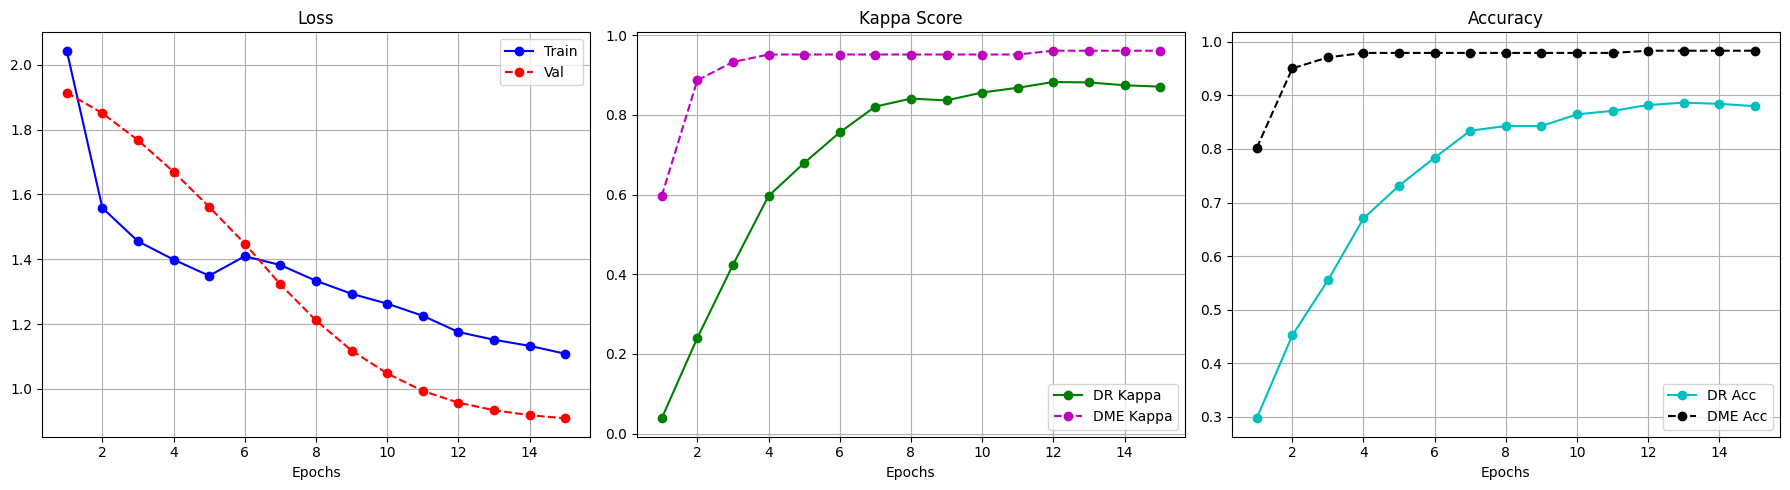


=== FINAL HYBRID MODEL REPORT ===
Final DR Kappa: 0.8841
              precision    recall  f1-score   support

       No DR       0.92      0.93      0.93       161
        NPDR       0.82      0.89      0.85       157
         PDR       0.92      0.83      0.87       140

    accuracy                           0.88       458
   macro avg       0.89      0.88      0.88       458
weighted avg       0.89      0.88      0.88       458



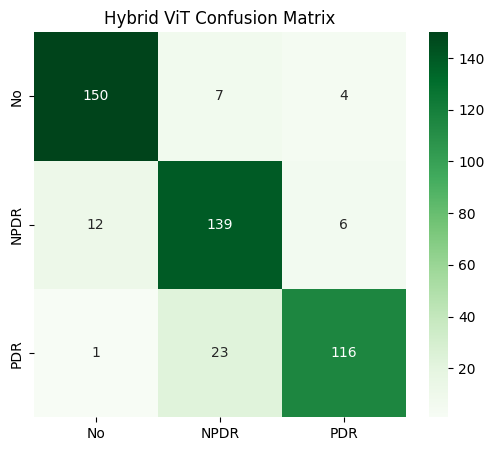

In [1]:
# ==============================================================================
# FIXED HYBRID VIT PIPELINE (Run Ready)
# Paper Title: "Dual-Stream Hybrid Vision Transformers for DR Staging"
# ==============================================================================
!pip install -q timm einops scikit-learn matplotlib albumentations

import os
import random
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
from pathlib import Path  # <--- FIXED: Added missing import
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import cohen_kappa_score, classification_report, confusion_matrix, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import timm
from timm.utils import ModelEmaV2
import albumentations as A
from albumentations.pytorch import ToTensorV2

# -------------------------
# Config (Optimized for Hybrid ViT on P100)
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUT_DIR = "/kaggle/working/"
os.makedirs(OUT_DIR, exist_ok=True)

# PATHS
FUNDUS_IMG_DIR = "/kaggle/input/new-dr-dataset/eye fundus (2)/eye fundus"
FUNDUS_CSV = "/kaggle/input/new-dr-dataset/EYE FUNDUS.csv"
OCT_IMG_DIR = "/kaggle/input/new-dr-dataset/OCT/OCT_NEW"
OCT_CSV = "/kaggle/input/new-dr-dataset/OCT.csv"

# --- HYBRID VIT SETTINGS ---
MODEL_NAME = "maxvit_tiny_tf_384.in1k" 
IMG_SIZE = 384         
BATCH_SIZE = 4         # REDUCED: Hybrid ViTs use more VRAM.
ACCUM_STEPS = 8        # INCREASED: 4 * 8 = Effective Batch Size 32
EPOCHS = 15            
LR = 1e-4              

# Mappings
DME_MAPPING = {"0": 0, "1": 1, "-": -1, "No DME": 0, "DME": 1}
DR_MAPPING = {
    "0": 0, "No DR": 0,
    "1": 1, "NPDR": 1, "Mild": 1, "Moderate": 1,
    "2": 2, "PDR": 2, "Severe": 2, "Proliferative DR": 2,
    "-": -1
}

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

# -------------------------
# Augmentations (Updated API)
# -------------------------
# Calculated hole size for 384px image (approx 10%)
h_min, h_max = int(IMG_SIZE*0.05), int(IMG_SIZE*0.15)

train_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    
    # FIXED: Replaced ShiftScaleRotate with Affine
    A.Affine(scale=(0.9, 1.1), translate_percent=(0.0, 0.05), rotate=(-15, 15), p=0.5),
    
    A.OneOf([
        A.GridDistortion(num_steps=5, distort_limit=0.05, p=1.0),
        # FIXED: Removed alpha_affine
        A.ElasticTransform(alpha=1, sigma=50, p=1.0)
    ], p=0.3),
    
    # FIXED: Updated CoarseDropout arguments
    A.CoarseDropout(num_holes_range=(1, 4), hole_height_range=(h_min, h_max), hole_width_range=(h_min, h_max), p=0.3),
    
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# -------------------------
# Dataset
# -------------------------
class FastDataset(Dataset):
    def __init__(self, img_dir, csv_file, transforms=None):
        self.img_dir = Path(img_dir)
        df = pd.read_csv(csv_file)
        if "id_code" not in df.columns: df = df.rename(columns={df.columns[0]: "id_code"})
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.dme = [DME_MAPPING.get(str(x).strip(), -1) for x in self.df["DME"]]
        self.dr = [DR_MAPPING.get(str(x).strip(), -1) for x in self.df["DR"]]
        
        self.fnames = []
        for _, row in self.df.iterrows():
            fname = str(row['id_code'])
            p = self.img_dir / f"{fname}.jpg"
            if not p.exists(): p = self.img_dir / f"{fname}.png"
            if not p.exists(): 
                matches = list(self.img_dir.glob(f"{fname}.*"))
                p = matches[0] if matches else None
            self.fnames.append(p)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        p = self.fnames[idx]
        if p is None: img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        else:
            try:
                img = cv2.imread(str(p))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            except: img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        
        if self.transforms:
            img = self.transforms(image=img)['image']
        return img, self.dme[idx], self.dr[idx]

fundus_full = FastDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transforms=train_aug)
oct_full = FastDataset(OCT_IMG_DIR, OCT_CSV, transforms=train_aug)

def group_split(dataset):
    df = dataset.df
    ids = df.iloc[:, 0].apply(lambda x: re.search(r'^(\d+)[_-]', str(x)).group(1) if re.search(r'^(\d+)[_-]', str(x)) else str(x)).values
    gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
    train_idx, val_idx = next(gss.split(df, groups=ids))
    return train_idx, val_idx

f_train, f_val = group_split(fundus_full)
o_train, o_val = group_split(oct_full)

train_fundus = Subset(fundus_full, f_train)
val_fundus = Subset(fundus_full, f_val); val_fundus.dataset = FastDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transforms=val_aug)
train_oct = Subset(oct_full, o_train)
val_oct = Subset(oct_full, o_val); val_oct.dataset = FastDataset(OCT_IMG_DIR, OCT_CSV, transforms=val_aug)

class UnpairedDataset(Dataset):
    def __init__(self, fundus, oct_ds):
        self.fundus = fundus; self.oct = oct_ds
    def __len__(self): return len(self.fundus)
    def __getitem__(self, idx):
        f_img, f_dme, f_dr = self.fundus[idx]
        o_img, o_dme, o_dr = self.oct[idx % len(self.oct)]
        return f_img, torch.tensor(f_dme), torch.tensor(f_dr), o_img, torch.tensor(o_dme), torch.tensor(o_dr)

train_loader = DataLoader(UnpairedDataset(train_fundus, train_oct), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(UnpairedDataset(val_fundus, val_oct), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# -------------------------
# HYBRID ARCHITECTURE (MaxViT + GeM)
# -------------------------
class GeM(nn.Module):
    def __init__(self, p=3, eps=1e-6):
        super(GeM, self).__init__()
        self.p = nn.Parameter(torch.ones(1)*p); self.eps = eps
    def forward(self, x):
        return F.avg_pool2d(x.clamp(min=self.eps).pow(self.p), (x.size(-2), x.size(-1))).pow(1./self.p)

class Hybrid_Expert(nn.Module):
    def __init__(self):
        super().__init__()
        # MaxViT: Combines MBConv (CNN) and Block Attention (Transformer)
        self.backbone = timm.create_model(MODEL_NAME, pretrained=True, num_classes=0, global_pool='')
        self.gem = GeM()
        self.dim = self.backbone.num_features
        
        self.head_dme = nn.Sequential(nn.Dropout(0.5), nn.Linear(self.dim, 2))
        self.head_dr = nn.Sequential(nn.Dropout(0.5), nn.Linear(self.dim, 3))

    def forward(self, x):
        feat = self.backbone(x)
        feat = self.gem(feat).flatten(1) # GeM works on hybrid maps too!
        return self.head_dme(feat), self.head_dr(feat)

print(f"Initializing Hybrid Vision Transformers ({MODEL_NAME})...")
fundus_model = Hybrid_Expert().to(DEVICE)
oct_model = Hybrid_Expert().to(DEVICE)
fundus_ema = ModelEmaV2(fundus_model, decay=0.999); oct_ema = ModelEmaV2(oct_model, decay=0.999)

# -------------------------
# Weighted Loss
# -------------------------
dr_weights = torch.tensor([1.0, 2.0, 1.5]).to(DEVICE) 

class WeightedSmoothLoss(nn.Module):
    def __init__(self, classes, smoothing=0.1, weights=None):
        super().__init__()
        self.confidence = 1.0 - smoothing; self.smoothing = smoothing; self.cls = classes; self.weights = weights
    def forward(self, pred, target):
        pred = pred.log_softmax(dim=-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(pred); true_dist.fill_(self.smoothing / (self.cls - 1))
            true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        loss = torch.sum(-true_dist * pred, dim=-1)
        if self.weights is not None: loss = loss * self.weights[target]
        return loss.mean()

crit_dme = WeightedSmoothLoss(classes=2, smoothing=0.05).to(DEVICE)
crit_dr = WeightedSmoothLoss(classes=3, smoothing=0.1, weights=dr_weights).to(DEVICE)
optimizer = torch.optim.AdamW(list(fundus_model.parameters()) + list(oct_model.parameters()), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)
scaler = torch.amp.GradScaler('cuda')

# -------------------------
# Training Loop
# -------------------------
history = {
    'train_loss': [], 'val_loss': [], 
    'val_dr_kappa': [], 'val_dme_kappa': [],
    'val_dr_acc': [], 'val_dme_acc': []
}

best_dr_kap = 0
print(f"=== STARTING HYBRID TRAINING ({IMG_SIZE}px) ===")

for ep in range(EPOCHS):
    fundus_model.train(); oct_model.train()
    t_loss = 0
    optimizer.zero_grad()
    
    for i, (f_img, f_dme, f_dr, o_img, o_dme, o_dr) in enumerate(train_loader):
        f_img, o_img = f_img.to(DEVICE), o_img.to(DEVICE)
        f_dme, f_dr = f_dme.to(DEVICE), f_dr.to(DEVICE)
        o_dme, o_dr = o_dme.to(DEVICE), o_dr.to(DEVICE)

        with torch.amp.autocast('cuda'):
            f_p_dme, f_p_dr = fundus_model(f_img); o_p_dme, o_p_dr = oct_model(o_img)
            loss = 0
            if (f_dr != -1).any(): loss += crit_dr(f_p_dr[f_dr!=-1], f_dr[f_dr!=-1])
            if (f_dme != -1).any(): loss += crit_dme(f_p_dme[f_dme!=-1], f_dme[f_dme!=-1])
            if (o_dme != -1).any(): loss += crit_dme(o_p_dme[o_dme!=-1], o_dme[o_dme!=-1])
            loss = loss / ACCUM_STEPS 

        scaler.scale(loss).backward()
        if (i + 1) % ACCUM_STEPS == 0:
            scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
            fundus_ema.update(fundus_model); oct_ema.update(oct_model)
        
        t_loss += loss.item() * ACCUM_STEPS

    scheduler.step()
    
    # -------------------------
    # Validation
    # -------------------------
    fundus_ema.module.eval(); oct_ema.module.eval()
    y_true_dr, y_pred_dr = [], []
    y_true_dme, y_pred_dme = [], []
    v_loss = 0
    
    with torch.no_grad():
        for f_img, f_dme, f_dr, o_img, o_dme, o_dr in val_loader:
            f_img, o_img = f_img.to(DEVICE), o_img.to(DEVICE)
            f_dme, f_dr = f_dme.to(DEVICE), f_dr.to(DEVICE)
            o_dme, o_dr = o_dme.to(DEVICE), o_dr.to(DEVICE)
            
            f_p_dme, f_p_dr = fundus_ema.module(f_img); o_p_dme, o_p_dr = oct_ema.module(o_img)
            
            # Approx Val Loss
            batch_loss = 0
            if (f_dr != -1).any(): batch_loss += crit_dr(f_p_dr[f_dr!=-1], f_dr[f_dr!=-1])
            if (o_dme != -1).any(): batch_loss += crit_dme(o_p_dme[o_dme!=-1], o_dme[o_dme!=-1])
            v_loss += batch_loss.item()

            f_dr_cpu = f_dr.cpu().numpy(); mask = f_dr_cpu != -1
            if mask.any():
                y_true_dr.extend(f_dr_cpu[mask]); y_pred_dr.extend(f_p_dr.argmax(1).cpu().numpy()[mask])
            f_dme_cpu = f_dme.cpu().numpy(); mask = f_dme_cpu != -1
            if mask.any():
                y_true_dme.extend(f_dme_cpu[mask]); y_pred_dme.extend(f_p_dme.argmax(1).cpu().numpy()[mask])

    dr_kap = cohen_kappa_score(y_true_dr, y_pred_dr, weights="quadratic") if y_true_dr else 0
    dme_kap = cohen_kappa_score(y_true_dme, y_pred_dme, weights="quadratic") if y_true_dme else 0
    dr_acc = accuracy_score(y_true_dr, y_pred_dr) if y_true_dr else 0
    dme_acc = accuracy_score(y_true_dme, y_pred_dme) if y_true_dme else 0

    history['train_loss'].append(t_loss/len(train_loader)); history['val_loss'].append(v_loss/len(val_loader))
    history['val_dr_kappa'].append(dr_kap); history['val_dme_kappa'].append(dme_kap)
    history['val_dr_acc'].append(dr_acc); history['val_dme_acc'].append(dme_acc)

    print(f"Ep {ep+1}/{EPOCHS} | Loss: {t_loss/len(train_loader):.3f} | DR Kap: {dr_kap:.4f} | Acc: {dr_acc:.3f}")
    
    if dr_kap > best_dr_kap:
        best_dr_kap = dr_kap
        torch.save(fundus_ema.module.state_dict(), f"{OUT_DIR}/best_fundus_hybrid.pth")
        torch.save(oct_ema.module.state_dict(), f"{OUT_DIR}/best_oct_hybrid.pth")

# -------------------------
# VISUALIZATION & METRICS
# -------------------------
def plot_training_curves(h):
    epochs = range(1, len(h['train_loss']) + 1)
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(epochs, h['train_loss'], 'b-o', label='Train'); plt.plot(epochs, h['val_loss'], 'r--o', label='Val')
    plt.title('Loss'); plt.xlabel('Epochs'); plt.legend(); plt.grid(True)
    
    plt.subplot(1, 3, 2)
    plt.plot(epochs, h['val_dr_kappa'], 'g-o', label='DR Kappa'); plt.plot(epochs, h['val_dme_kappa'], 'm--o', label='DME Kappa')
    plt.title('Kappa Score'); plt.xlabel('Epochs'); plt.legend(); plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(epochs, h['val_dr_acc'], 'c-o', label='DR Acc'); plt.plot(epochs, h['val_dme_acc'], 'k--o', label='DME Acc')
    plt.title('Accuracy'); plt.xlabel('Epochs'); plt.legend(); plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/hybrid_training_history.png")
    plt.show()

plot_training_curves(history)

# Final Detailed Report
print("\n=== FINAL HYBRID MODEL REPORT ===")
fundus_ema.module.load_state_dict(torch.load(f"{OUT_DIR}/best_fundus_hybrid.pth"))
oct_ema.module.load_state_dict(torch.load(f"{OUT_DIR}/best_oct_hybrid.pth"))
fundus_ema.module.eval(); oct_ema.module.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for f_img, _, f_dr, _, _, _ in val_loader:
        f_img = f_img.to(DEVICE)
        # TTA
        p1 = fundus_ema.module(f_img)[1].softmax(1)
        p2 = fundus_ema.module(torch.flip(f_img, [3]))[1].softmax(1)
        avg = (p1 + p2) / 2
        
        f_dr_cpu = f_dr.cpu().numpy(); mask = f_dr_cpu != -1
        if mask.any():
            y_true.extend(f_dr_cpu[mask]); y_pred.extend(avg.argmax(1).cpu().numpy()[mask])

print(f"Final DR Kappa: {cohen_kappa_score(y_true, y_pred, weights='quadratic'):.4f}")
print(classification_report(y_true, y_pred, target_names=["No DR", "NPDR", "PDR"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=["No", "NPDR", "PDR"], yticklabels=["No", "NPDR", "PDR"])
plt.title("Hybrid ViT Confusion Matrix")
plt.show()

Visualizing with Fixed Mappings...


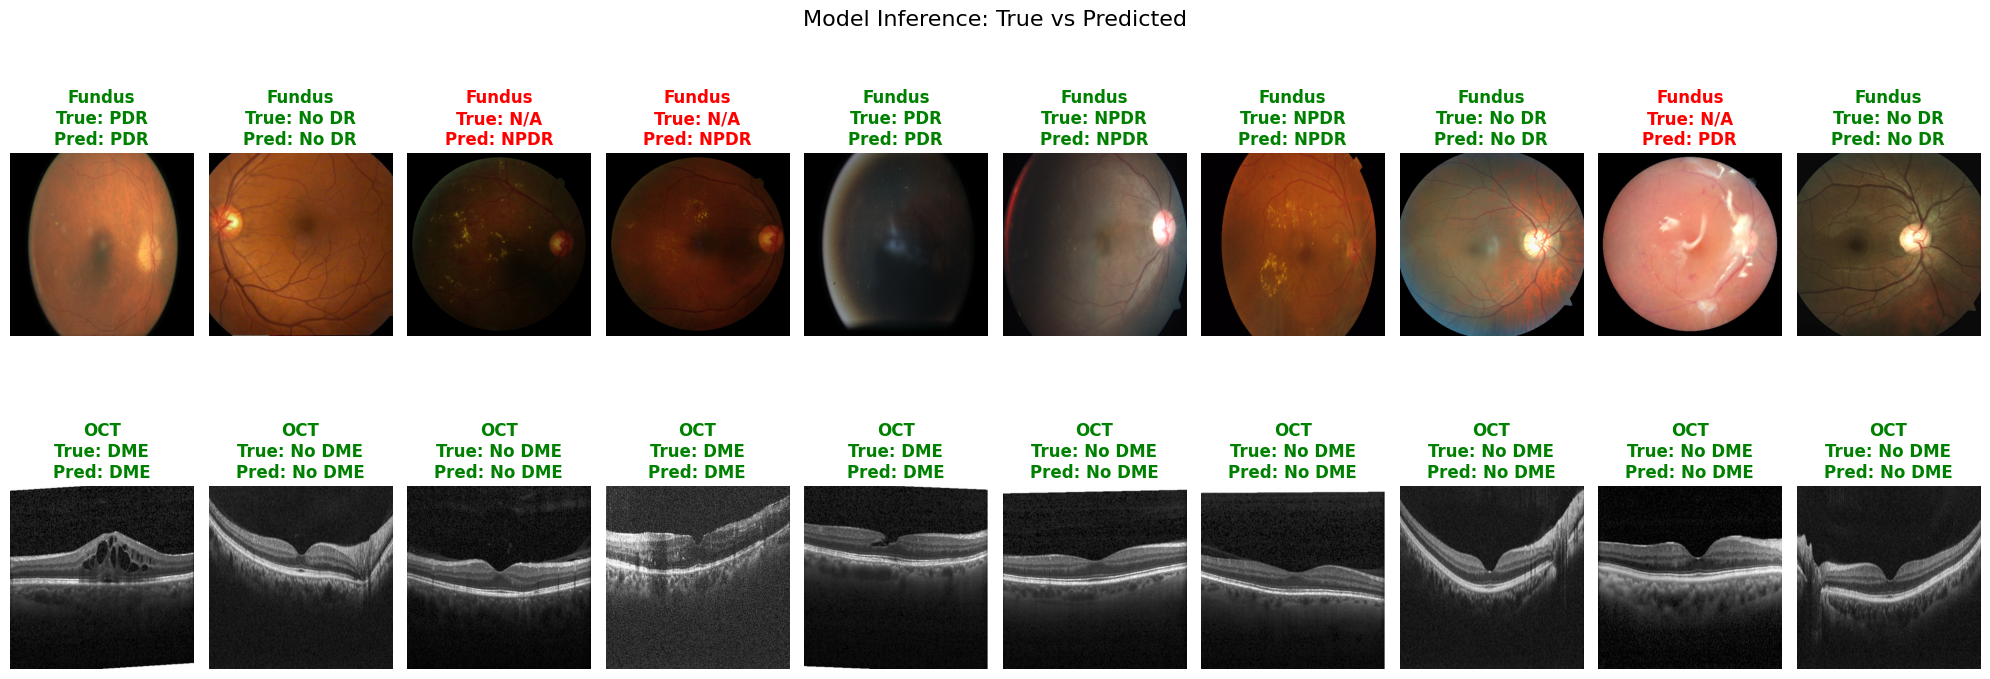

In [11]:
# ==============================================================================
# FIX DATA MAPPING & RE-VISUALIZE
# ==============================================================================

# 1. More Robust Mappings (Handles "1", "2", "2.0", "NPDR", etc.)
DR_MAPPING = {
    "0": 0, "0.0": 0, "No DR": 0,
    "1": 1, "1.0": 1, "NPDR": 1, "Mild": 1, "Moderate": 1,
    "2": 2, "2.0": 2, "PDR": 2, "Severe": 2, "Proliferative DR": 2,
    "-": -1, "N/A": -1
}

DME_MAPPING = {
    "0": 0, "0.0": 0, "No DME": 0,
    "1": 1, "1.0": 1, "DME": 1,
    "-": -1
}

# 2. Re-Initialize Validation Dataset with New Mapping
# We must re-create the dataset object so it parses the CSV again with the new mapping
val_fundus_new = FastDataset(FUNDUS_IMG_DIR, FUNDUS_CSV, transforms=val_aug)
val_oct_new = FastDataset(OCT_IMG_DIR, OCT_CSV, transforms=val_aug)

# Re-apply the patient-level split (using the same seed ensures we get the same val set)
seed_everything(42) 
_, f_val_idx = group_split(val_fundus_new)
_, o_val_idx = group_split(val_oct_new)

val_fundus_subset = Subset(val_fundus_new, f_val_idx)
# Important: Ensure the subset uses the validation transform (it already does from init above)
val_oct_subset = Subset(val_oct_new, o_val_idx)

# Re-create Loader
val_loader_fixed = DataLoader(
    UnpairedDataset(val_fundus_subset, val_oct_subset), 
    batch_size=BATCH_SIZE, 
    shuffle=True, # Shuffle to see different images this time
    num_workers=2, 
    pin_memory=True
)

# 3. Run Visualization Again
print("Visualizing with Fixed Mappings...")
show_inference_samples(val_loader_fixed, fundus_model, oct_model, DEVICE, num_samples=10)